In [105]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import ast
import unicodedata
import numpy as np
import re


json_path = Path(r"Script_generador_tickets_sinteticos_gasolina\data\tickets\tickets_sinteticos.json")

with open(json_path, "r", encoding="utf-8") as f:
    tickets_data = json.load(f)

df_tickets = pd.DataFrame(tickets_data)
df_tickets.to_csv(r"Script_generador_tickets_sinteticos_gasolina\data\tickets\tickets_sinteticos.csv", index=False, encoding="utf-8")



In [106]:
CSV_PATH = "Script_generador_tickets_sinteticos_gasolina/data/tickets/tickets_sinteticos.csv"
df = pd.read_csv(CSV_PATH)

In [107]:
df["fechaEmision"] = pd.to_datetime(df["fechaEmision"], errors="coerce")
df["dt"] = pd.to_datetime(df["fechaEmision"].astype(str) + " " + df["horaEmision"], errors="coerce")
df["mes"] = df["dt"].dt.to_period("M").astype(str)
df["hora"] = df["dt"].dt.hour
dias_map = {"Monday":"Lunes","Tuesday":"Martes","Wednesday":"Miércoles","Thursday":"Jueves","Friday":"Viernes","Saturday":"Sábado","Sunday":"Domingo"}
df["dia_semana"] = df["dt"].dt.day_name().map(dias_map)


In [108]:
def _parse(x): 
    return ast.literal_eval(x) if isinstance(x,str) else x

df["estacion_parsed"] = df["estacion"].apply(_parse)

def _station_fields(d):
    if isinstance(d,dict):
        return pd.Series({
            "estacion_id": d.get("id"),
            "estacion_nombre": d.get("nombre"),
            "estacion_provincia": d.get("provincia"),
            "estacion_municipio": d.get("municipio") or d.get("localidad"),
            "estacion_lat": d.get("lat") or d.get("latitude") or d.get("latitud"),
            "estacion_lon": d.get("lon") or d.get("lng") or d.get("longitud")
        })
    return pd.Series({"estacion_id":None,"estacion_nombre":None,"estacion_provincia":None,"estacion_municipio":None,"estacion_lat":None,"estacion_lon":None})

df_est = df["estacion_parsed"].apply(_station_fields)
df = pd.concat([df.drop(columns=["estacion_parsed"]), df_est], axis=1)

for c in ["estacion_id","estacion_nombre","estacion_provincia","estacion_municipio"]:
    df[c] = df[c].astype(str).str.strip().replace({"None":pd.NA,"nan":pd.NA})

df["estacion_lat"] = pd.to_numeric(df["estacion_lat"], errors="coerce")
df["estacion_lon"] = pd.to_numeric(df["estacion_lon"], errors="coerce")

def _norm(s):
    if pd.isna(s): return s
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode("ascii")
    return s.upper()

df["estacion_provincia_norm"] = df["estacion_provincia"].apply(_norm)
df["estacion_municipio_norm"] = df["estacion_municipio"].apply(_norm)


In [109]:
def _fix_jsonish(s):
    s = re.sub(r"(?<!\\)'", '"', str(s))
    s = s.replace("None","null").replace("True","true").replace("False","false")
    return s

def parse_lineas(x):
    if isinstance(x, list): return x
    if isinstance(x, dict): return [x]
    if pd.isna(x): return []
    s = _fix_jsonish(x)
    for fn in (json.loads, lambda t: ast.literal_eval(t)):
        try:
            return fn(s)
        except Exception:
            continue
    return []

df["lineas_parsed"] = df["lineas"].apply(parse_lineas)


In [110]:
rows = []
for _, r in df.iterrows():
    for li in (r["lineas_parsed"] if isinstance(r["lineas_parsed"], list) else []):
        litros = li.get("litros")
        ppu = li.get("precioPorLitro") or li.get("precio_unitario") or li.get("precio") or None
        importe_li = li.get("importe") or None
        try:
            l = float(litros) if litros is not None else np.nan
        except Exception:
            l = np.nan
        try:
            p = float(ppu) if ppu is not None else np.nan
        except Exception:
            p = np.nan
        if pd.isna(p) and importe_li is not None and pd.notna(l) and l>0:
            try:
                p = float(importe_li)/l
            except Exception:
                pass
        importe = (l*p) if (pd.notna(l) and pd.notna(p)) else np.nan
        rows.append({
            "idTicket": r["idTicket"],
            "idUsuario": r["idUsuario"],
            "empresaTransporte": r.get("empresaNombre", pd.NA),
            "dt": r["dt"],
            "mes": r["mes"],
            "dia_semana": r["dia_semana"],
            "hora": r["hora"],
            "producto": li.get("producto"),
            "litros": l,
            "precio_litro": p,
            "importe_linea": importe,
            "baseImponible": r["baseImponible"],
            "iva": r["iva"],
            "total": r["total"],
            "metodoPago": r["metodoPago"],
            "estacion_id": r.get("estacion_id"),
            "estacion_nombre": r.get("estacion_nombre"),
            "estacion_provincia": r.get("estacion_provincia"),
            "estacion_provincia_norm": r.get("estacion_provincia_norm"),
            "estacion_municipio": r.get("estacion_municipio"),
            "estacion_municipio_norm": r.get("estacion_municipio_norm"),
            "estacion_lat": r.get("estacion_lat"),
            "estacion_lon": r.get("estacion_lon")
        })
df_lines = pd.DataFrame(rows)
for c in ["litros","precio_litro","importe_linea","baseImponible","iva","total","estacion_lat","estacion_lon"]:
    df_lines[c] = pd.to_numeric(df_lines[c], errors="coerce")


In [111]:
def _norm_txt(s):
    if pd.isna(s): return s
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode("ascii")
    s = re.sub(r"[^A-Z0-9 ]"," ", s.upper())
    s = re.sub(r"\s+"," ", s).strip()
    return s

BRANDS = ["REPSOL","CEPSA","BP","GALP","SHELL","PETRONOR","AVIA","BALLENOIL","CARREFOUR","ALCAMPO","EROSKI","PLENOIL","PETROPRIX","VALCARCE","MEROIL","Q8","ALDRO","CAMPSA","TAMOIL","GM OIL","NATURGY","DISA","SARRION","AUTONET OIL","BONAREA","AGRO","ECOIL","E.LECLERC","LOW COST","EVOIL","PETROL","ENERGY","RAPIFOIL","EASYGAS","COTRONIC","BP EXPRESS","GALP EXPRESS"]

def _match_brand(name):
    n = _norm_txt(name)
    if not n: return pd.NA
    for b in BRANDS:
        if b in n: return b
    return "OTRAS"

df["estacion_nombre_norm"] = df["estacion_nombre"].apply(_norm_txt)
df["estacion_marca"] = df["estacion_nombre"].apply(_match_brand)
df_lines = df_lines.drop(columns=[c for c in ["estacion_marca"] if c in df_lines.columns]).merge(df[["idTicket","estacion_marca"]], on="idTicket", how="left")


In [112]:
USERS = sorted(df["idUsuario"].unique().tolist())
PALETTE = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
USER_COLOR = {u: PALETTE[i % len(PALETTE)] for i,u in enumerate(USERS)}
MESES = sorted(df["mes"].unique().tolist())



In [113]:
gasto_usuario_mes   = df.groupby(["idUsuario","mes"])["total"].sum().reset_index()
tickets_usuario_mes = df.groupby(["idUsuario","mes"])["idTicket"].nunique().reset_index(name="tickets")
litros_usuario_mes  = df_lines.groupby(["idUsuario","mes"])["litros"].sum().reset_index()

litros_ticket_usuario = df_lines.groupby(["idUsuario","idTicket"])["litros"].sum().reset_index()
litros_medio_ticket_usuario = litros_ticket_usuario.groupby("idUsuario")["litros"].mean().reset_index(name="litros_medio_ticket")

precio_usuario_marca = (df_lines.assign(w=df_lines["litros"])
                        .groupby(["idUsuario","estacion_marca"])
                        .apply(lambda x: (x["precio_litro"].mul(x["w"]).sum())/x["w"].sum())
                        .rename("eur_l").reset_index())

metodos_usuario     = df.groupby(["idUsuario","metodoPago"])["idTicket"].nunique().reset_index(name="tickets")
metodos_usuario_mes = df.groupby(["idUsuario","mes","metodoPago"])["idTicket"].nunique().reset_index(name="tickets")
tot_mes_user        = metodos_usuario_mes.groupby(["idUsuario","mes"])["tickets"].transform("sum")
metodos_usuario_mes["pct"] = 100 * metodos_usuario_mes["tickets"] / tot_mes_user

def _days_diff_mediana(series_dt):
    s = pd.to_datetime(pd.Series(series_dt).dropna()).sort_values().unique()
    if len(s) < 2:
        return np.nan
    d = np.diff(s).astype("timedelta64[D]").astype(float)
    return np.median(d)
dias_mediana = df.groupby("idUsuario")["dt"].apply(_days_diff_mediana).reset_index(name="dias_mediana")

anomalias_usuario = (df_lines[(df_lines["precio_litro"]<0.8)|(df_lines["precio_litro"]>3.0)]
                     .groupby("idUsuario")["idTicket"].nunique().reset_index(name="tickets_anomalos"))

orden_sem = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
gasto_dia_semana = df.groupby(["idUsuario","dia_semana"])["total"].sum().reset_index()
gasto_dia_semana["dia_semana"] = pd.Categorical(gasto_dia_semana["dia_semana"], categories=orden_sem, ordered=True)


C:\Users\Jon\AppData\Local\Temp\ipykernel_26396\1391062531.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["precio_litro"].mul(x["w"]).sum())/x["w"].sum())


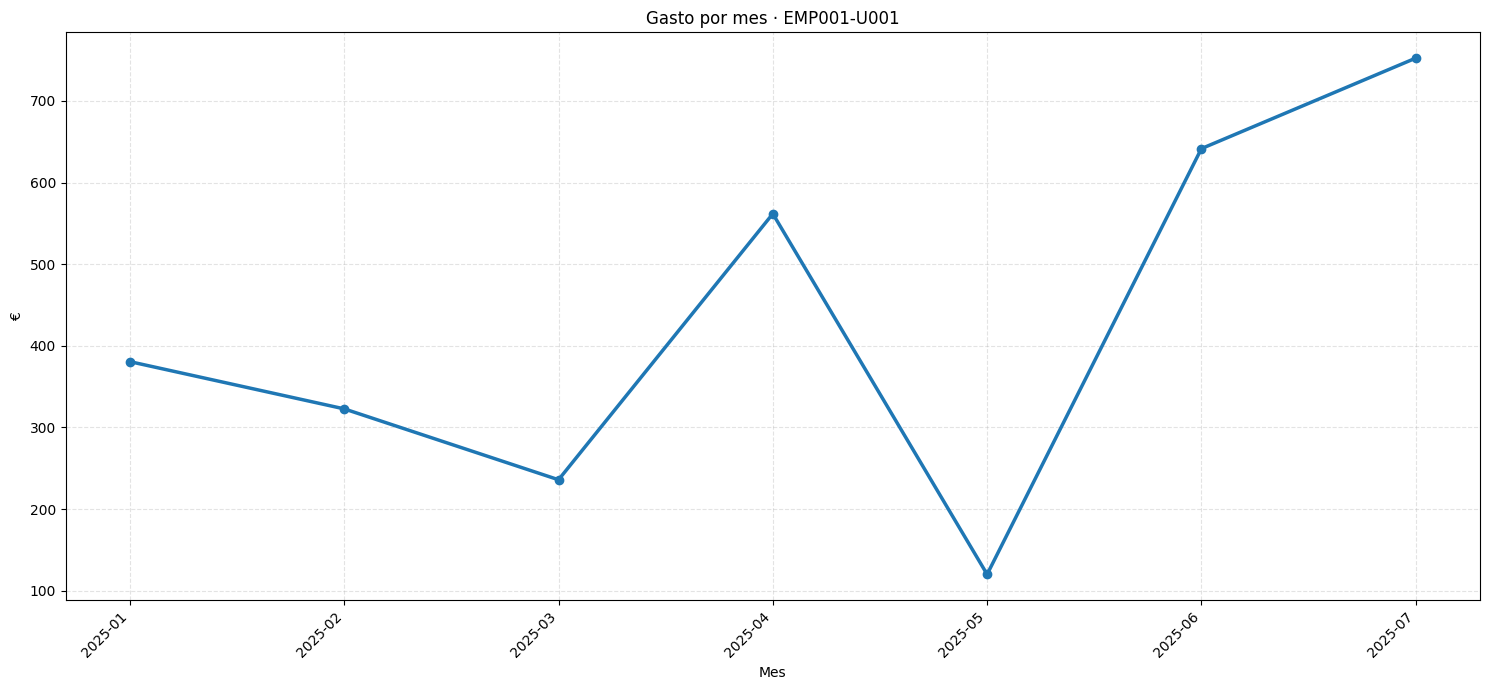

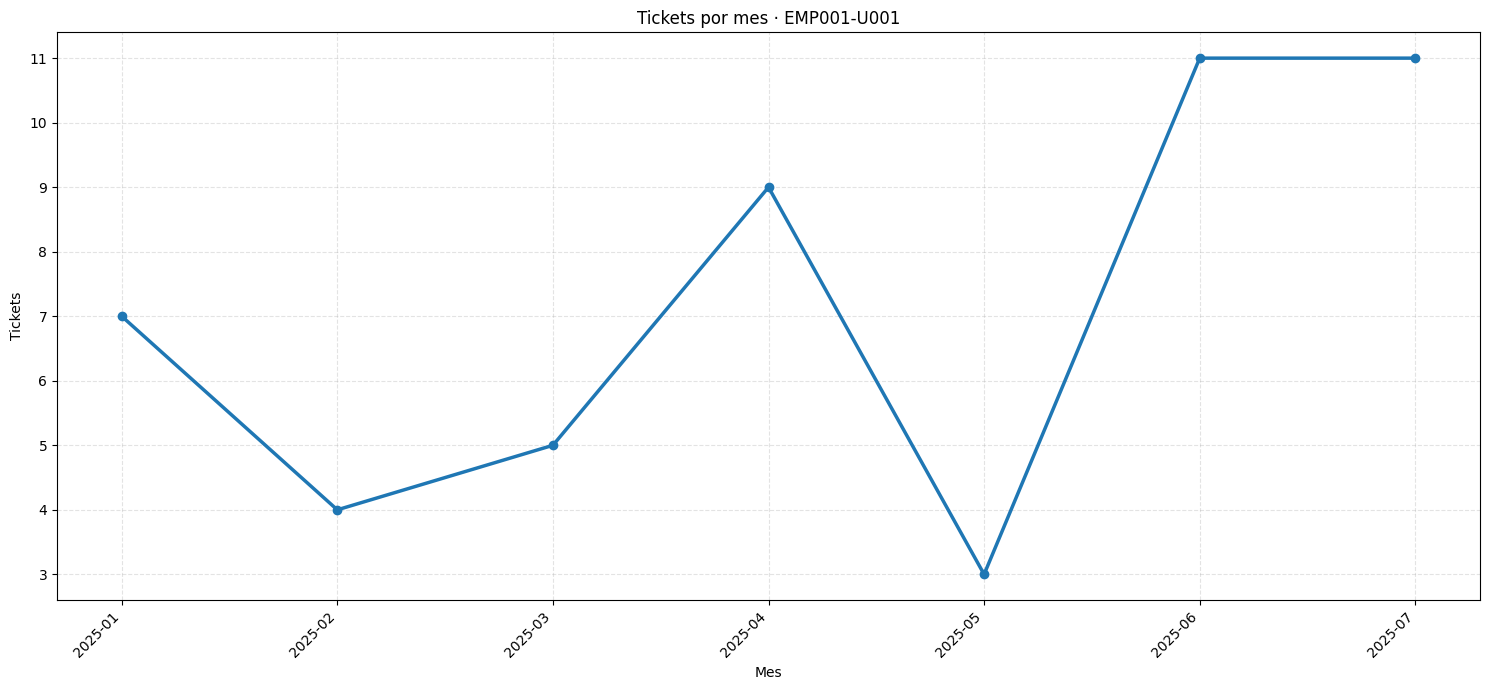

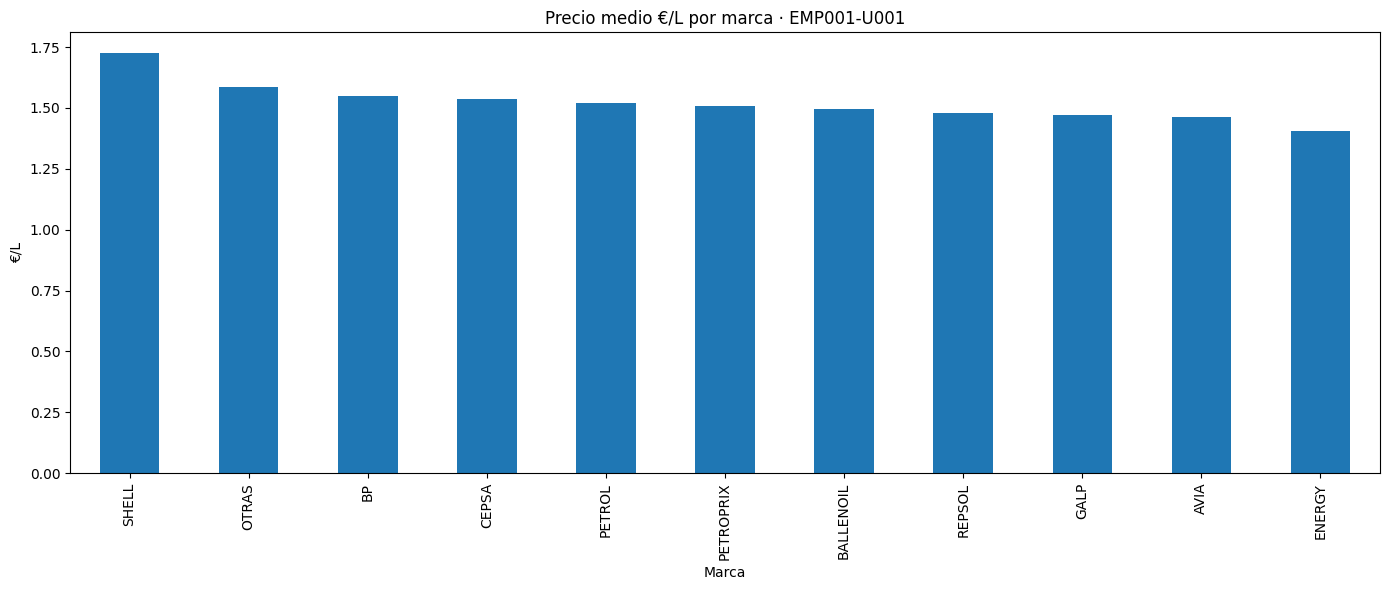

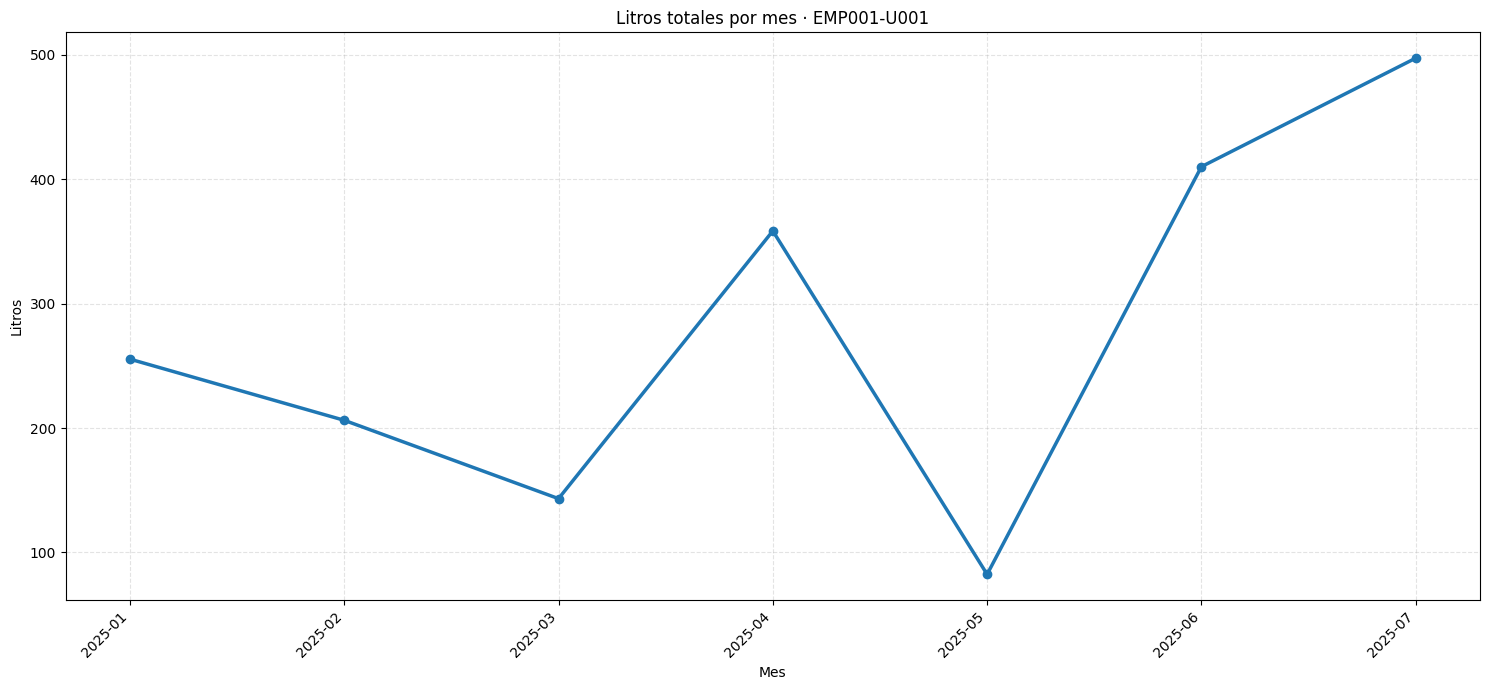

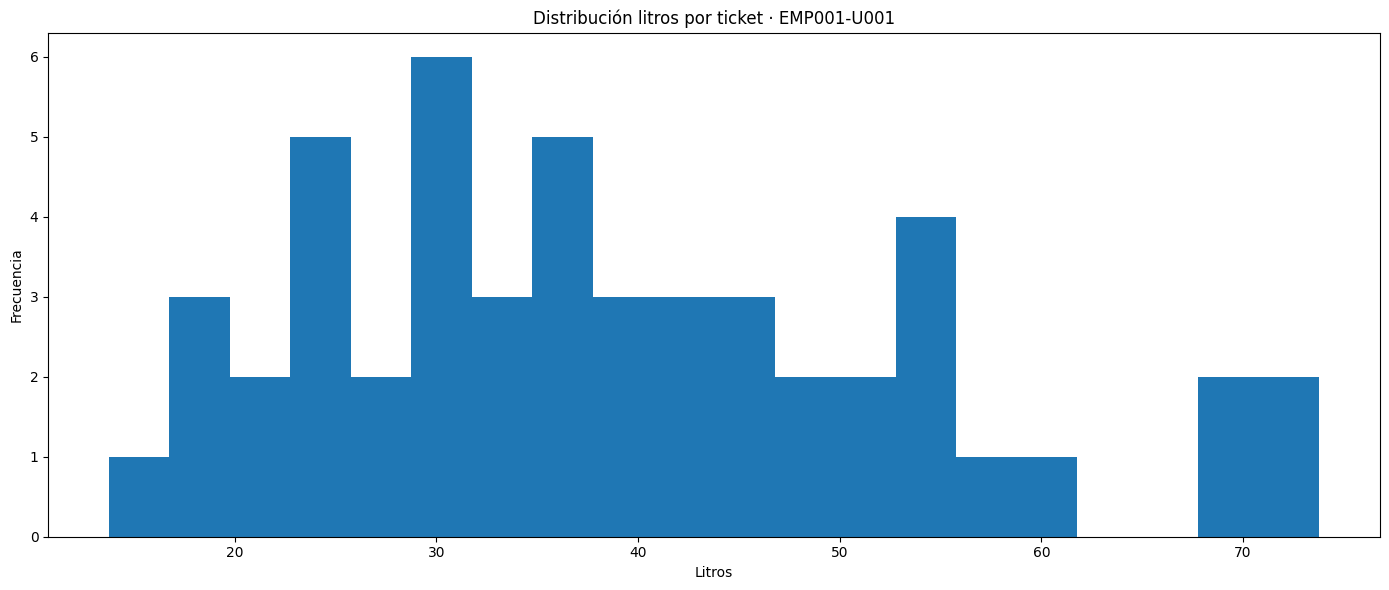

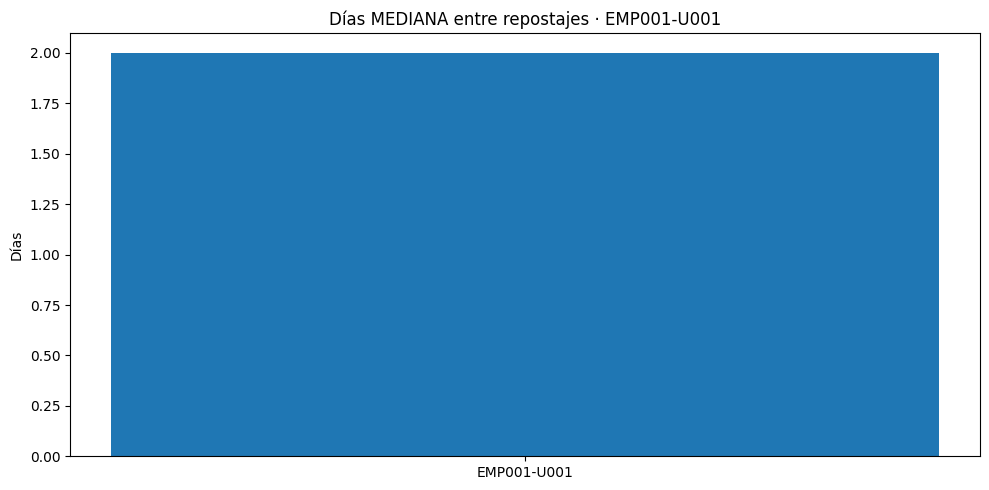

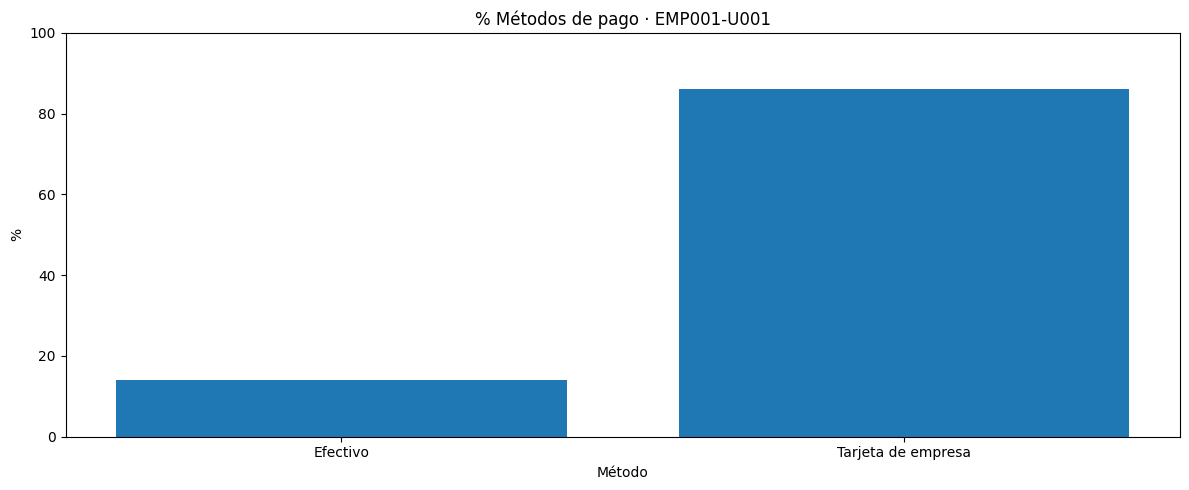

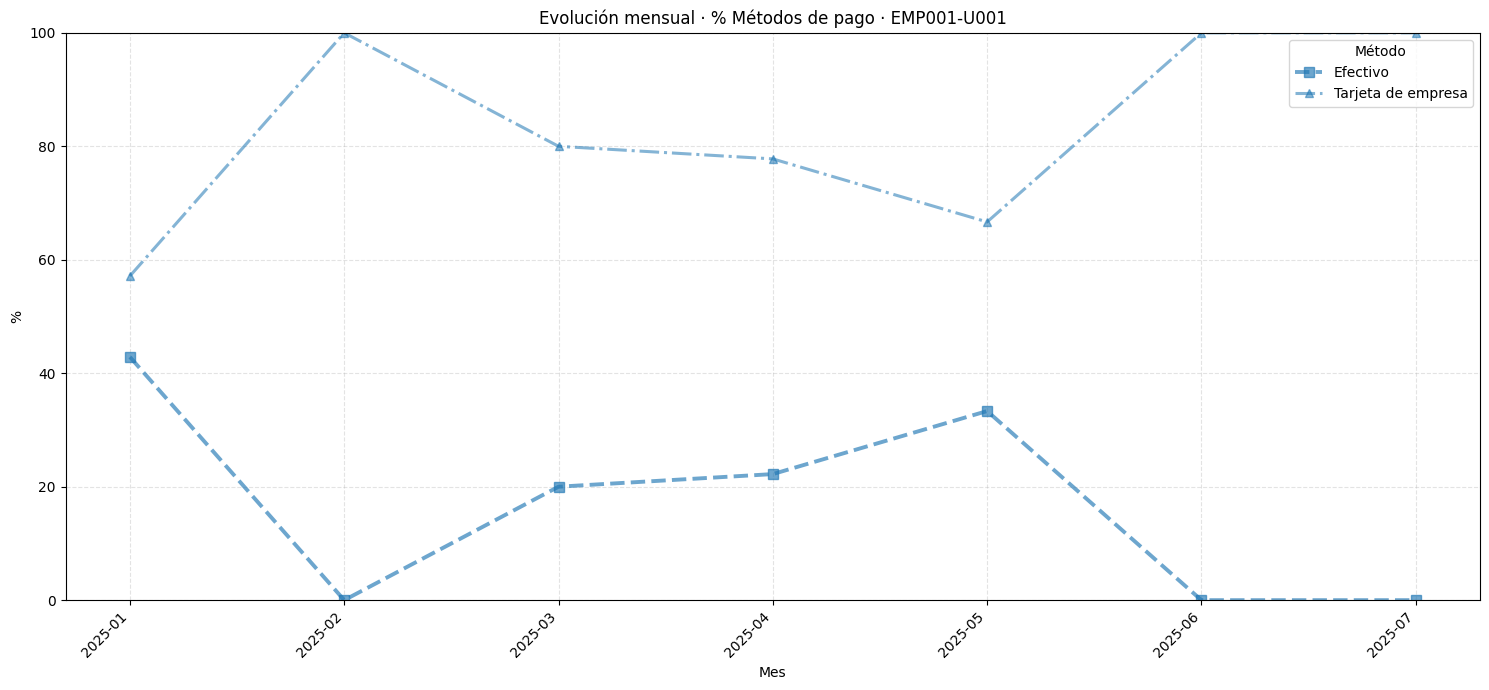

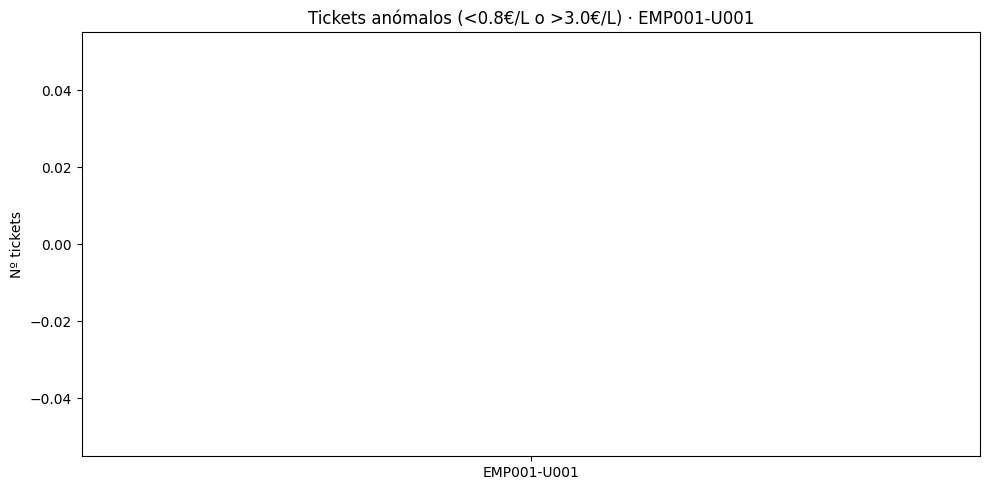

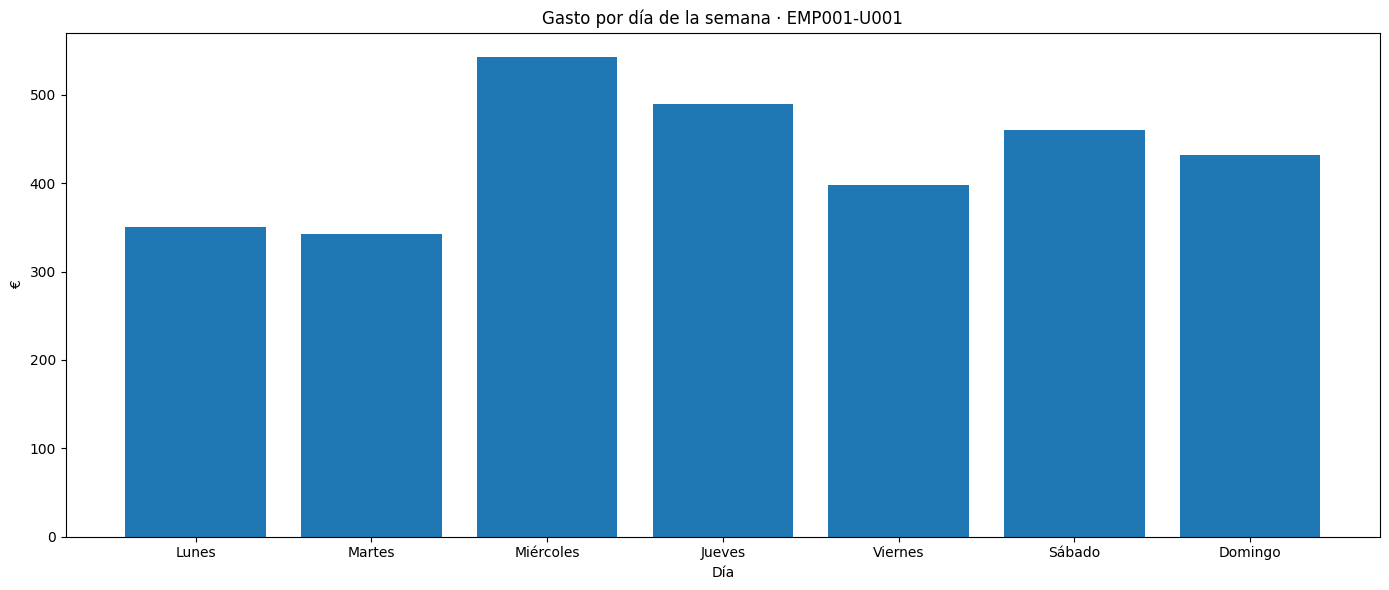

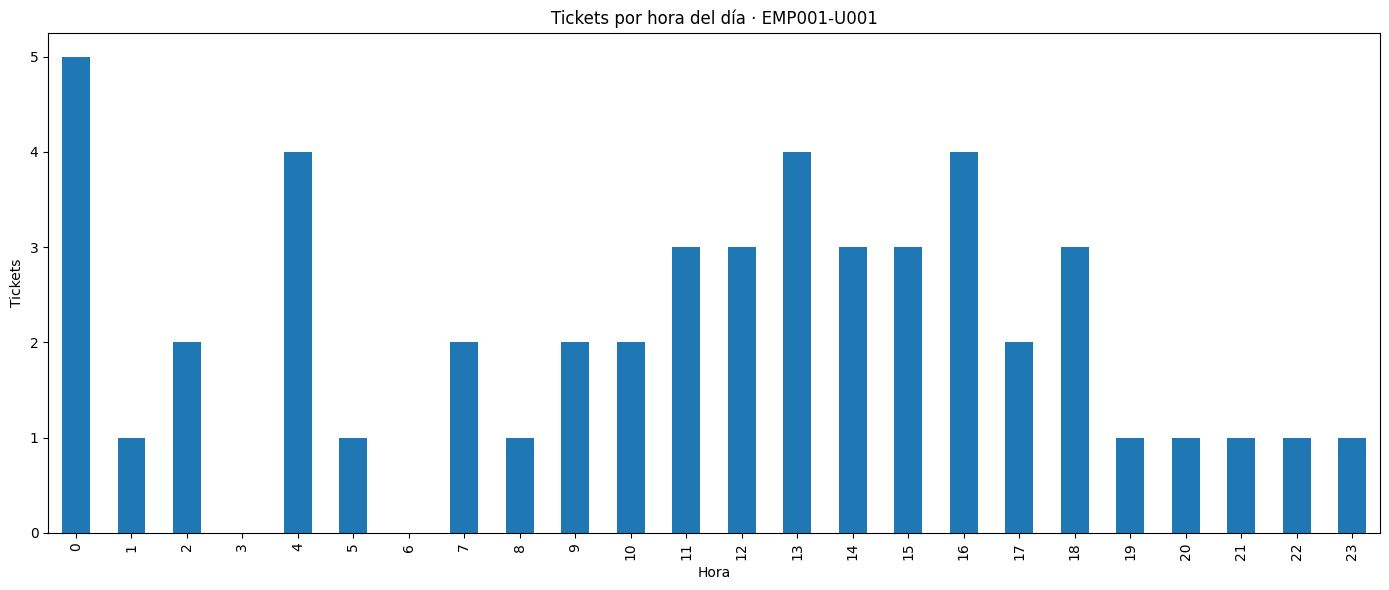

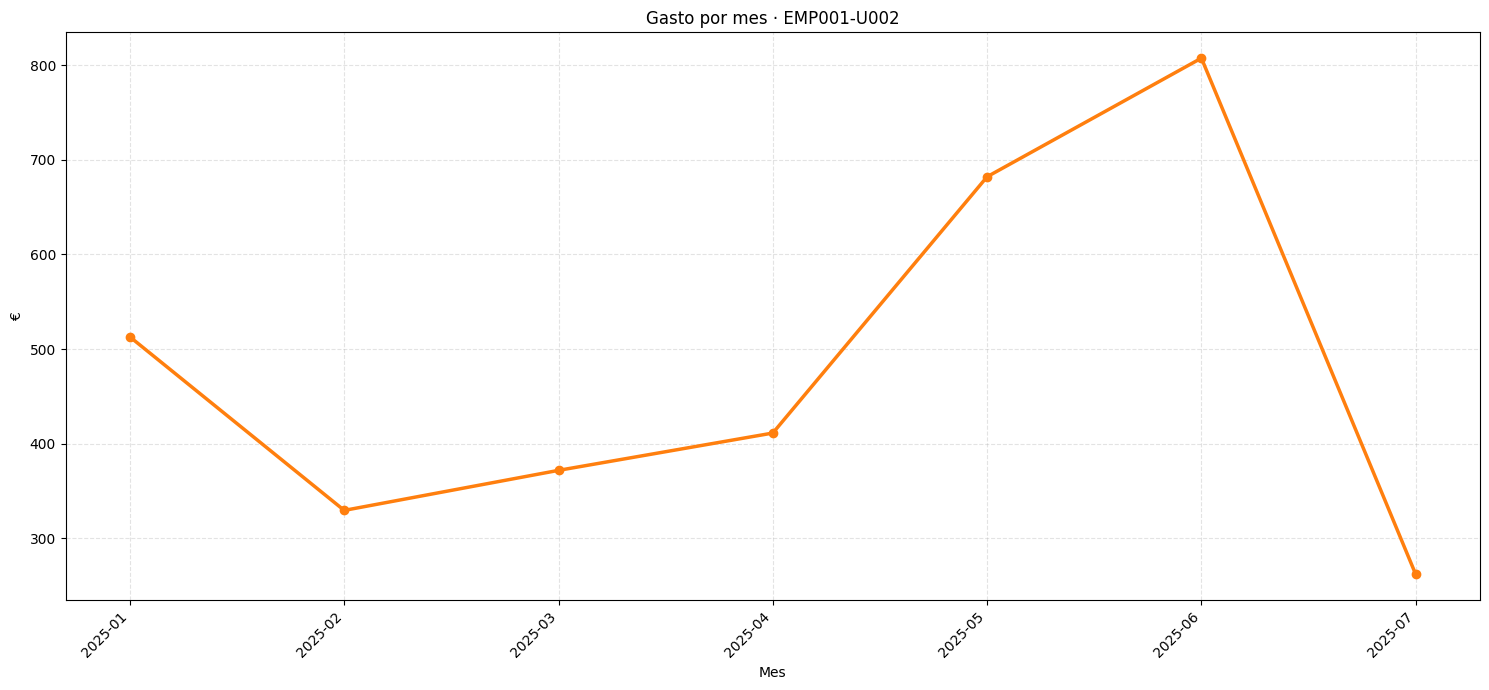

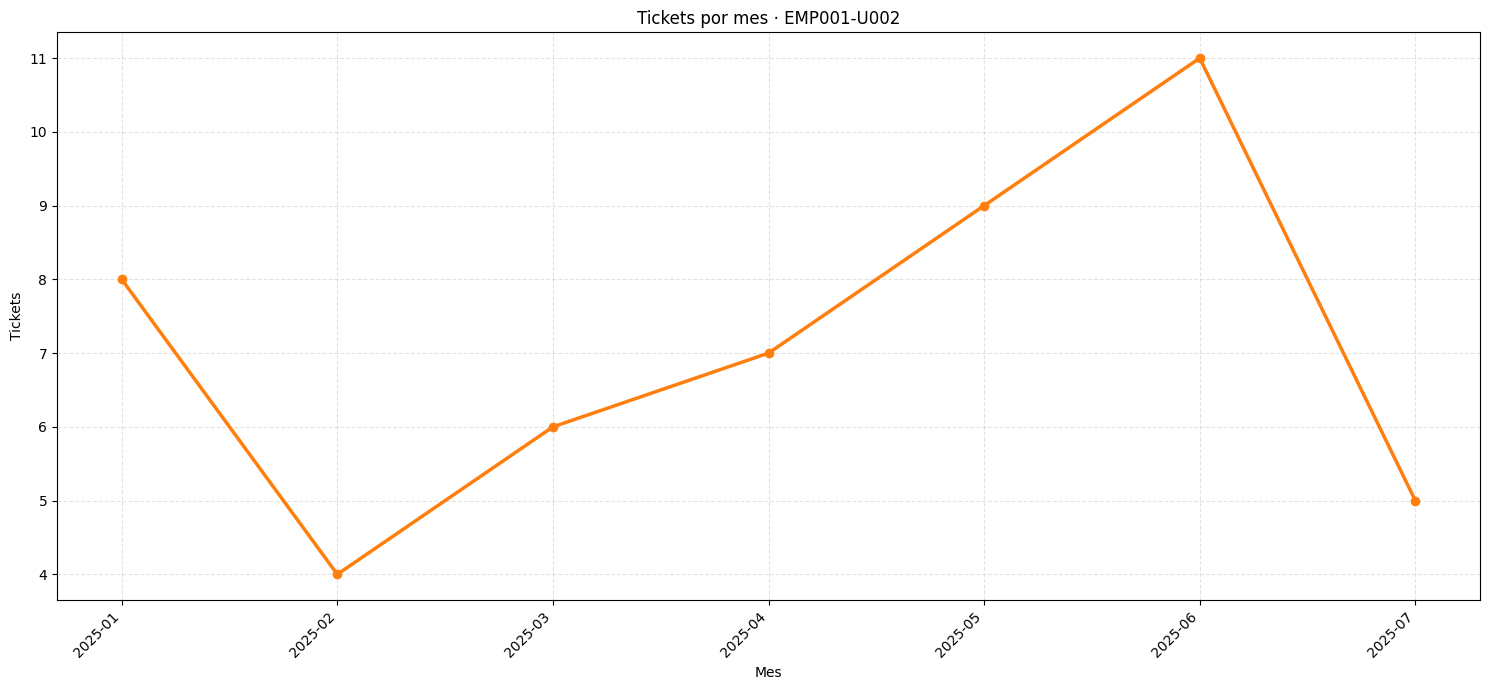

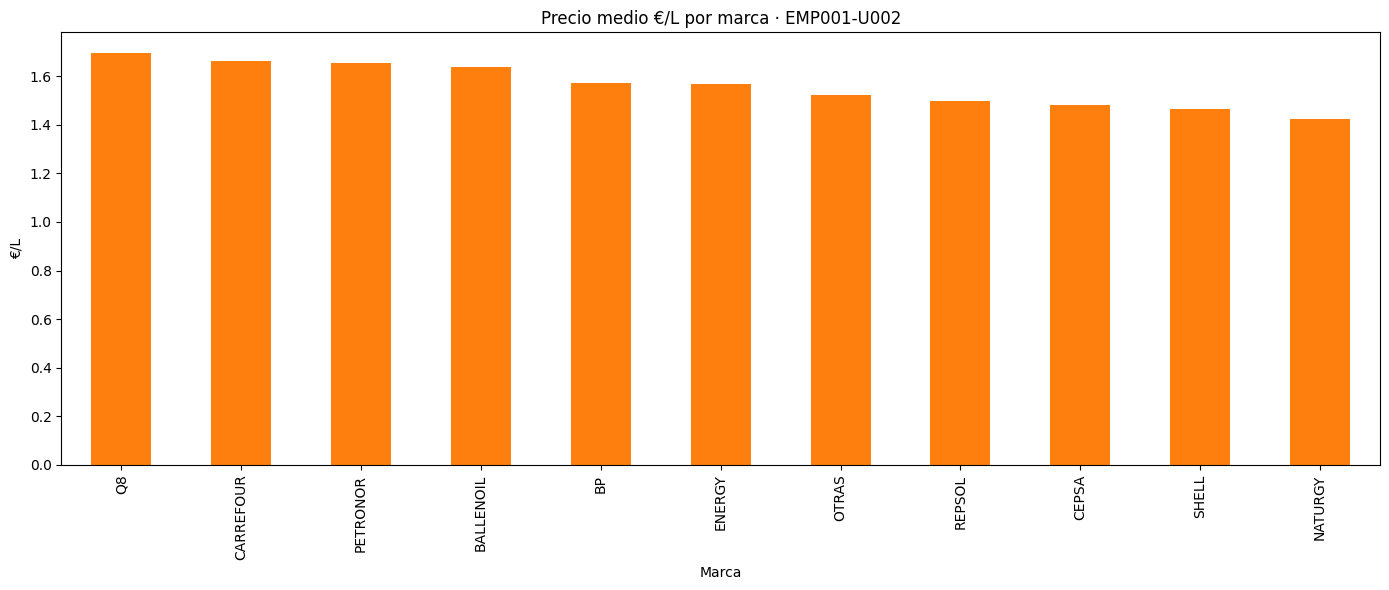

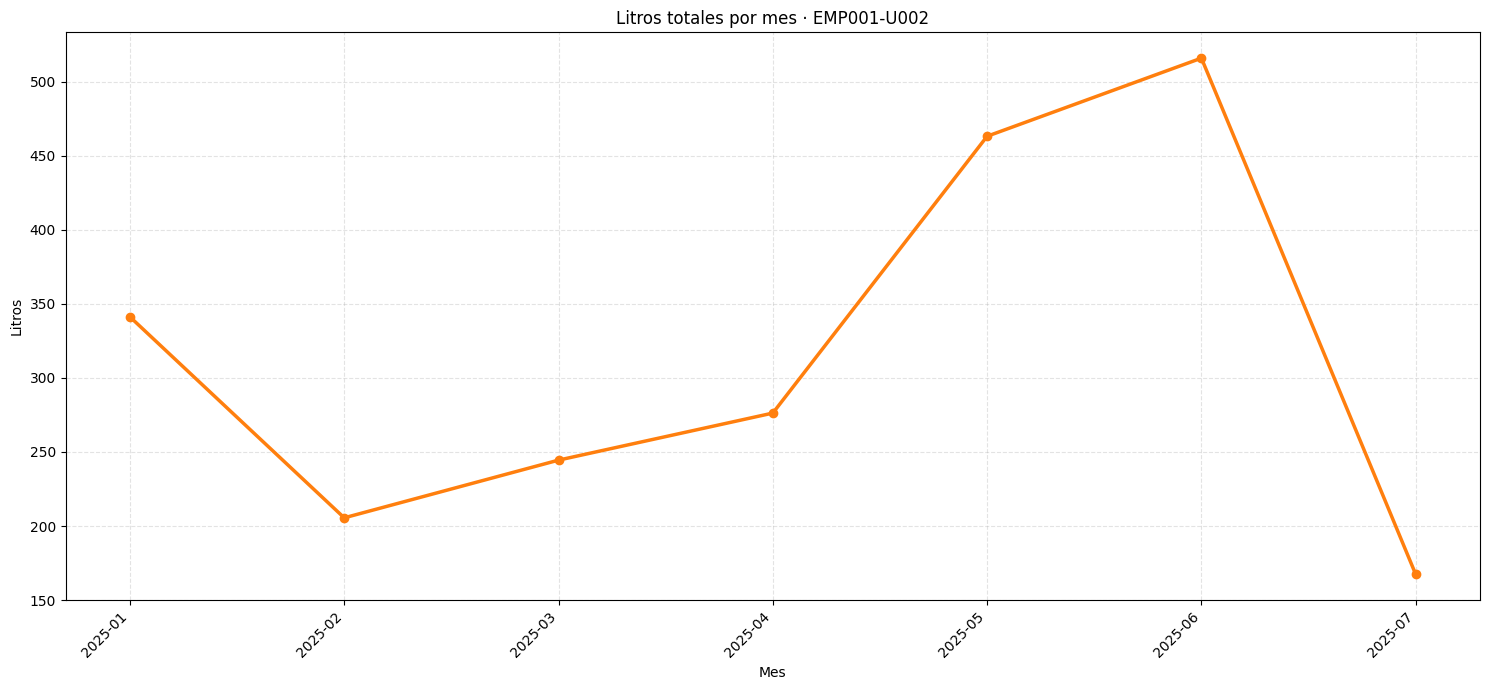

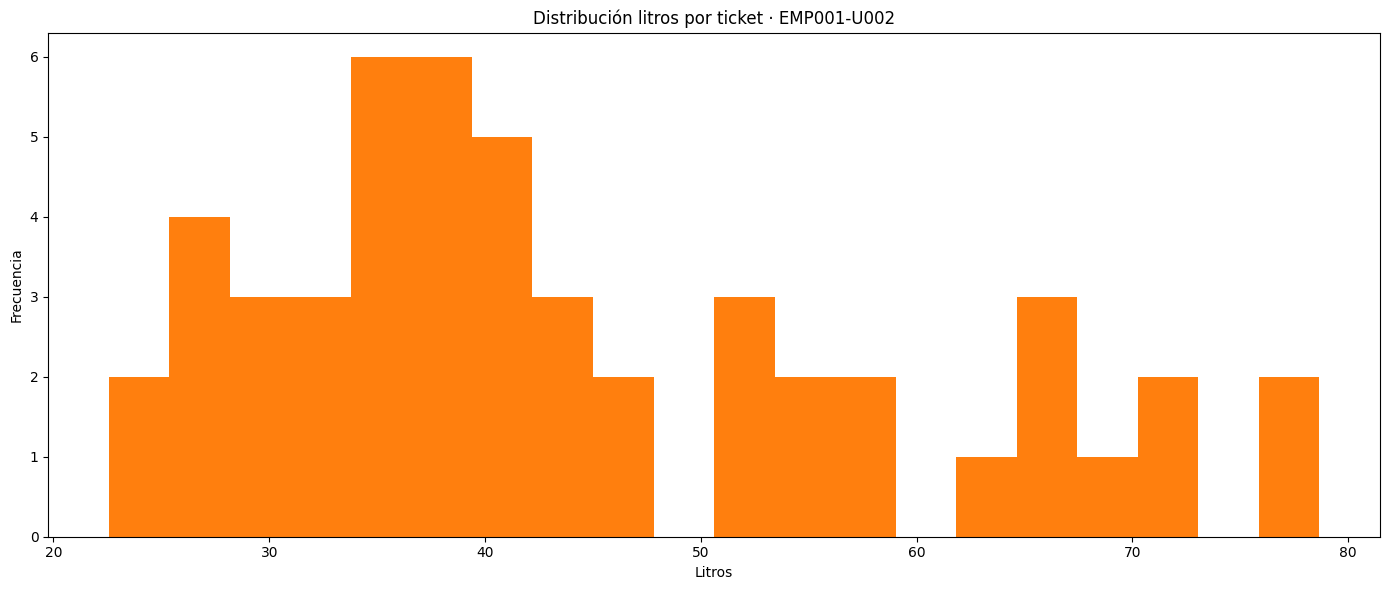

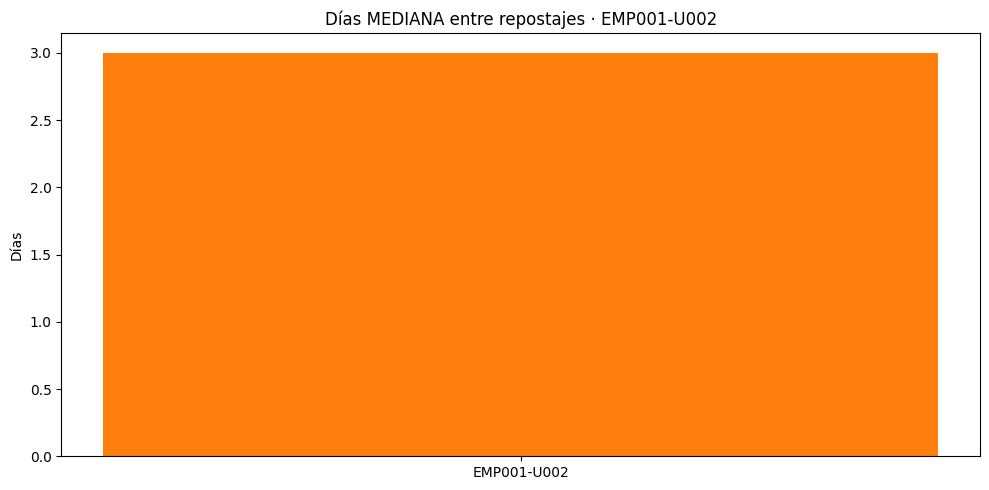

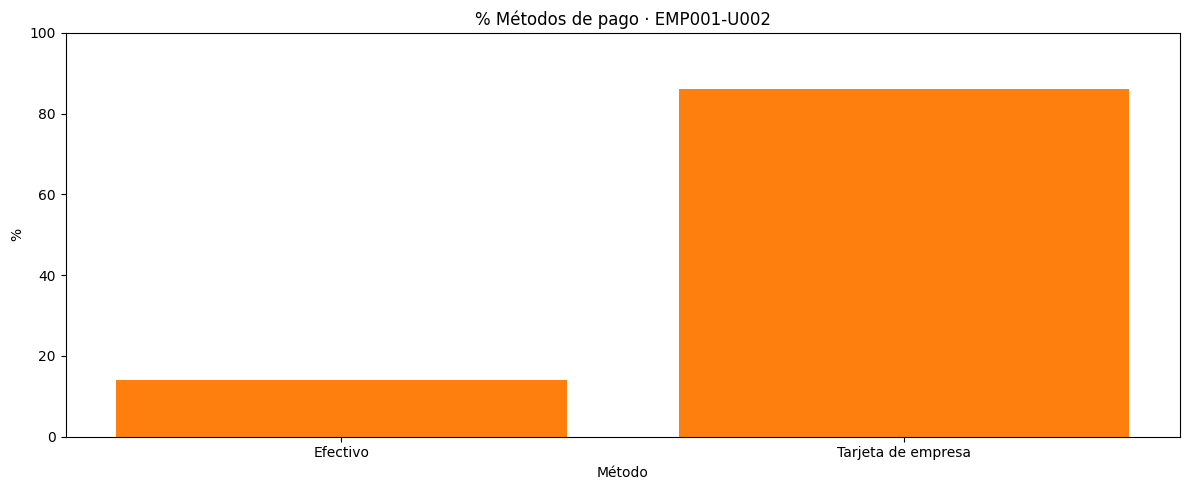

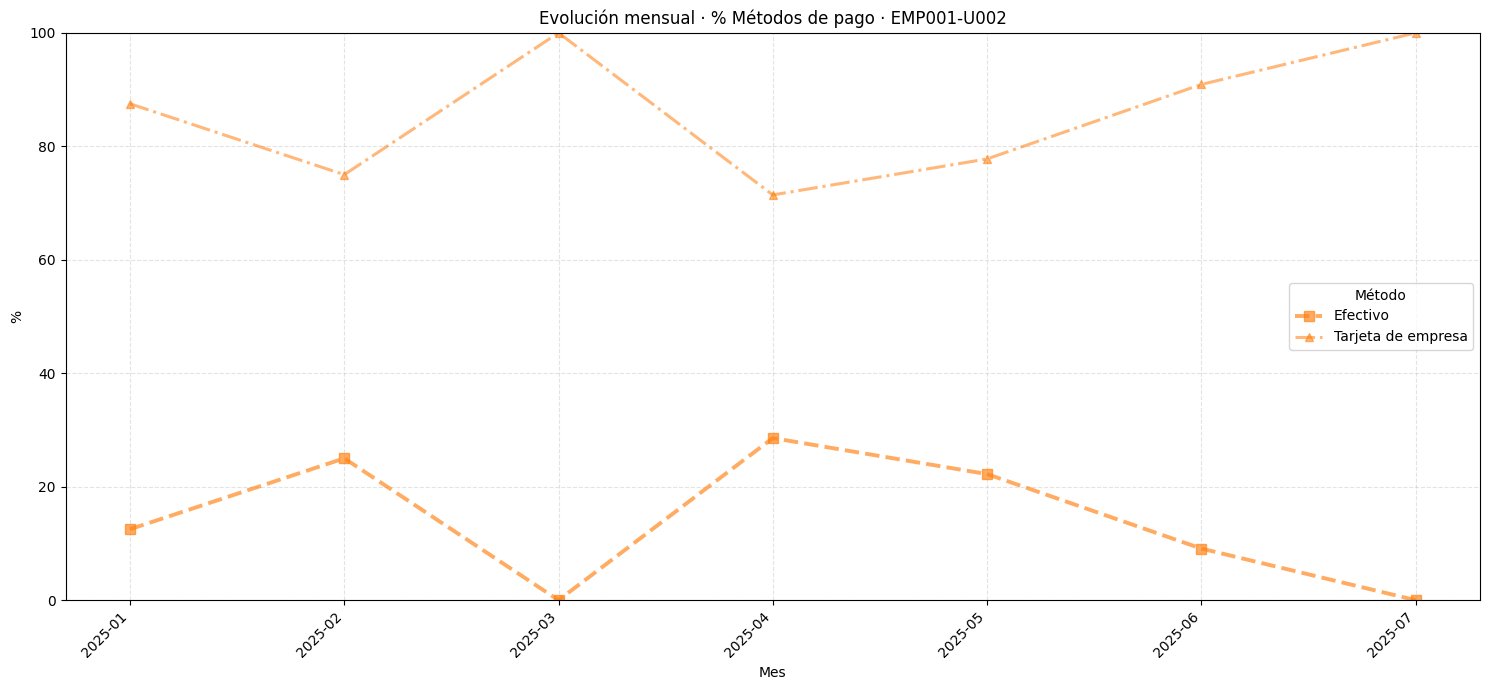

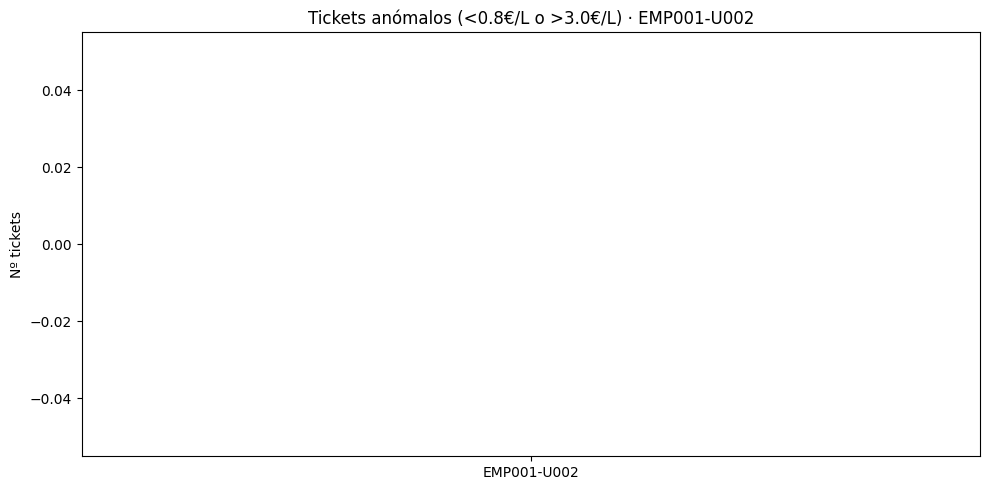

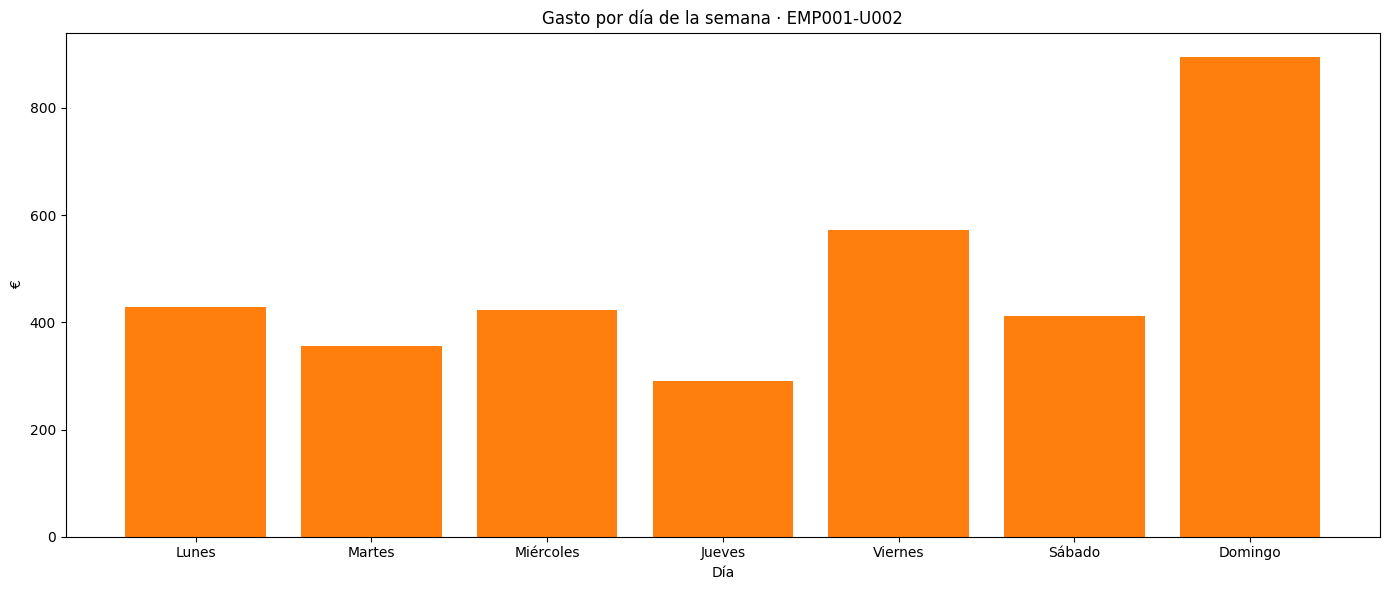

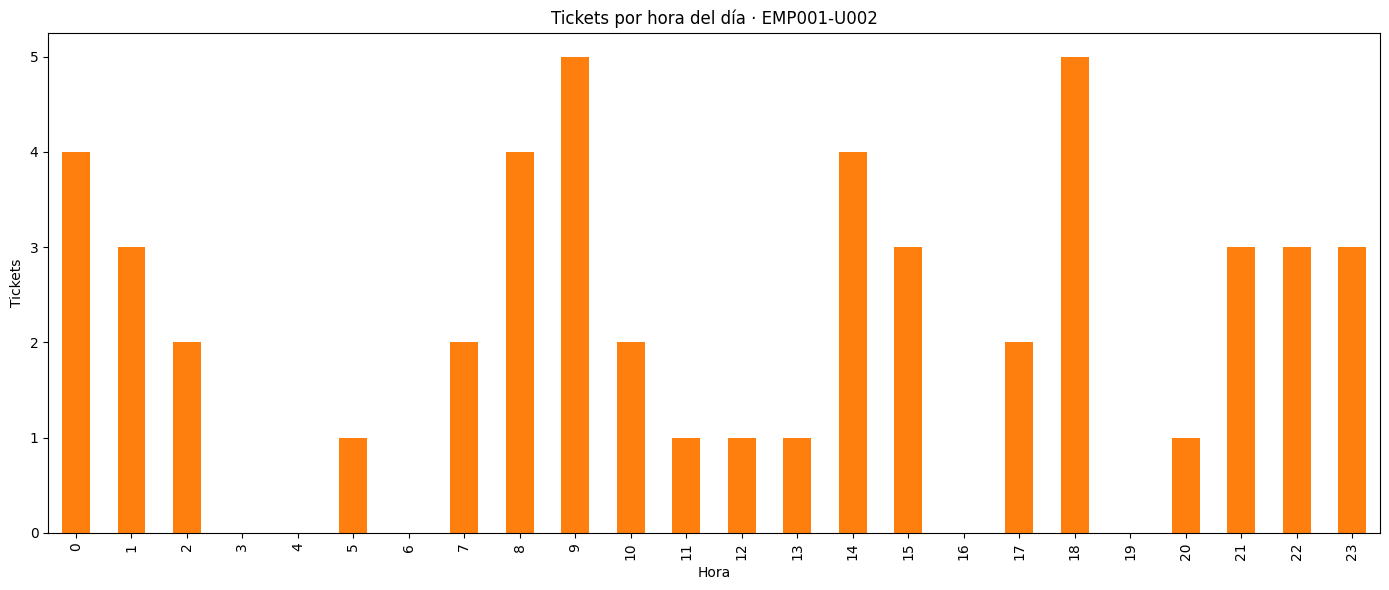

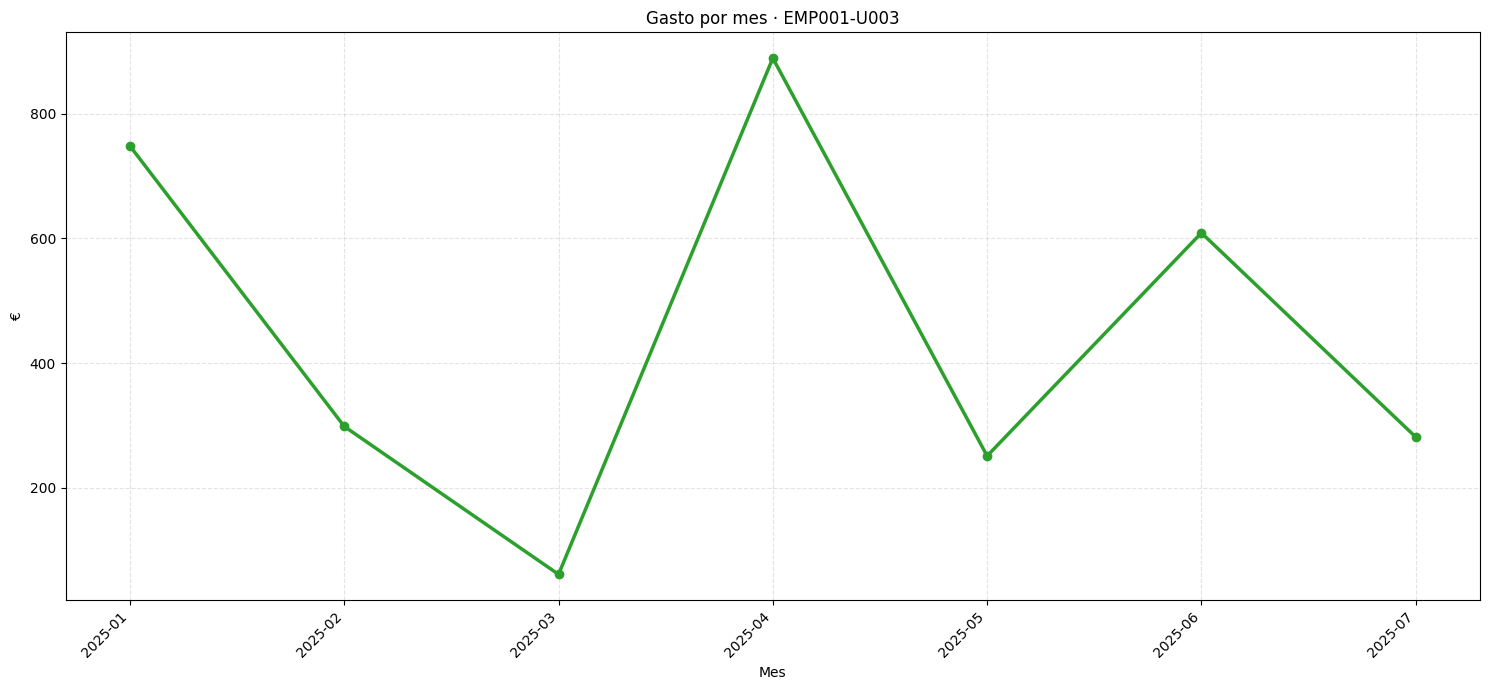

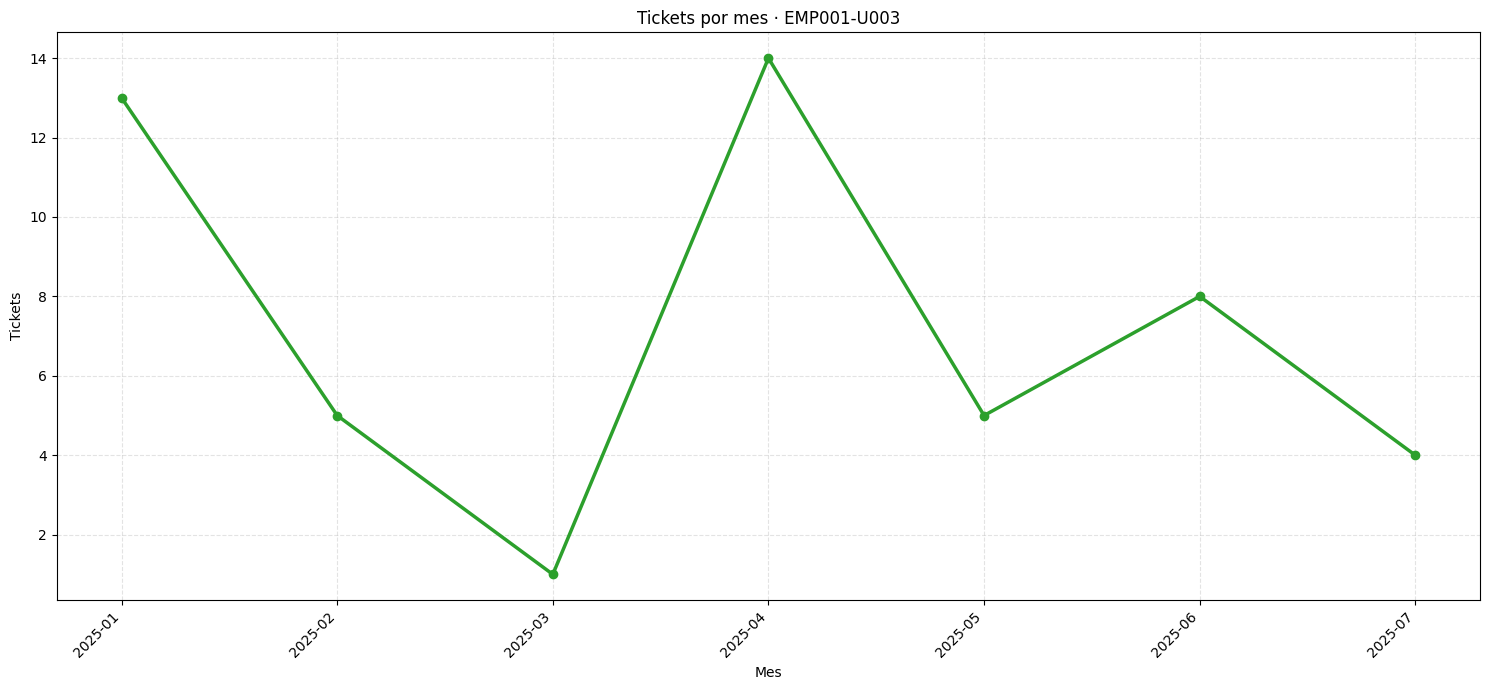

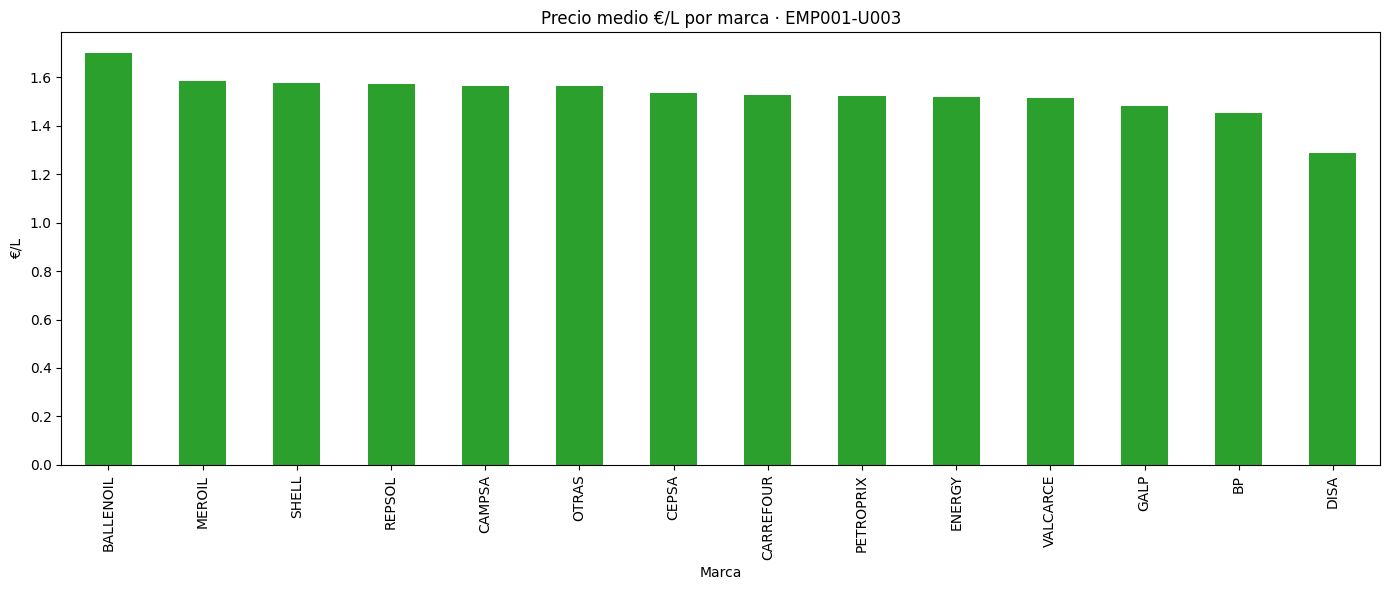

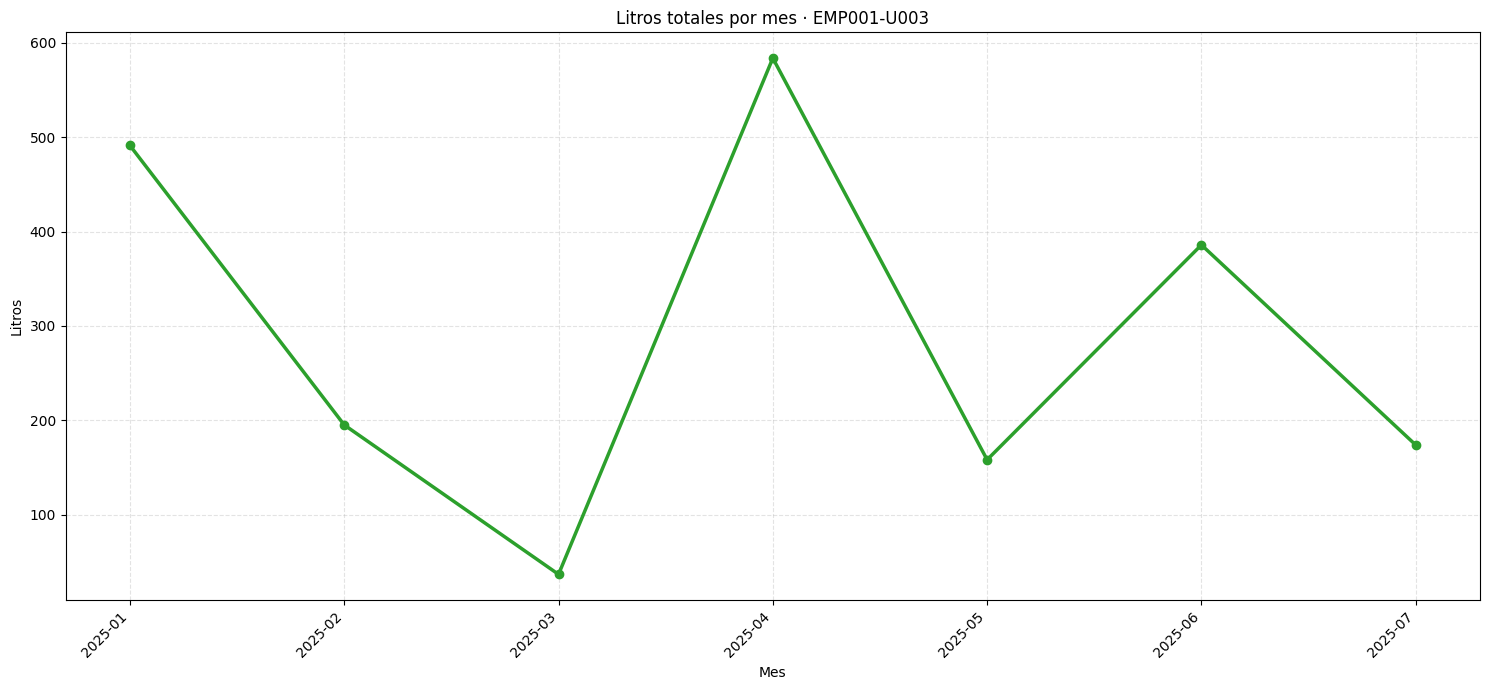

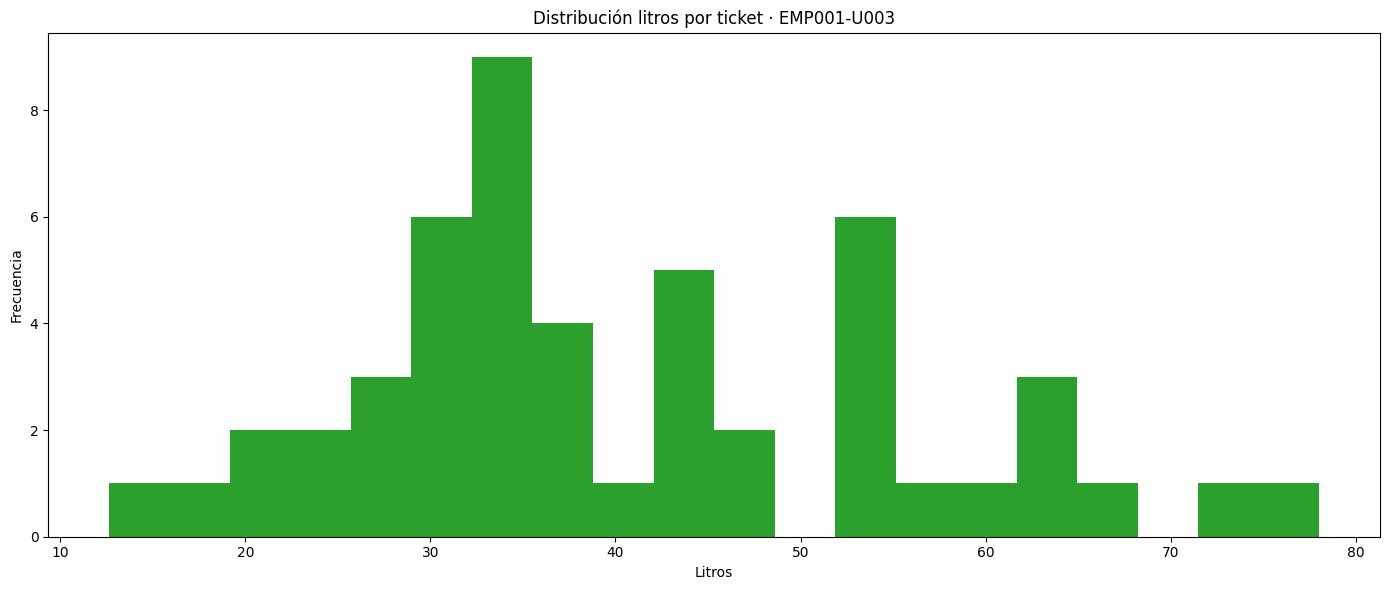

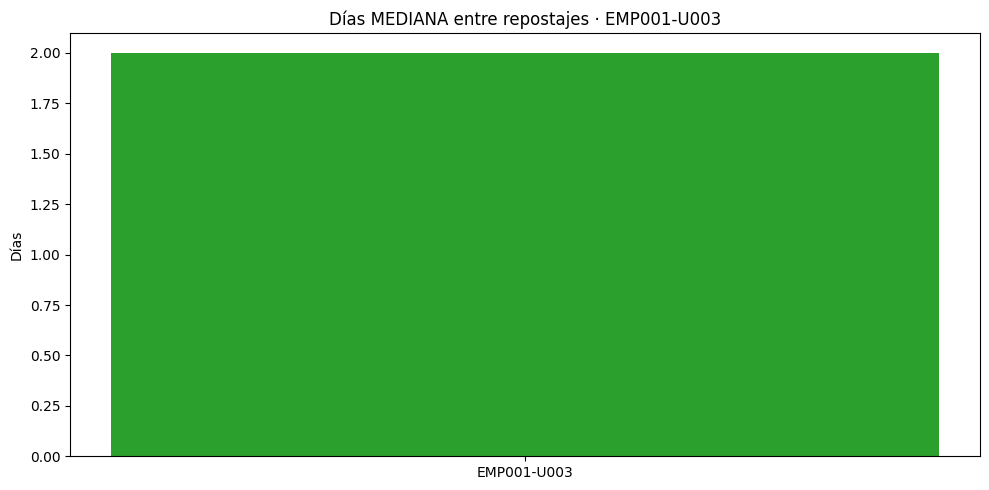

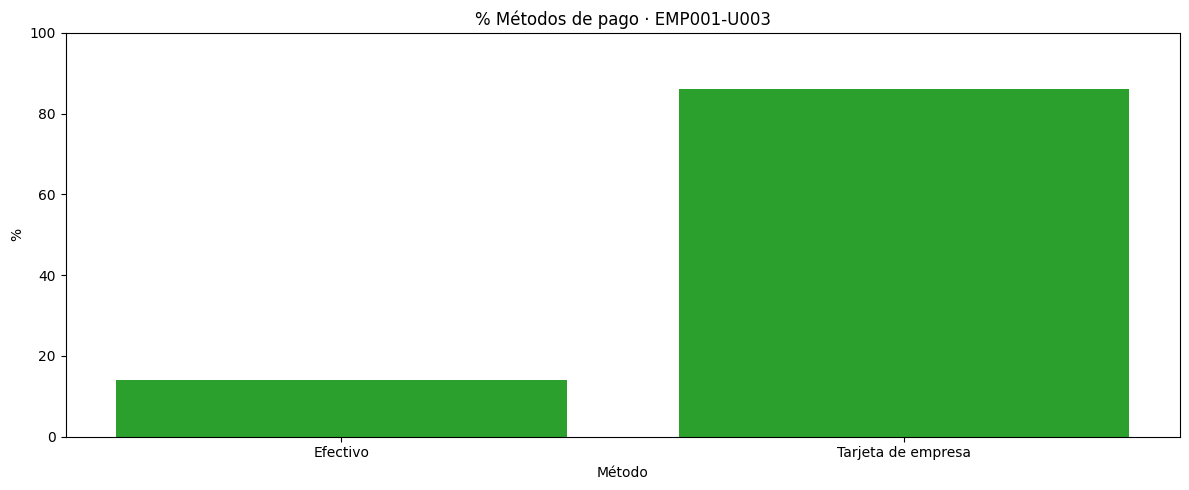

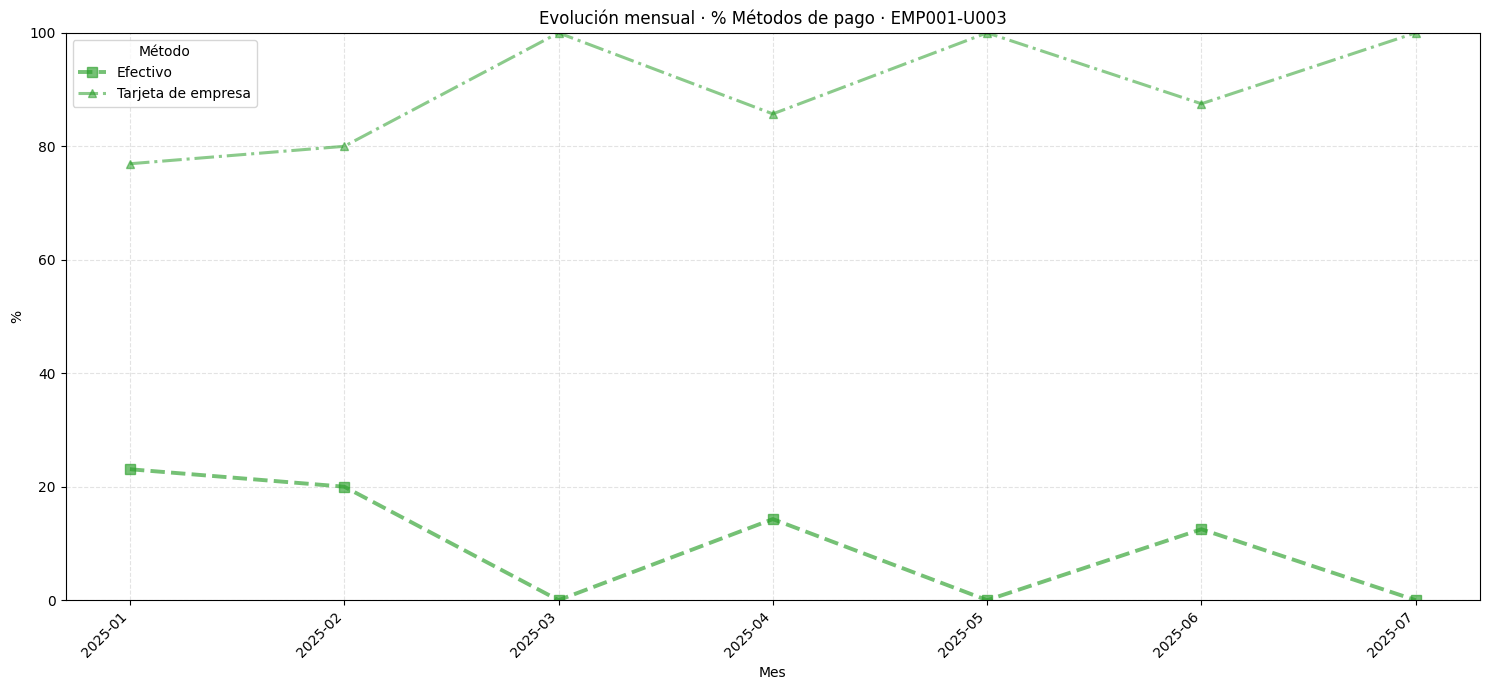

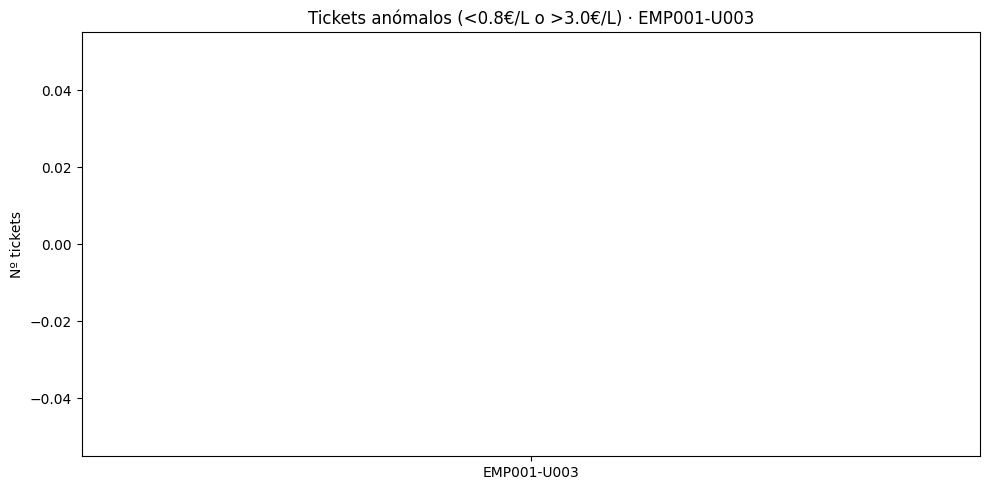

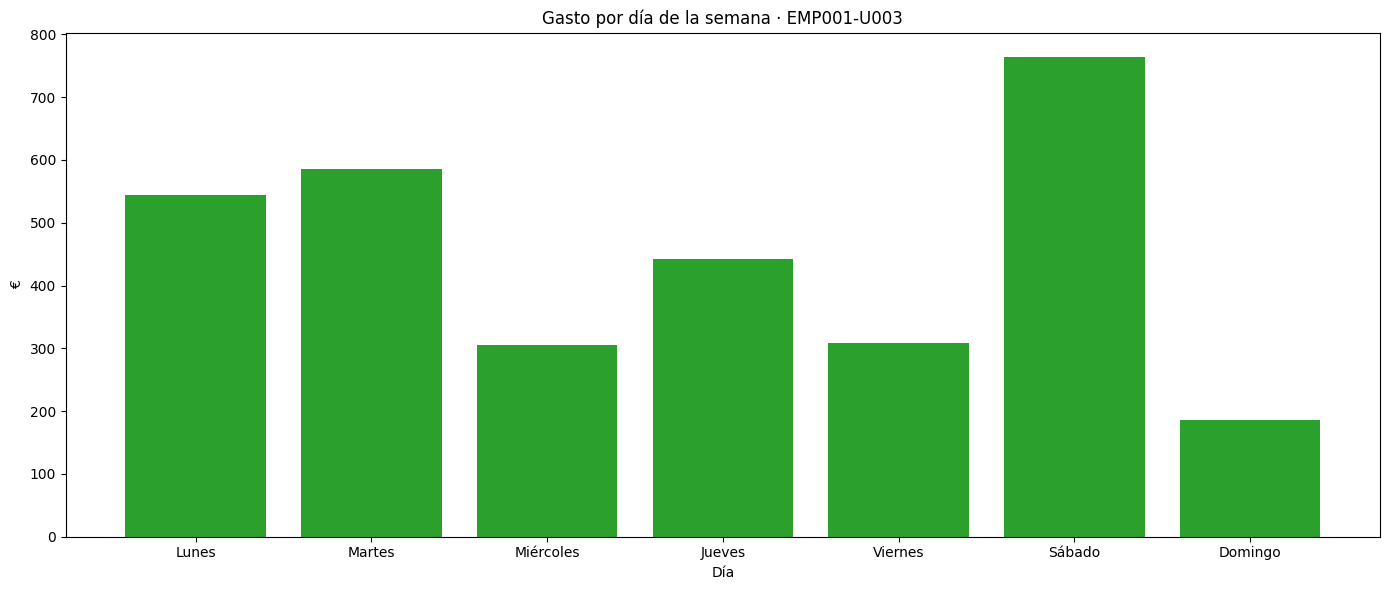

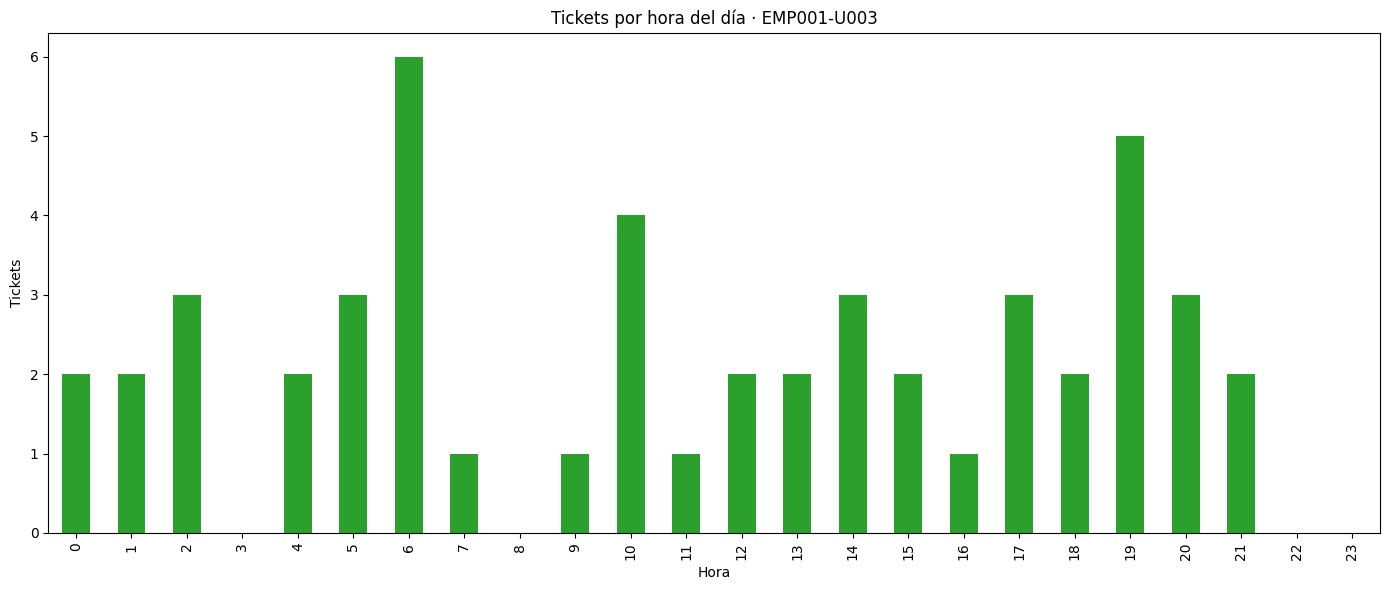

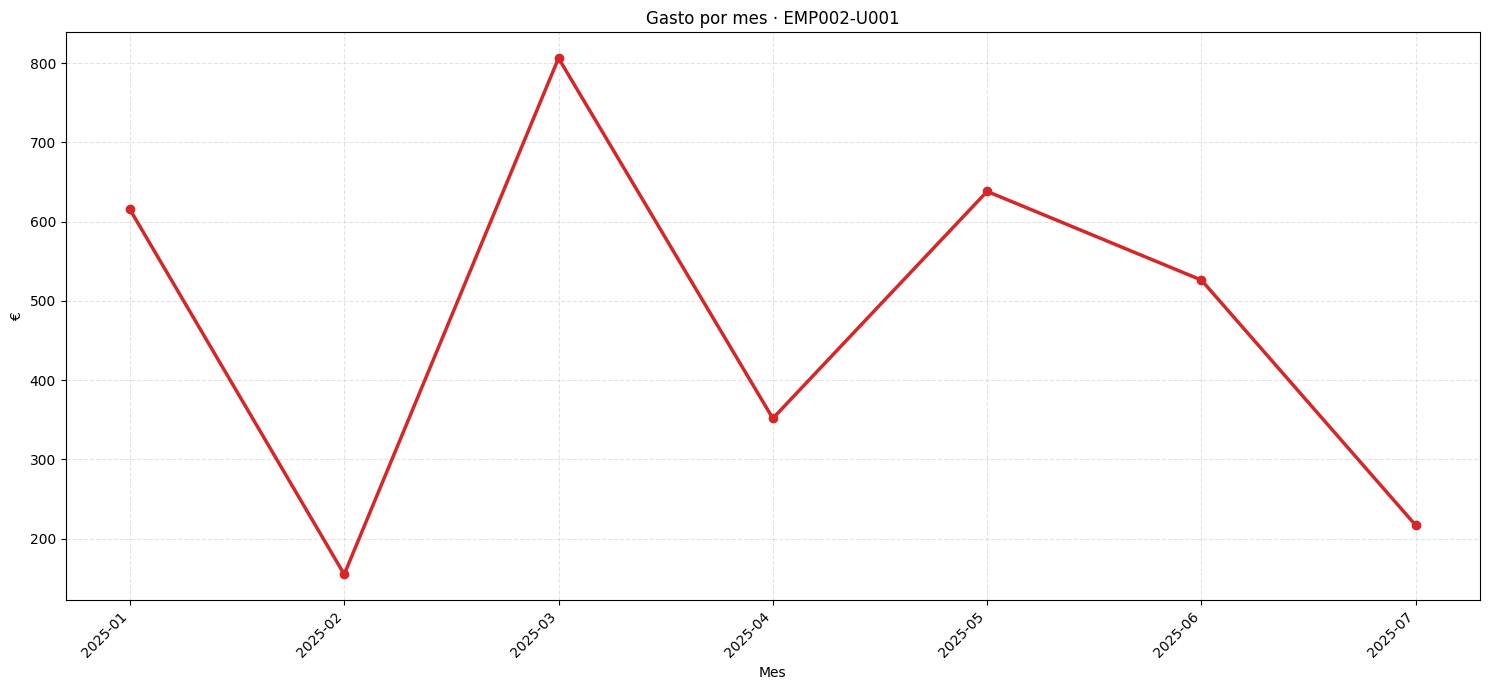

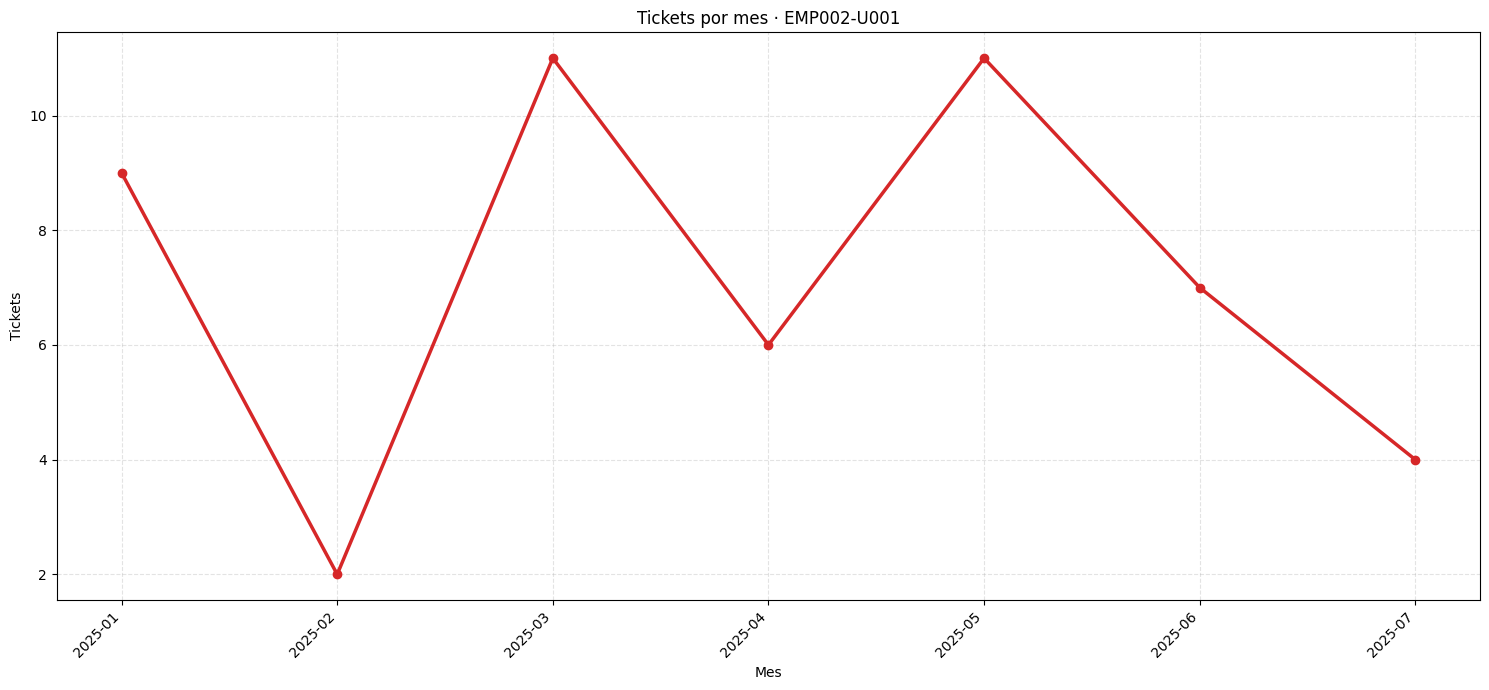

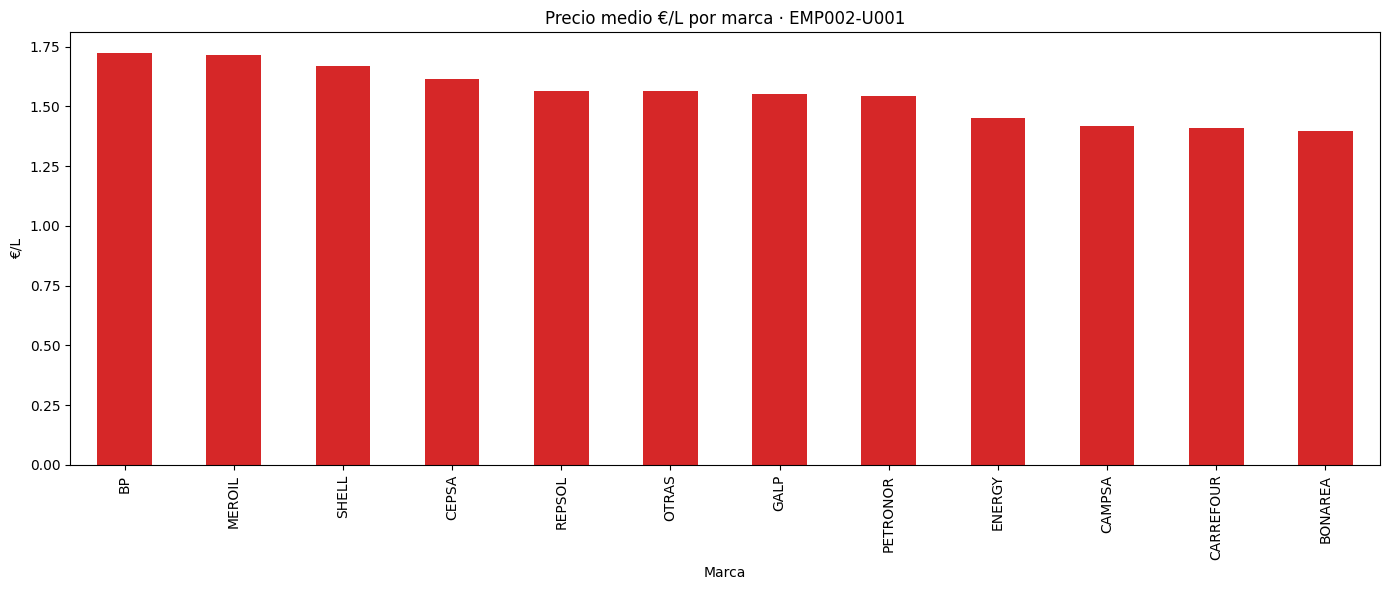

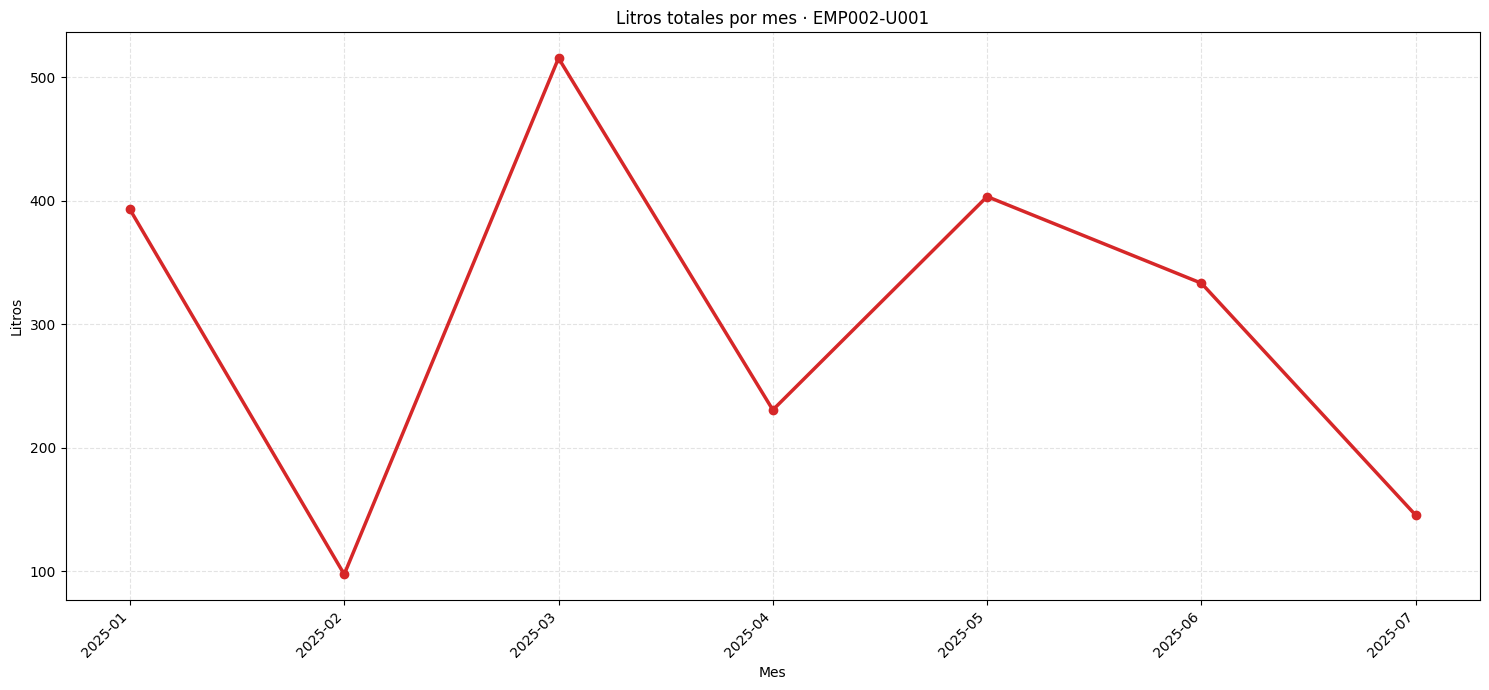

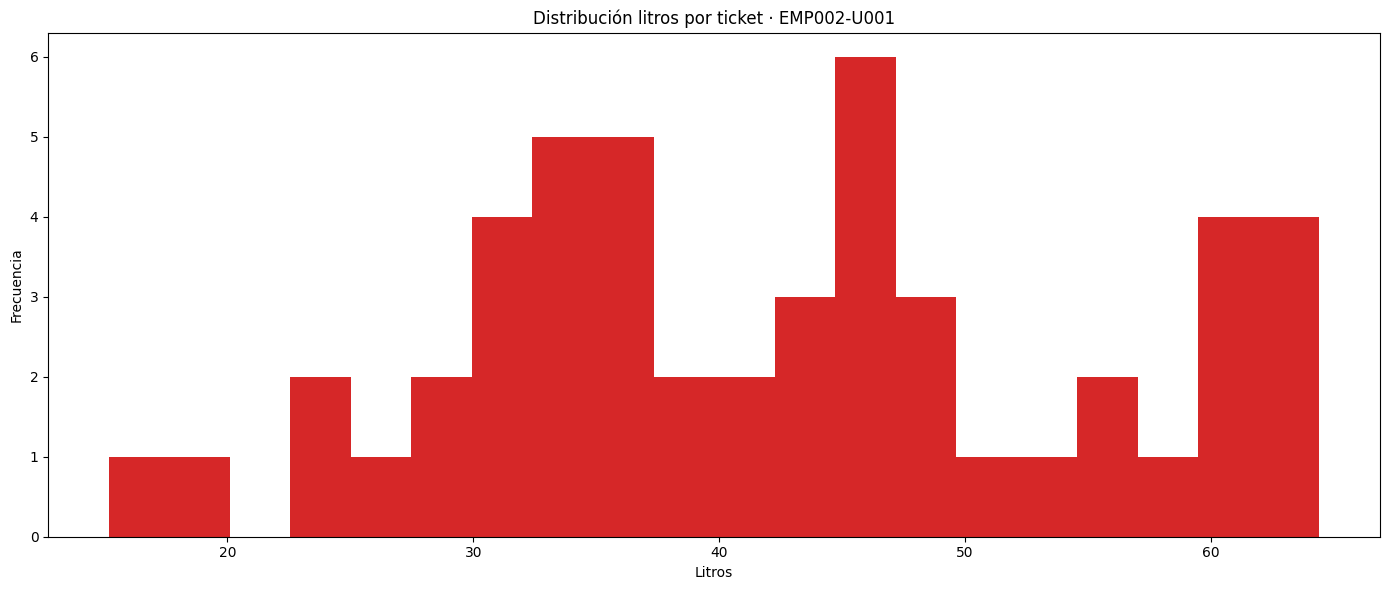

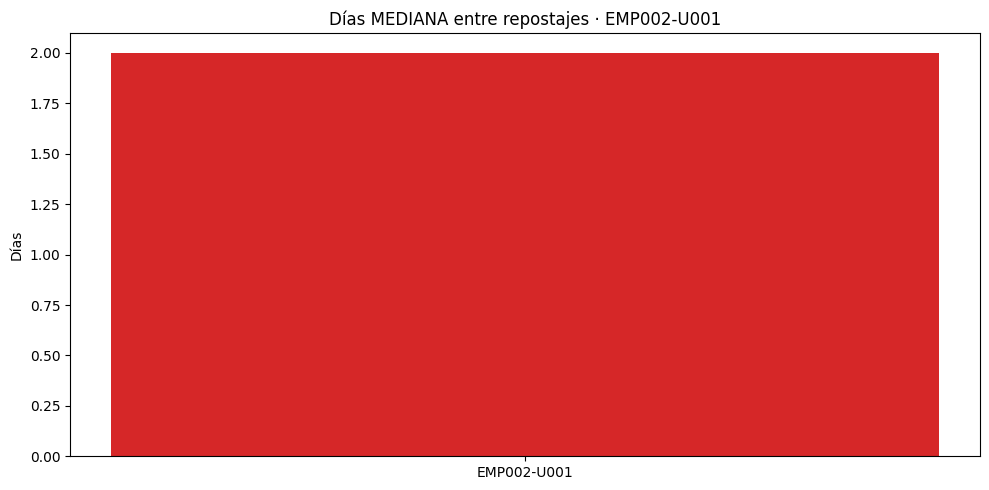

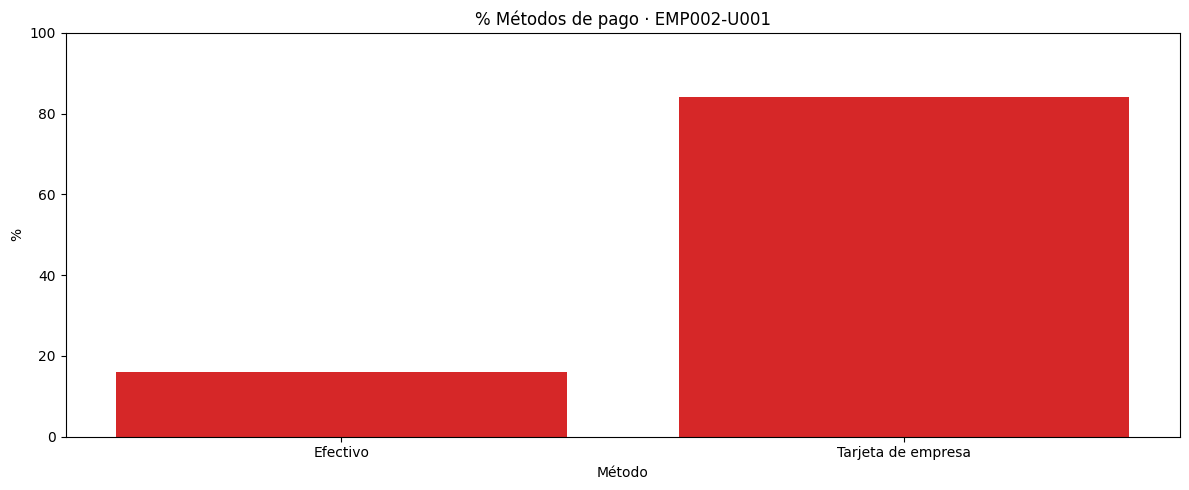

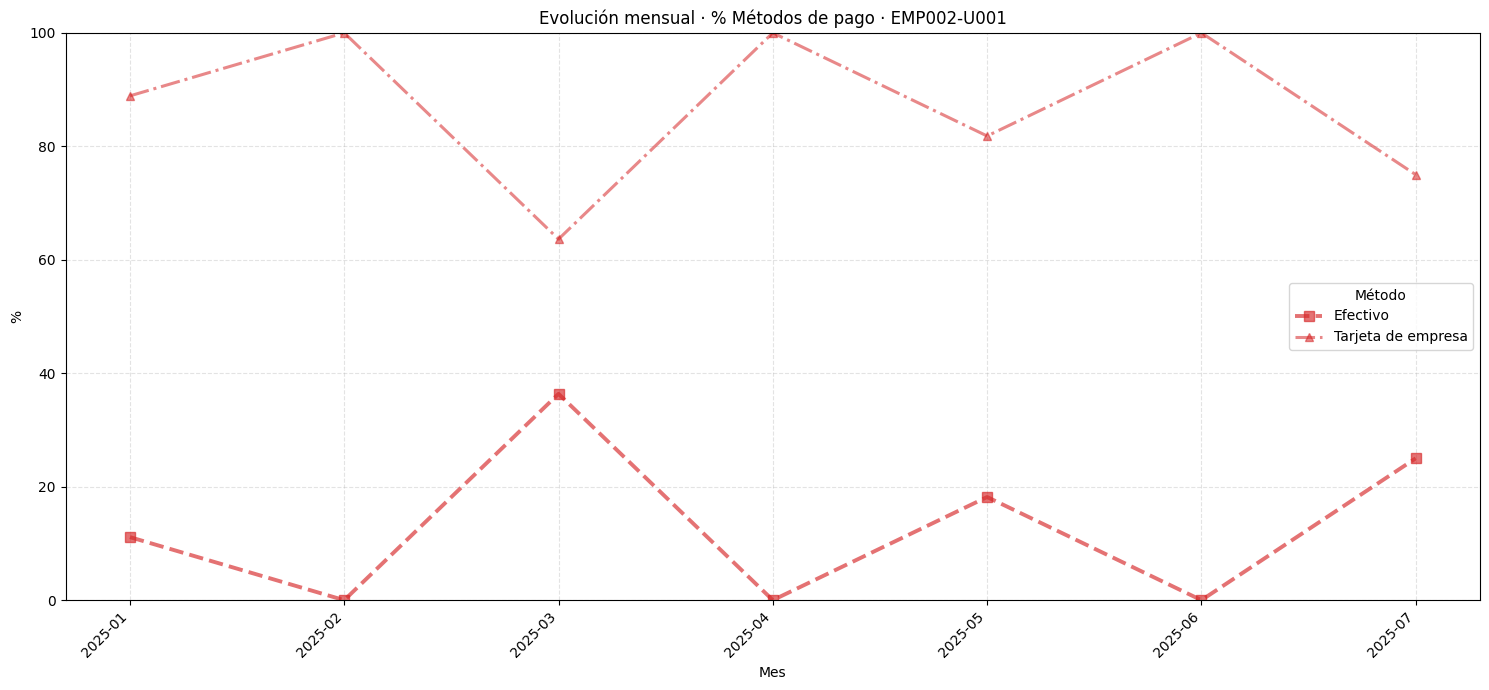

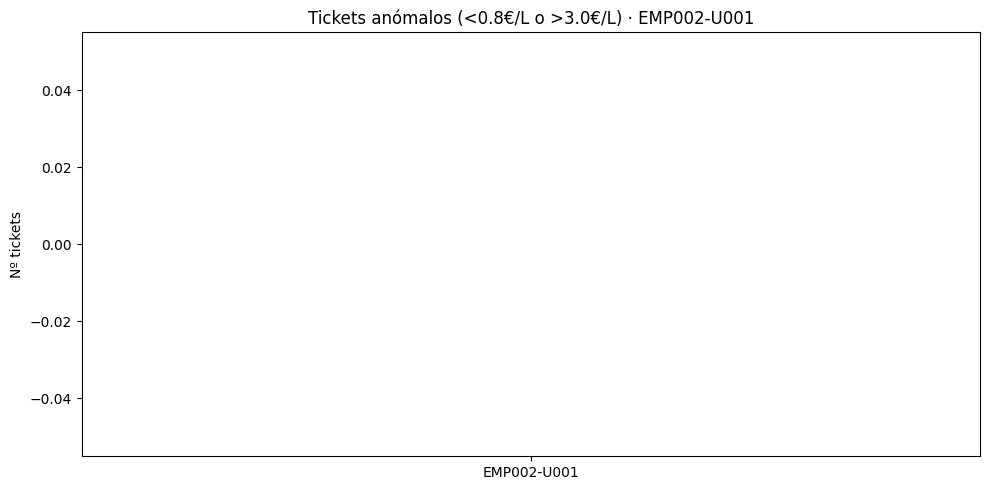

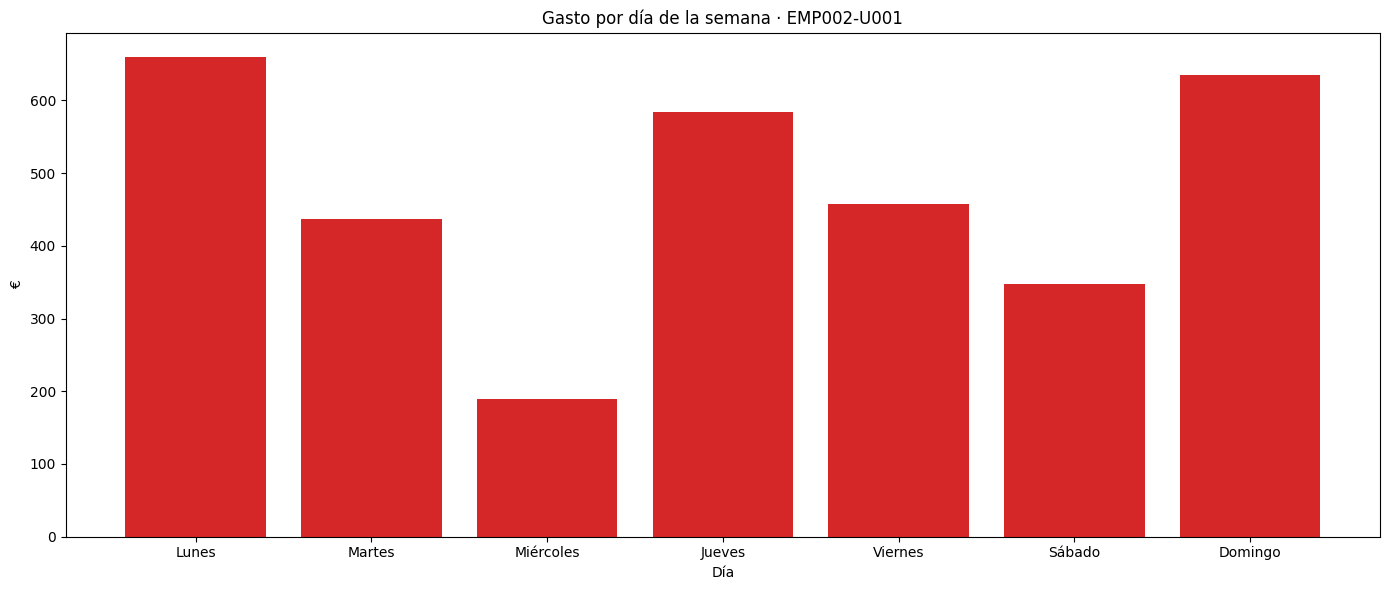

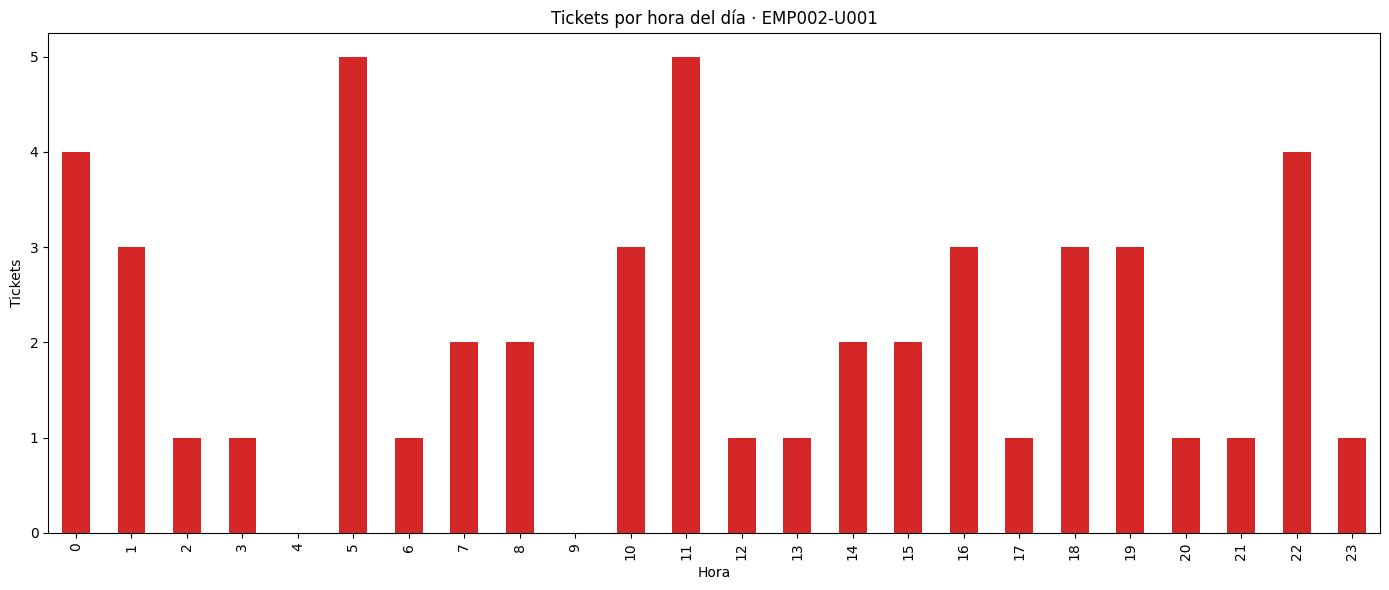

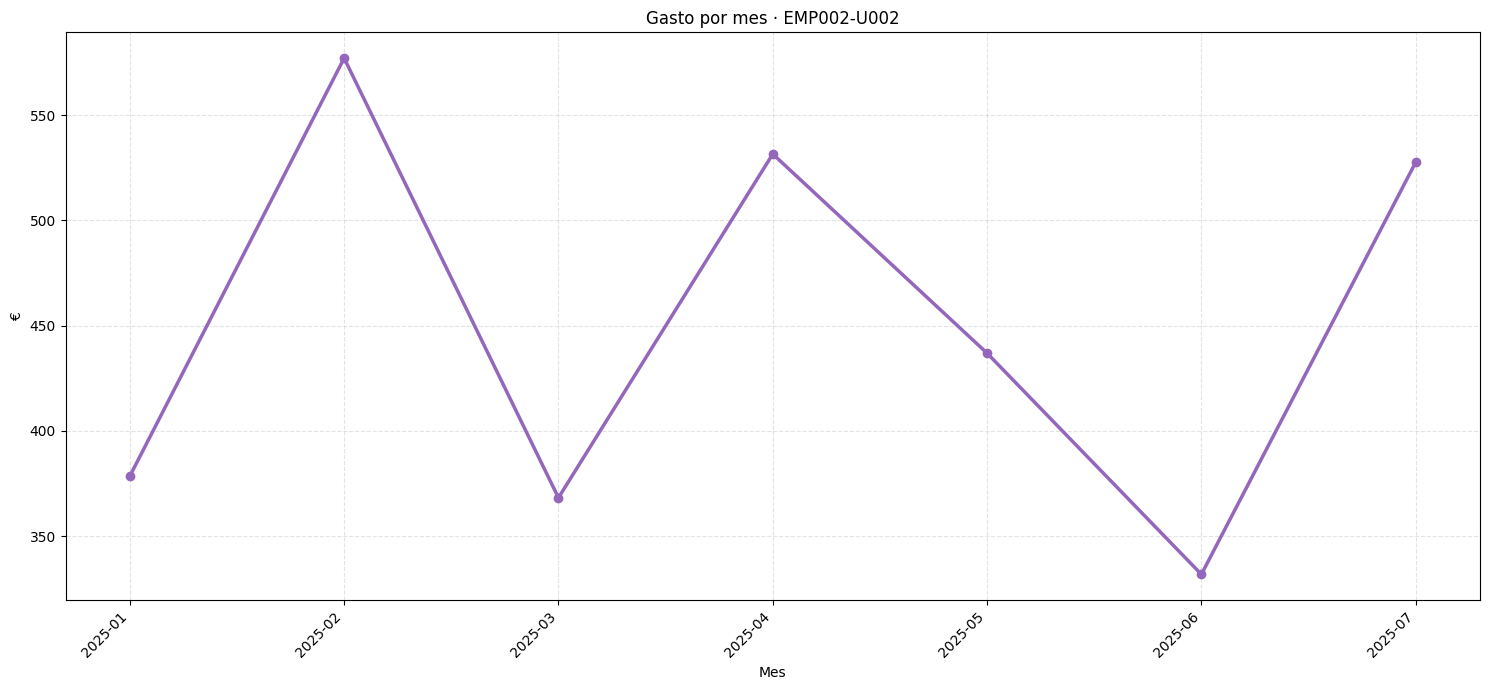

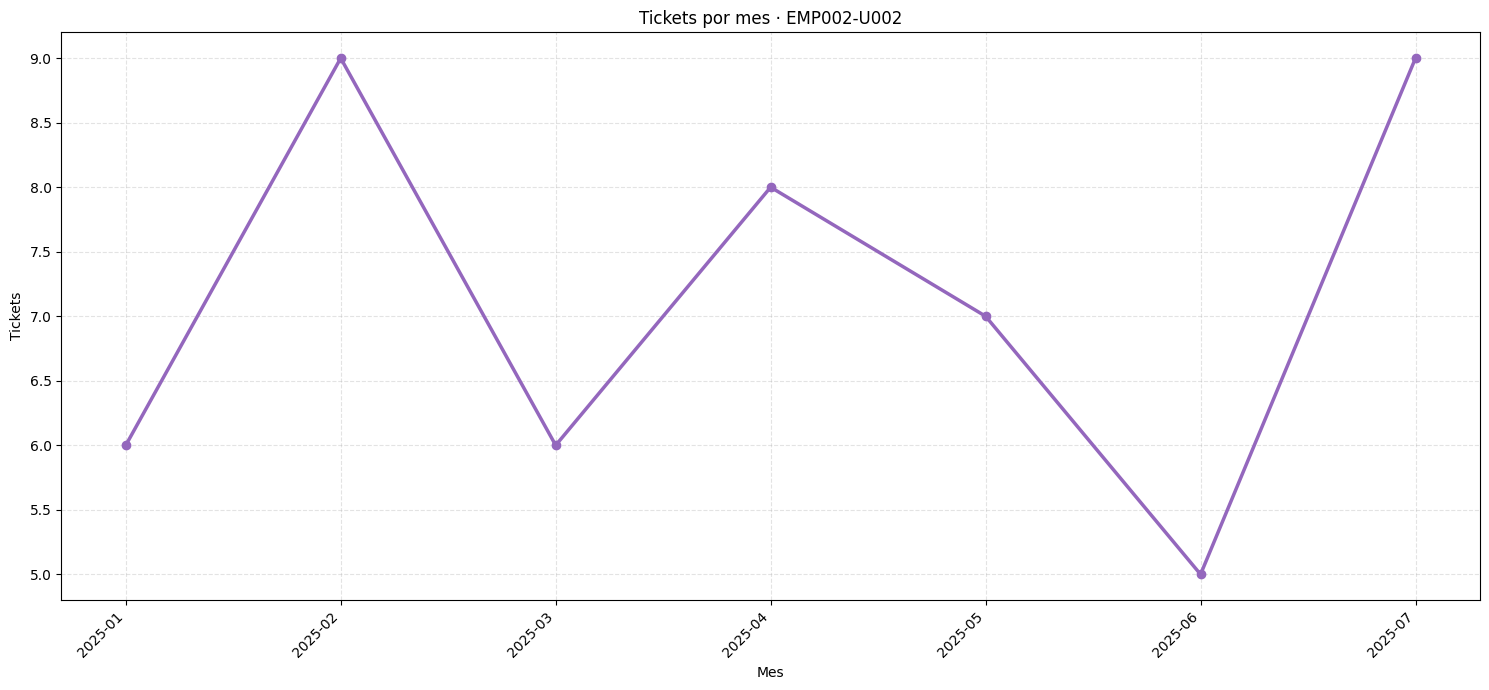

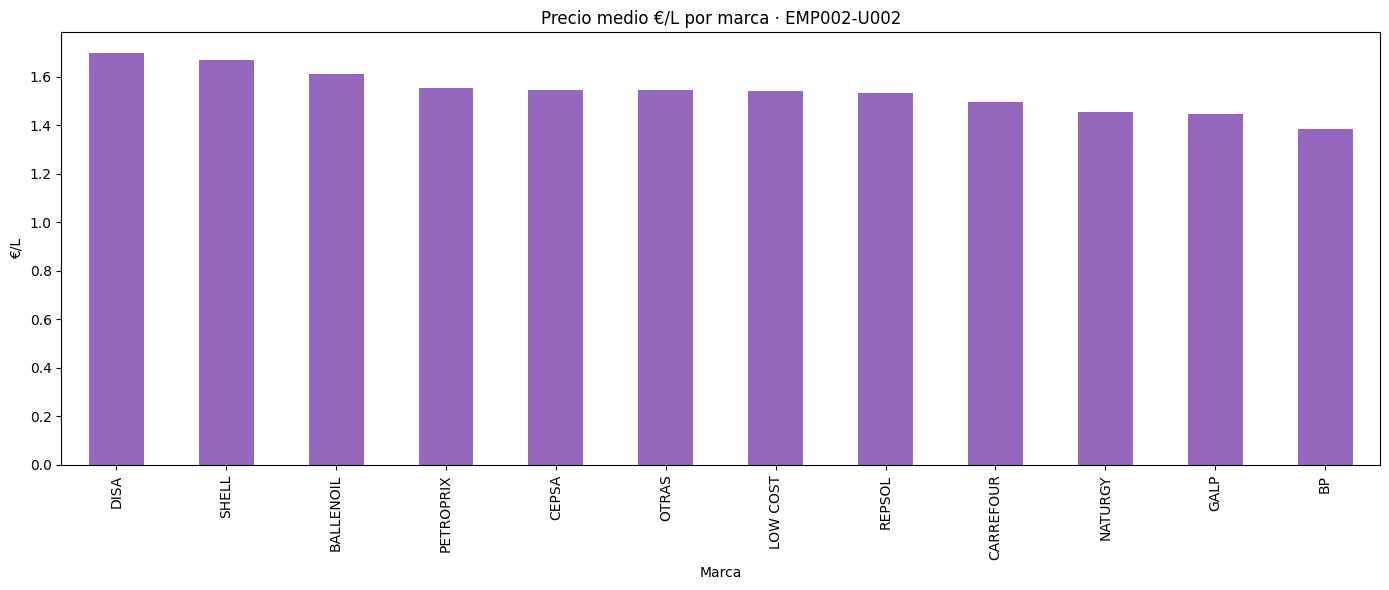

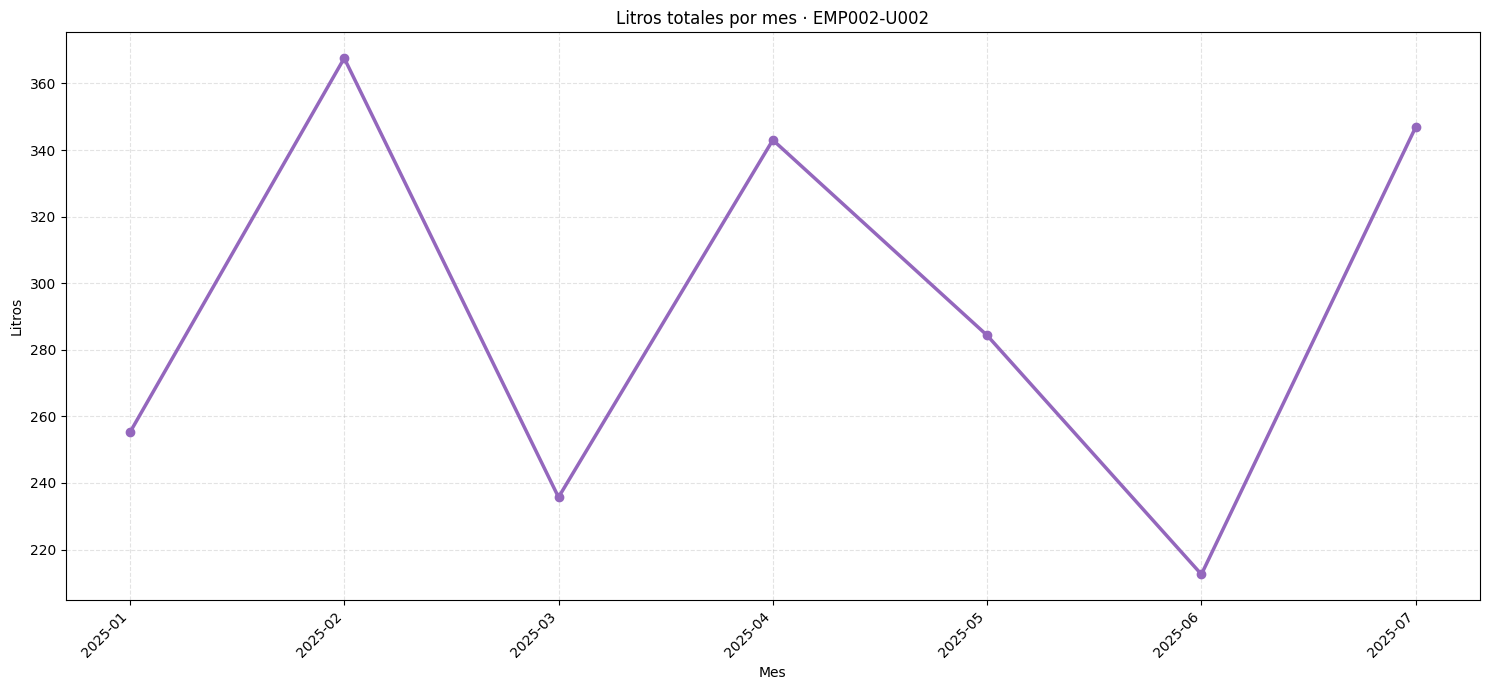

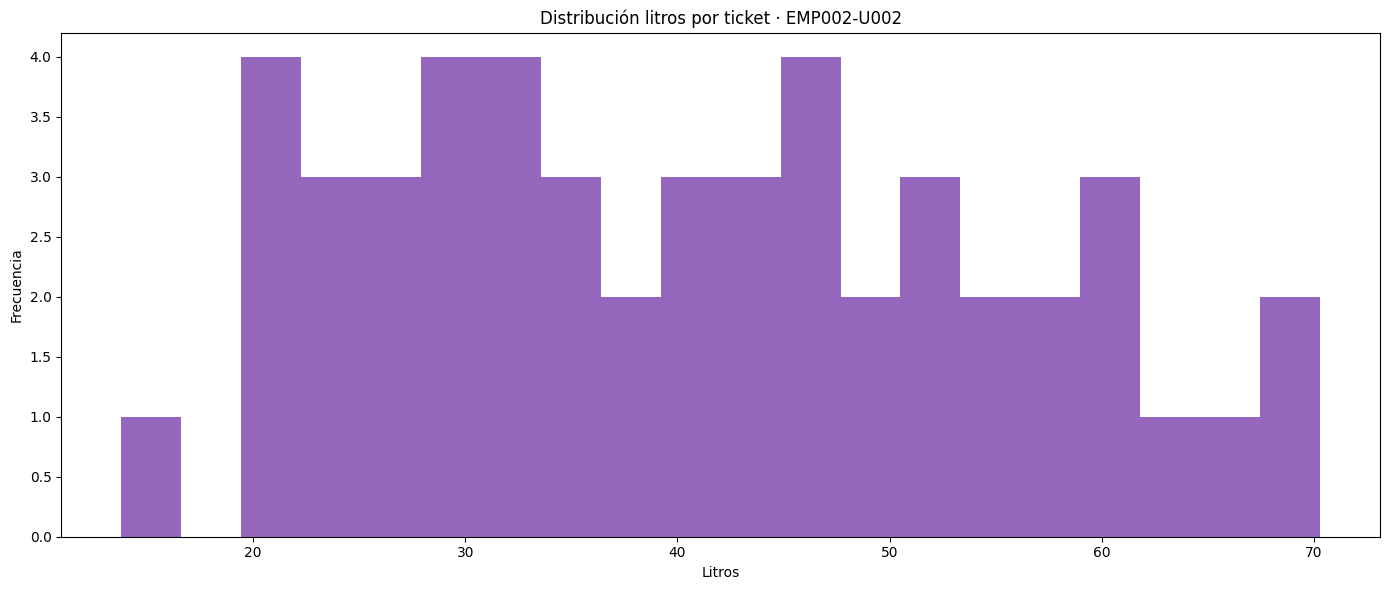

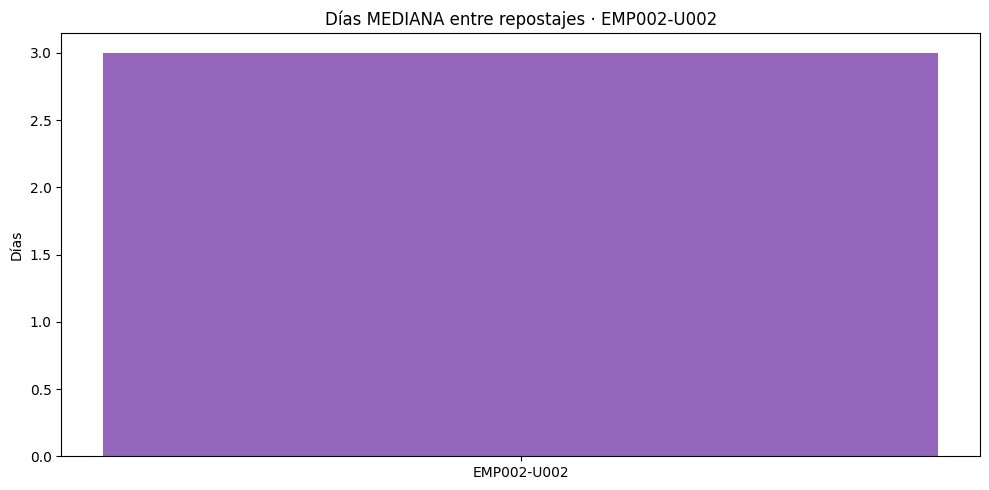

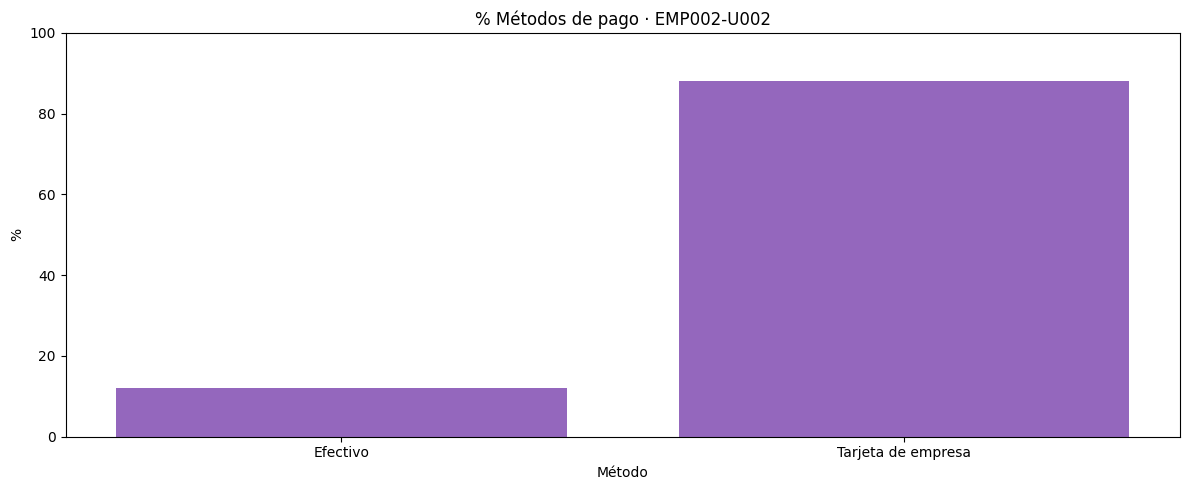

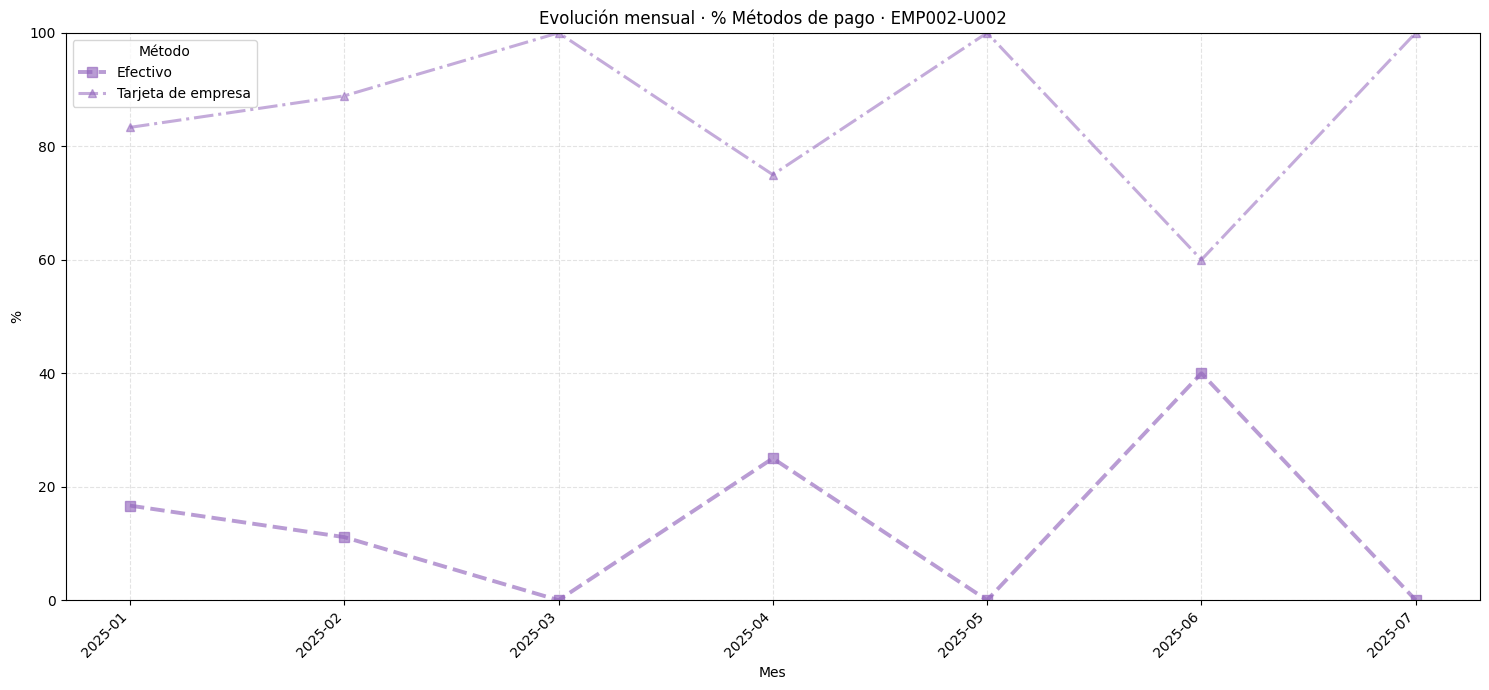

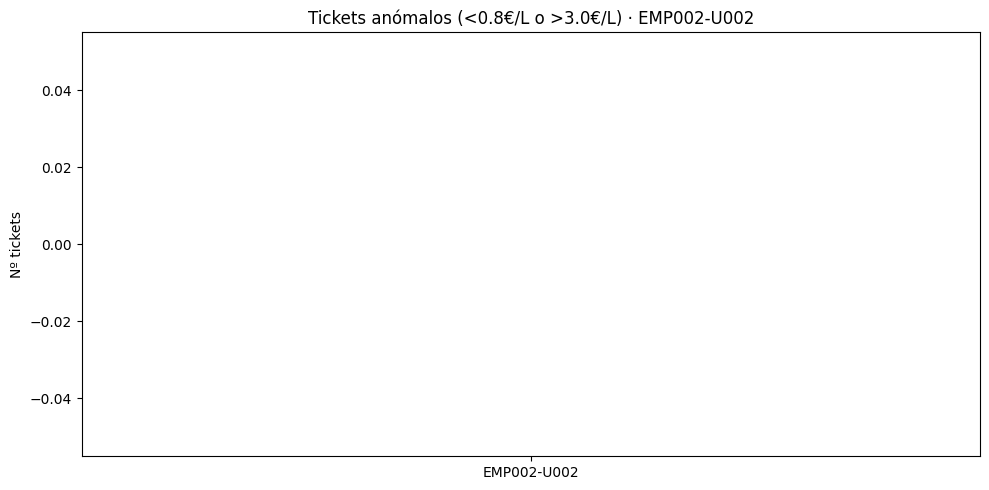

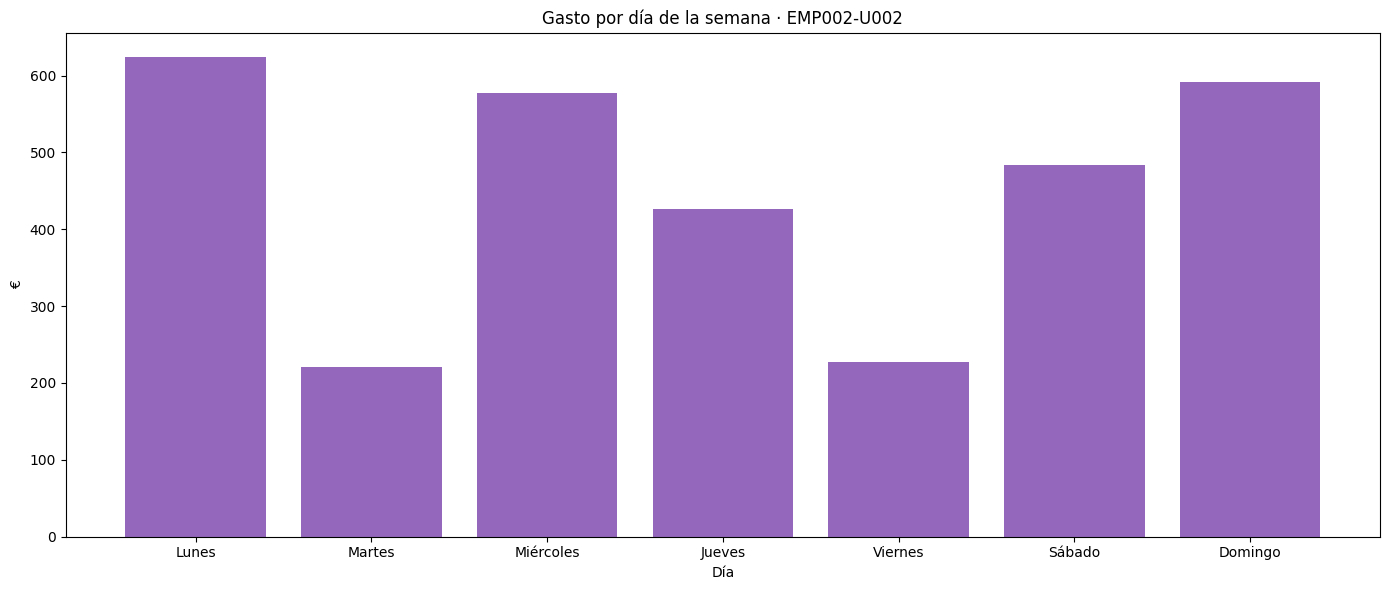

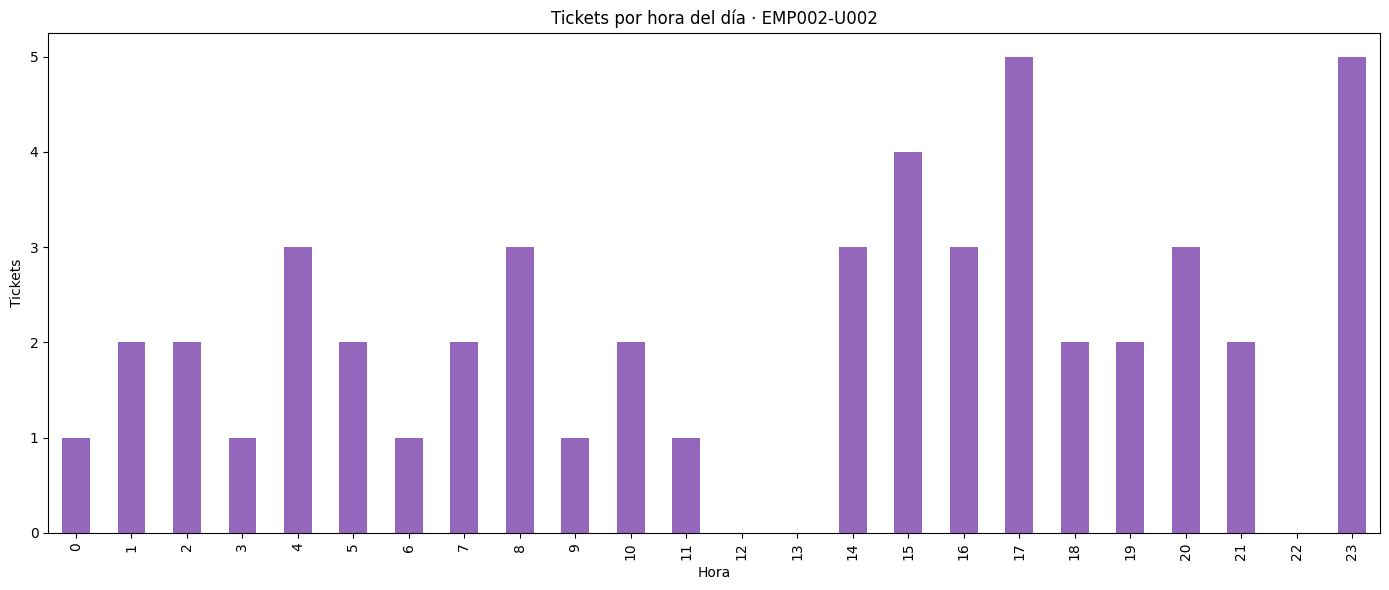

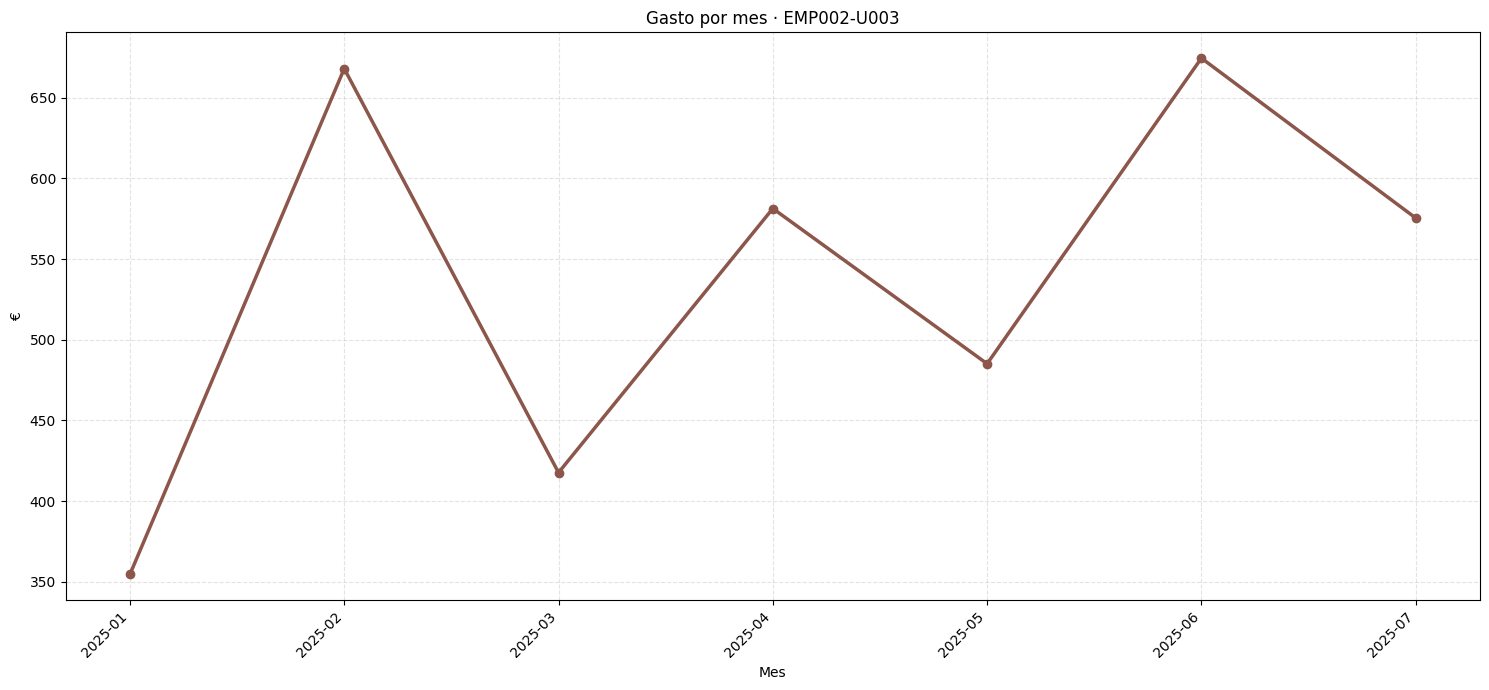

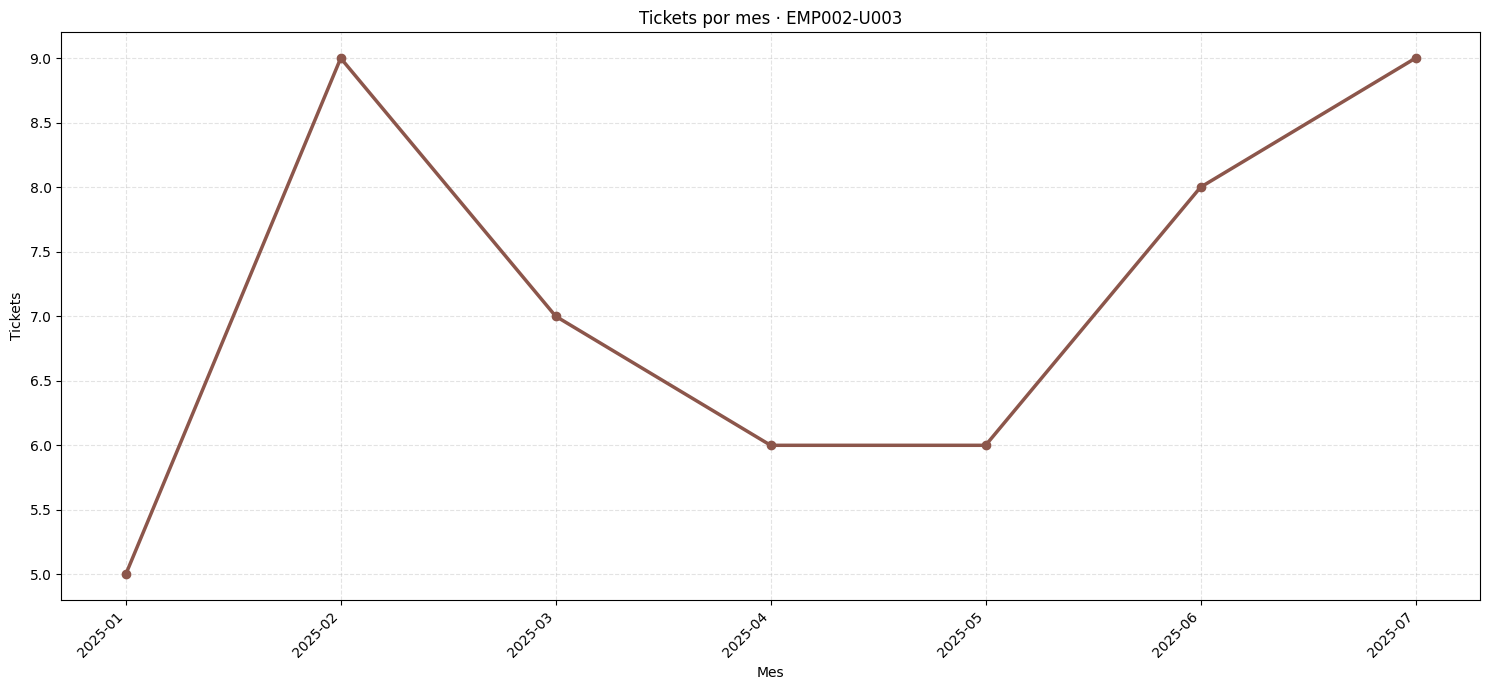

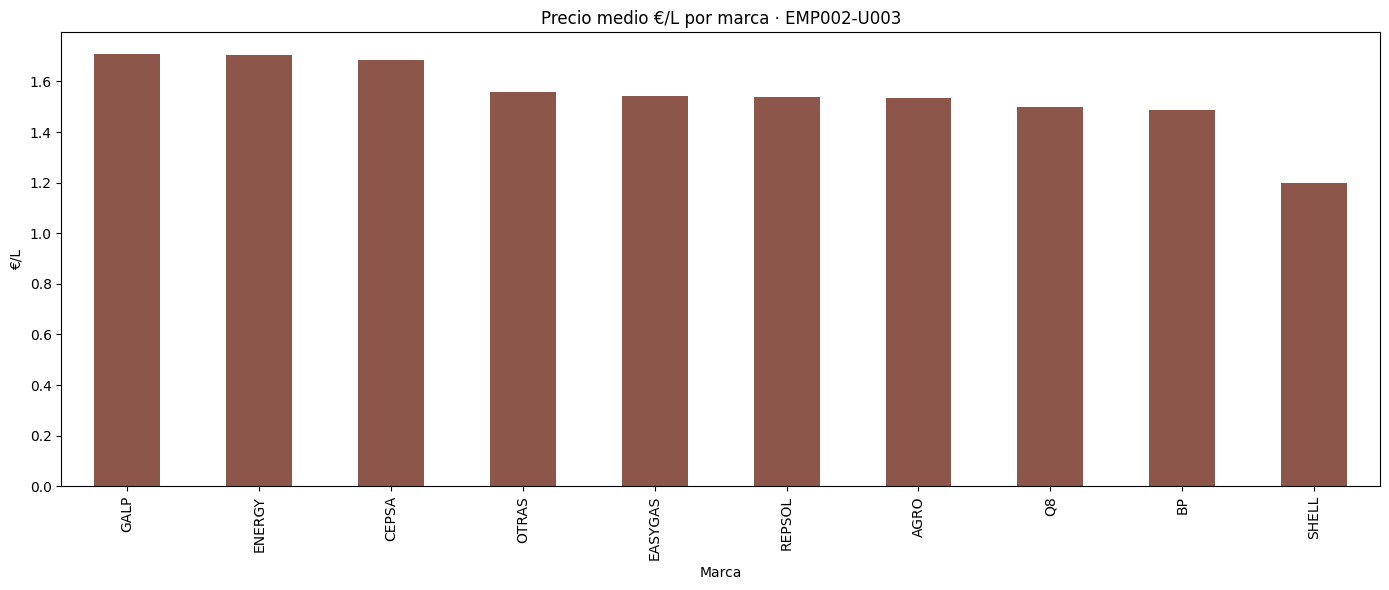

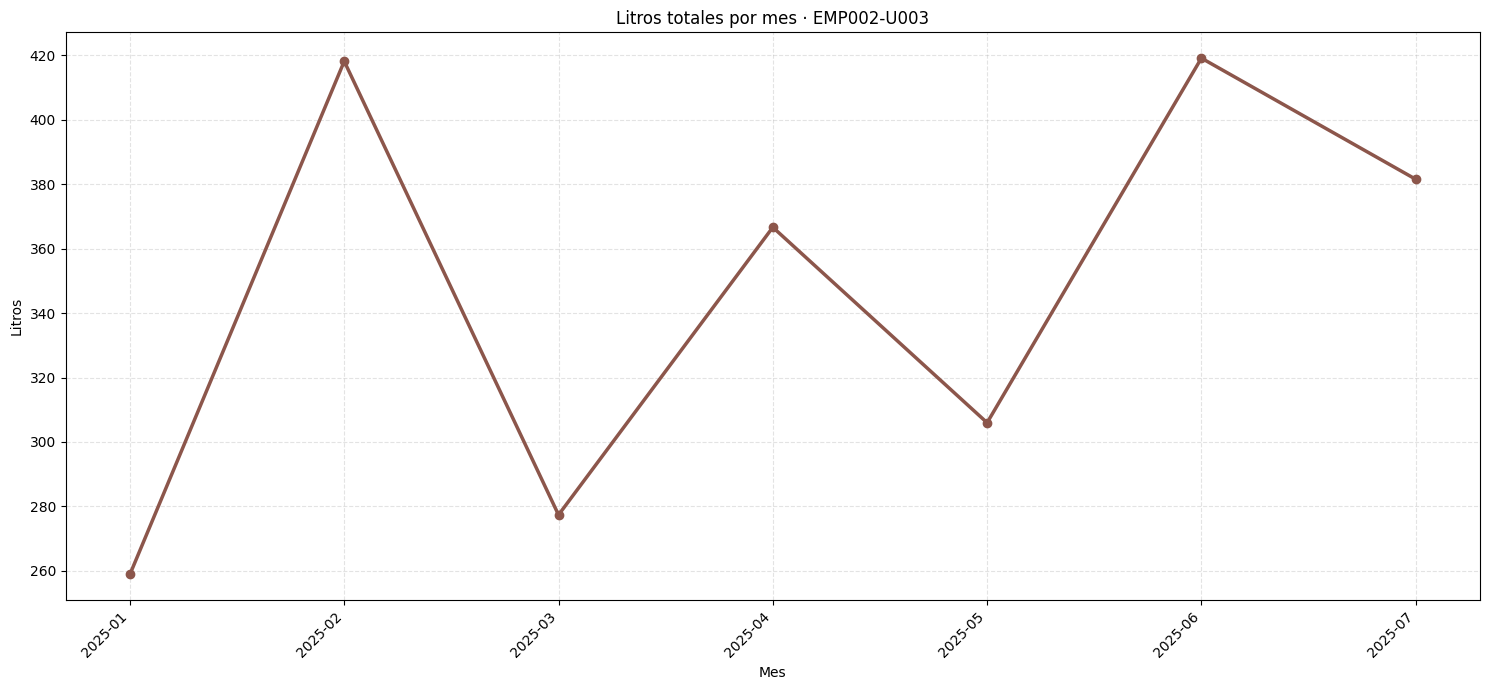

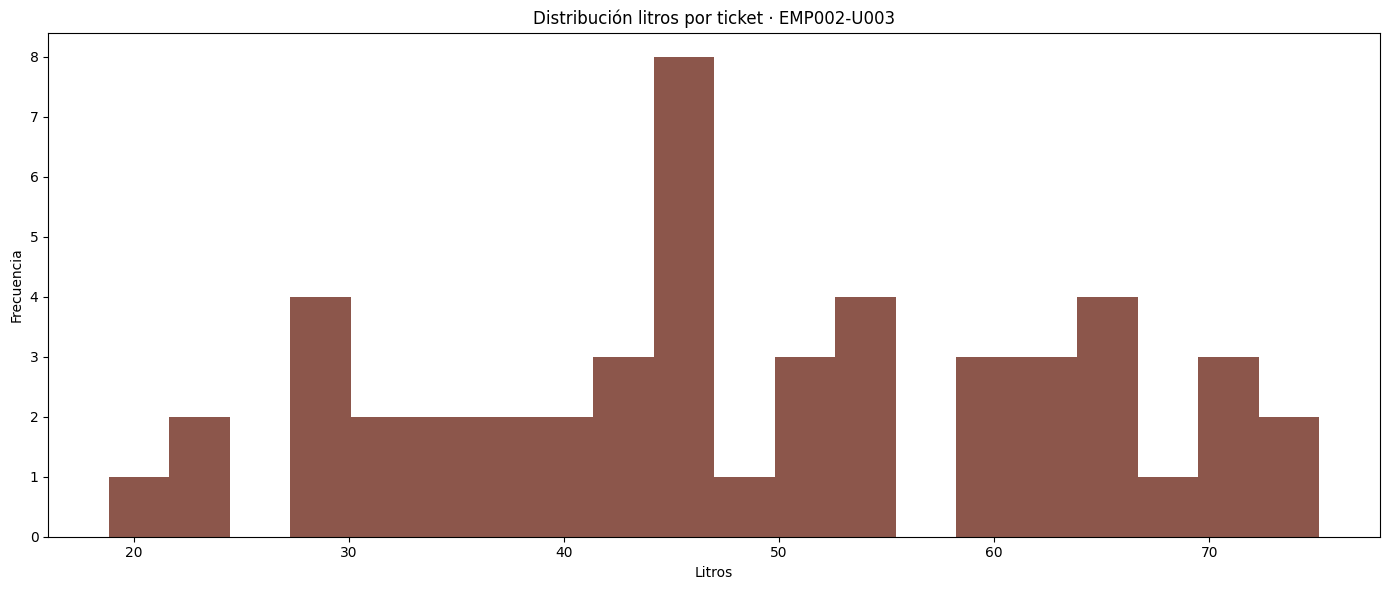

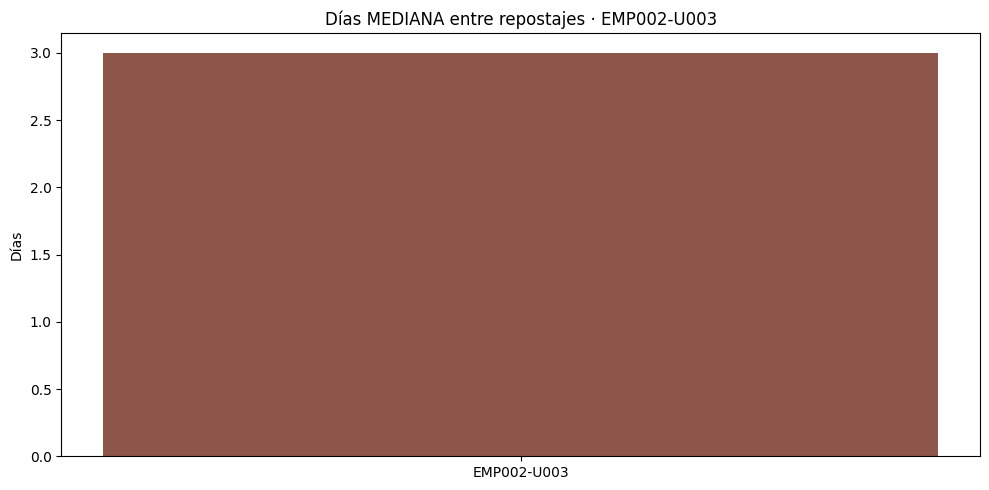

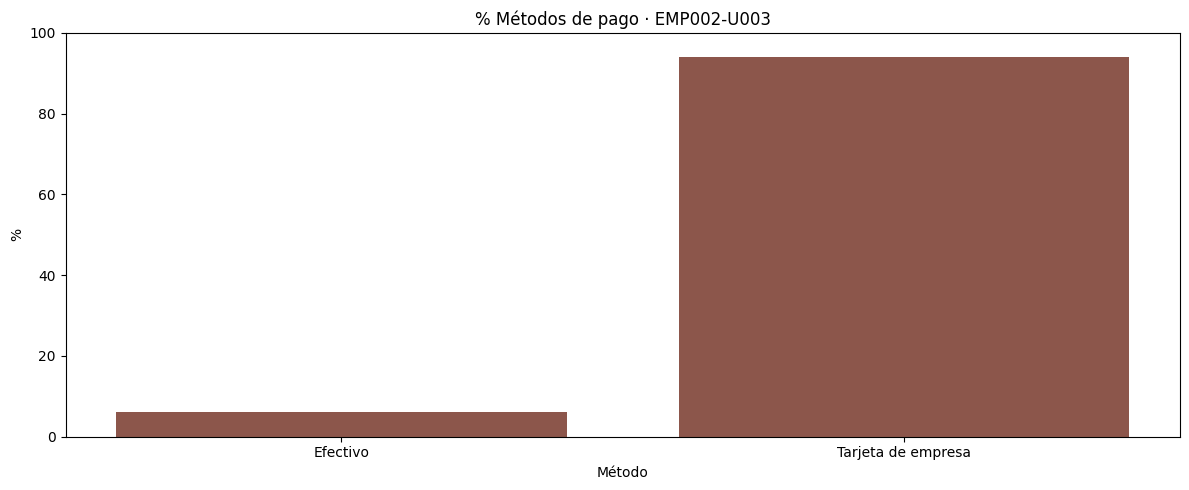

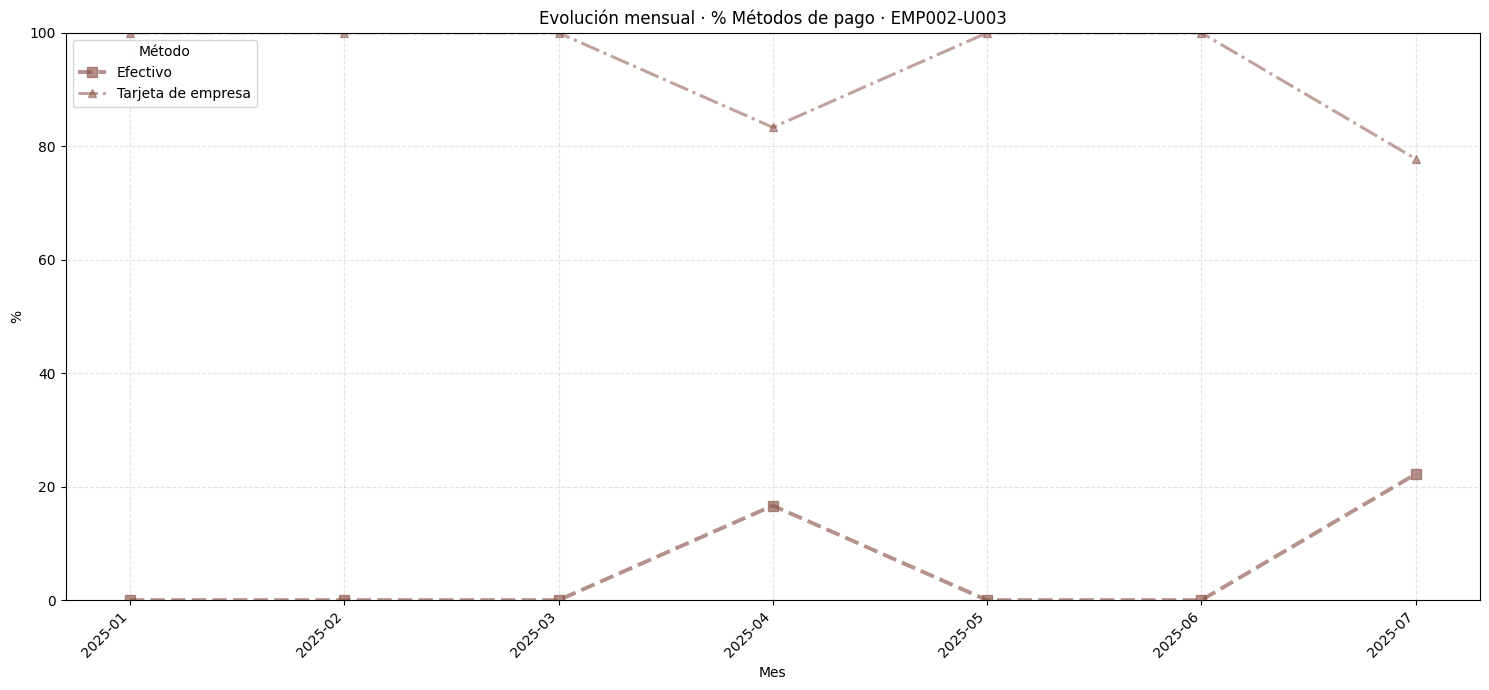

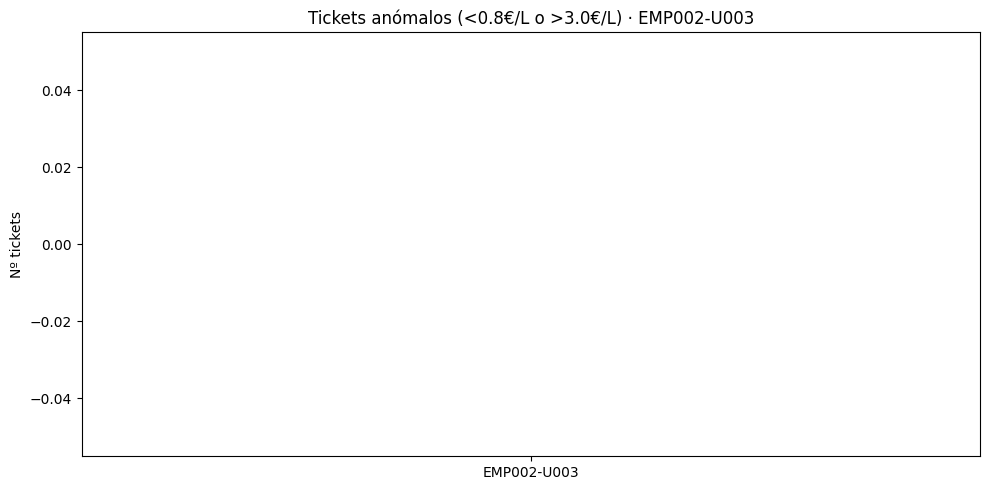

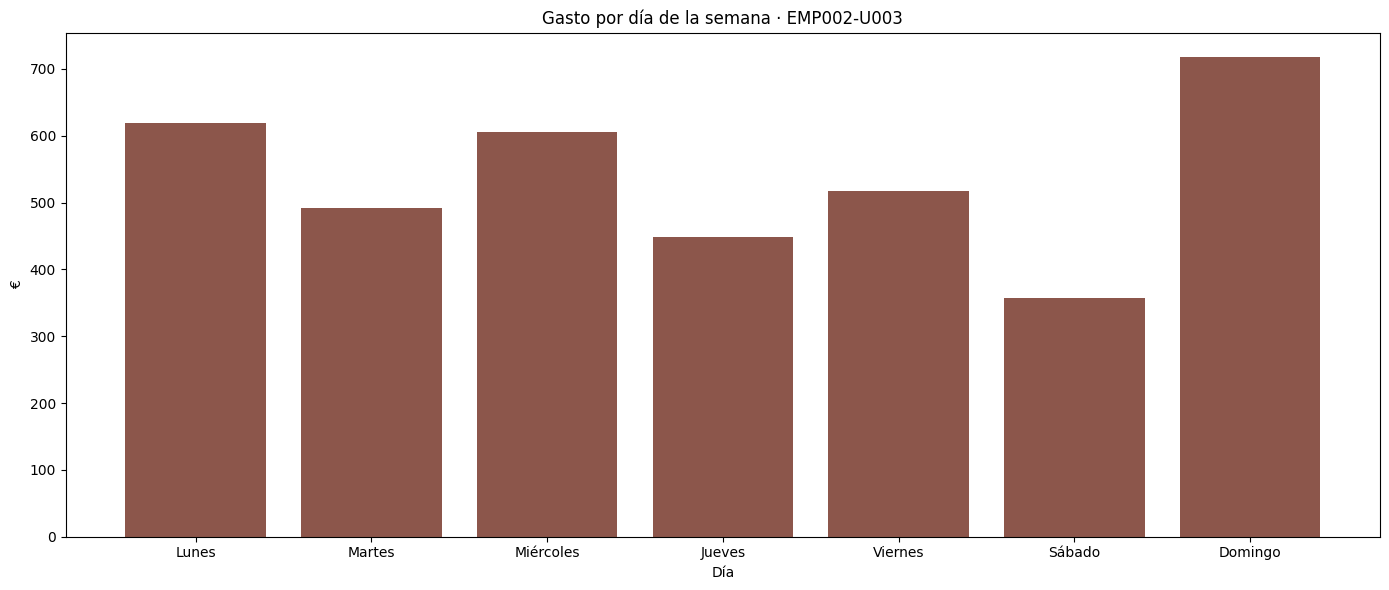

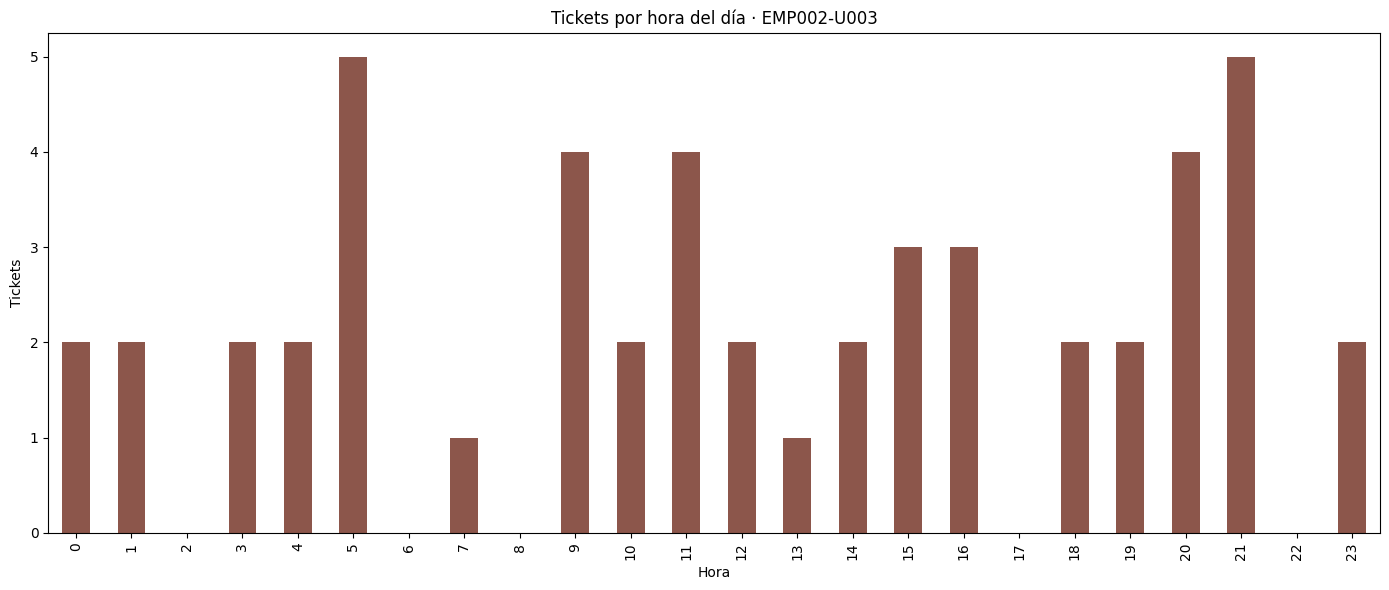

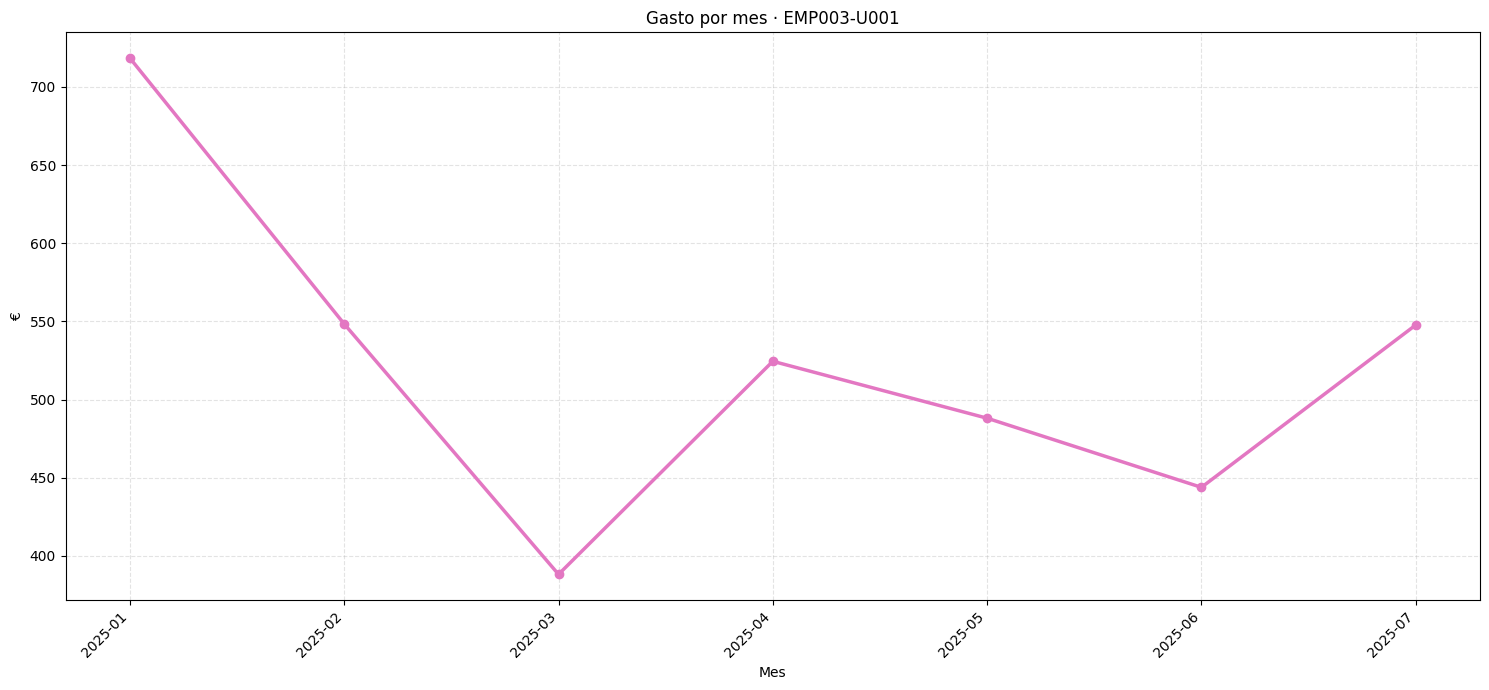

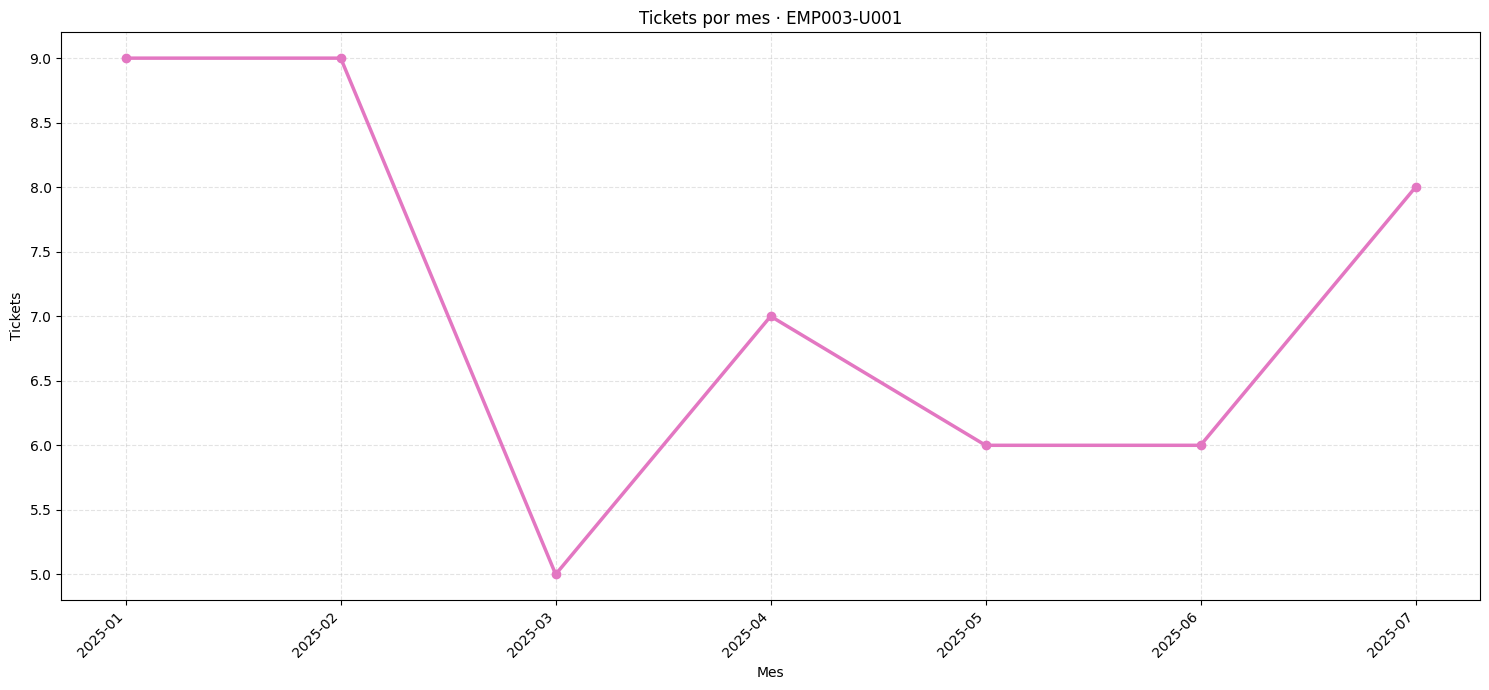

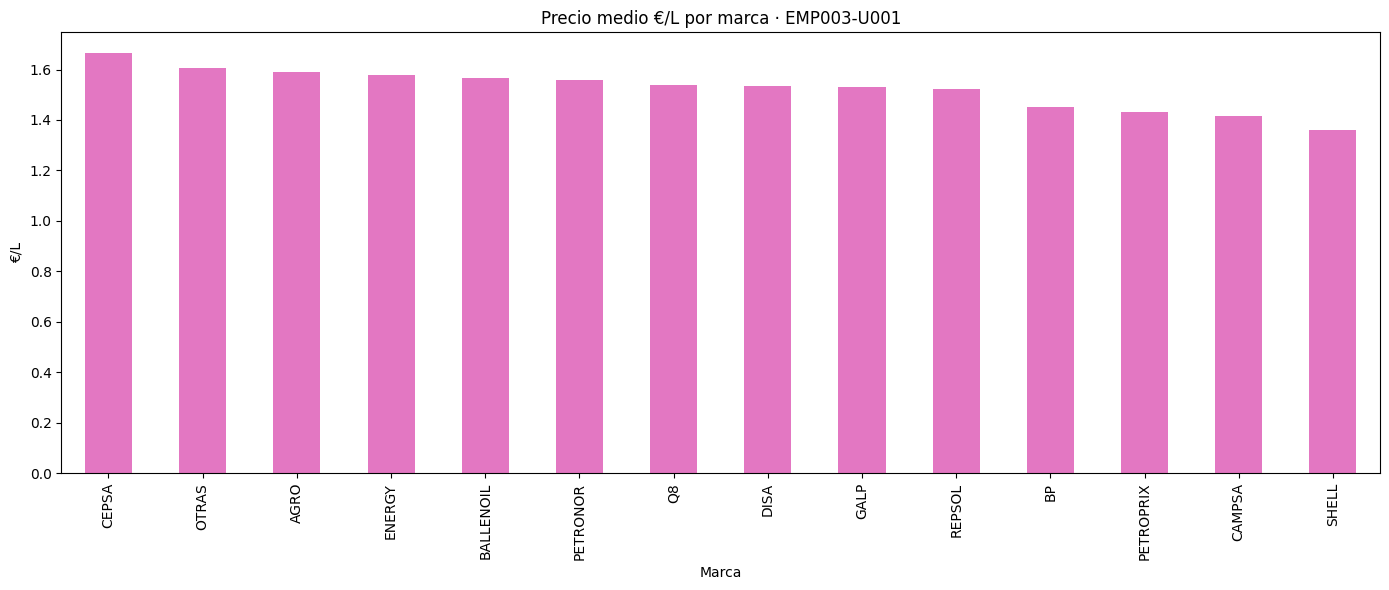

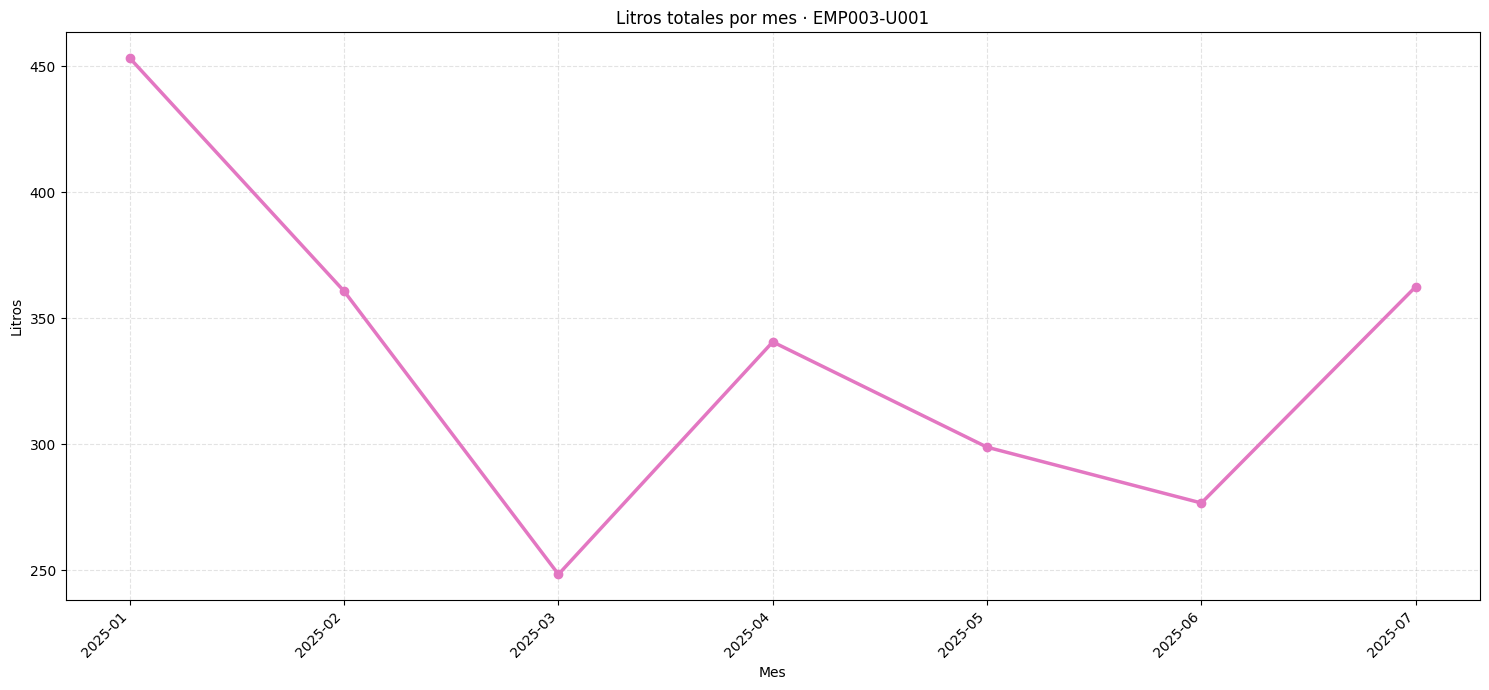

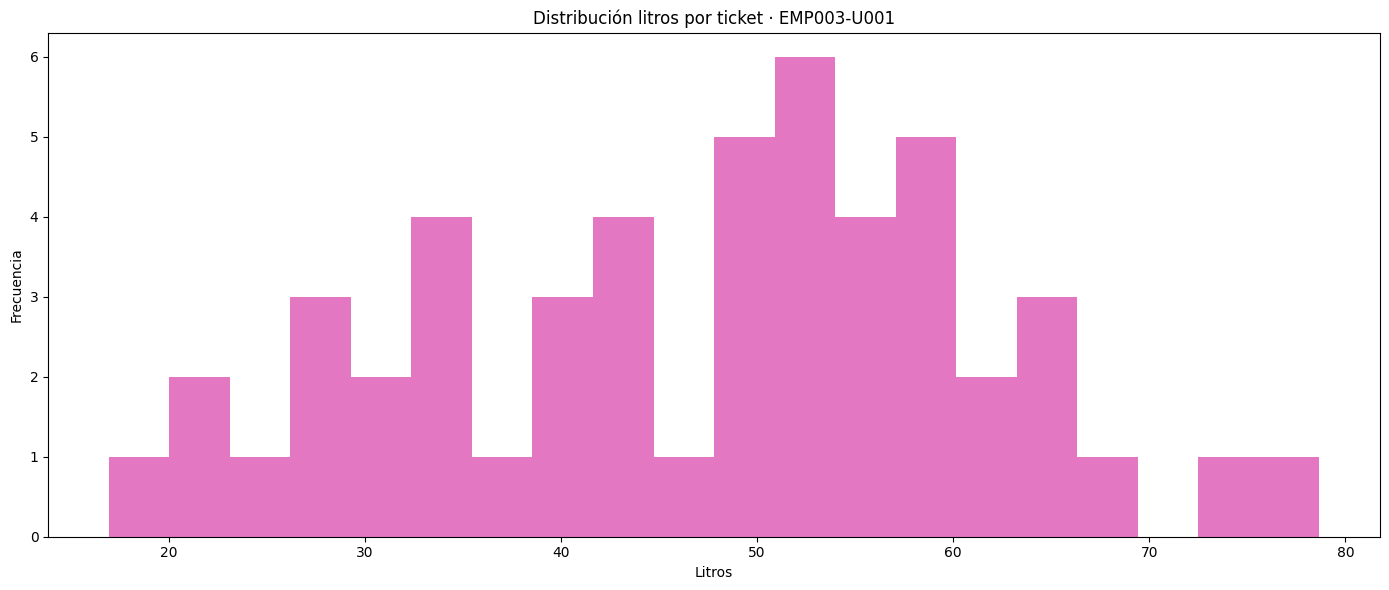

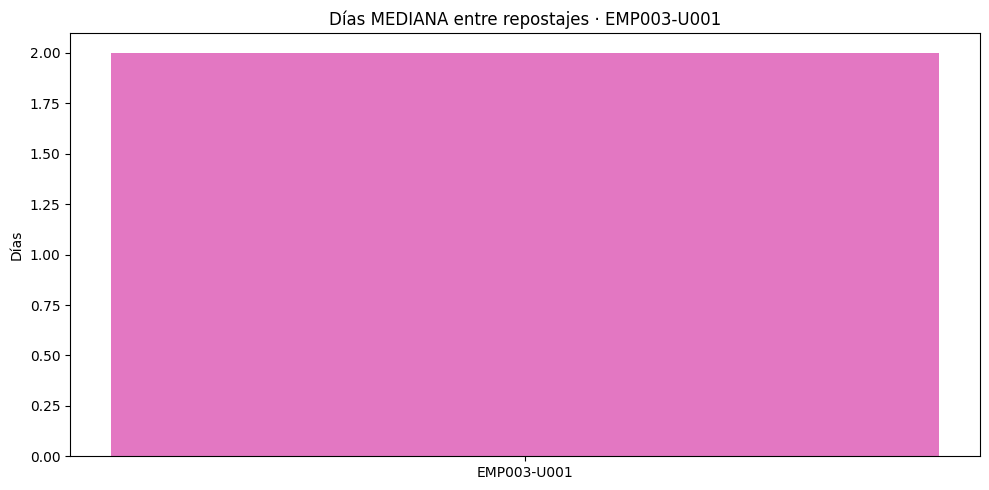

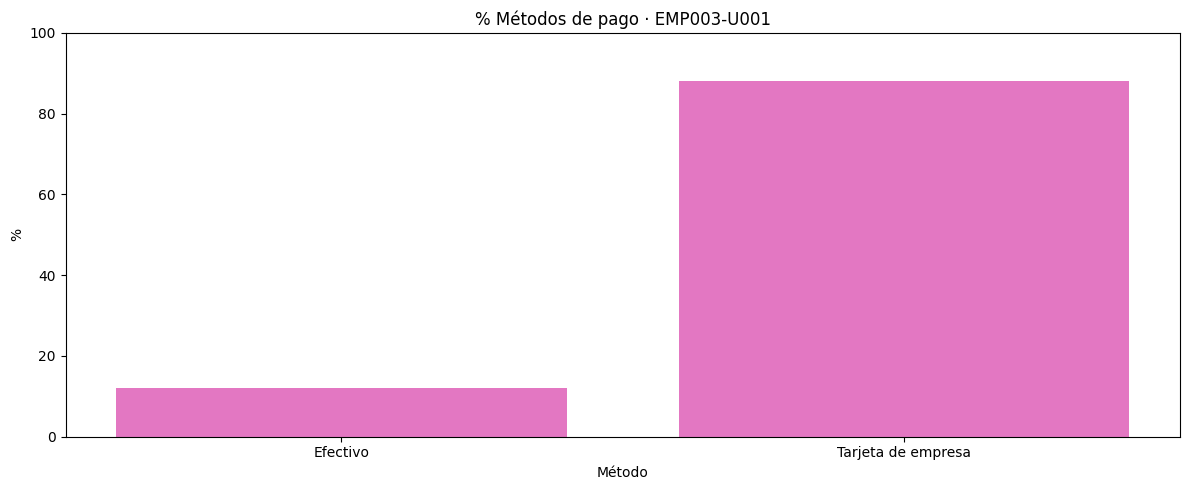

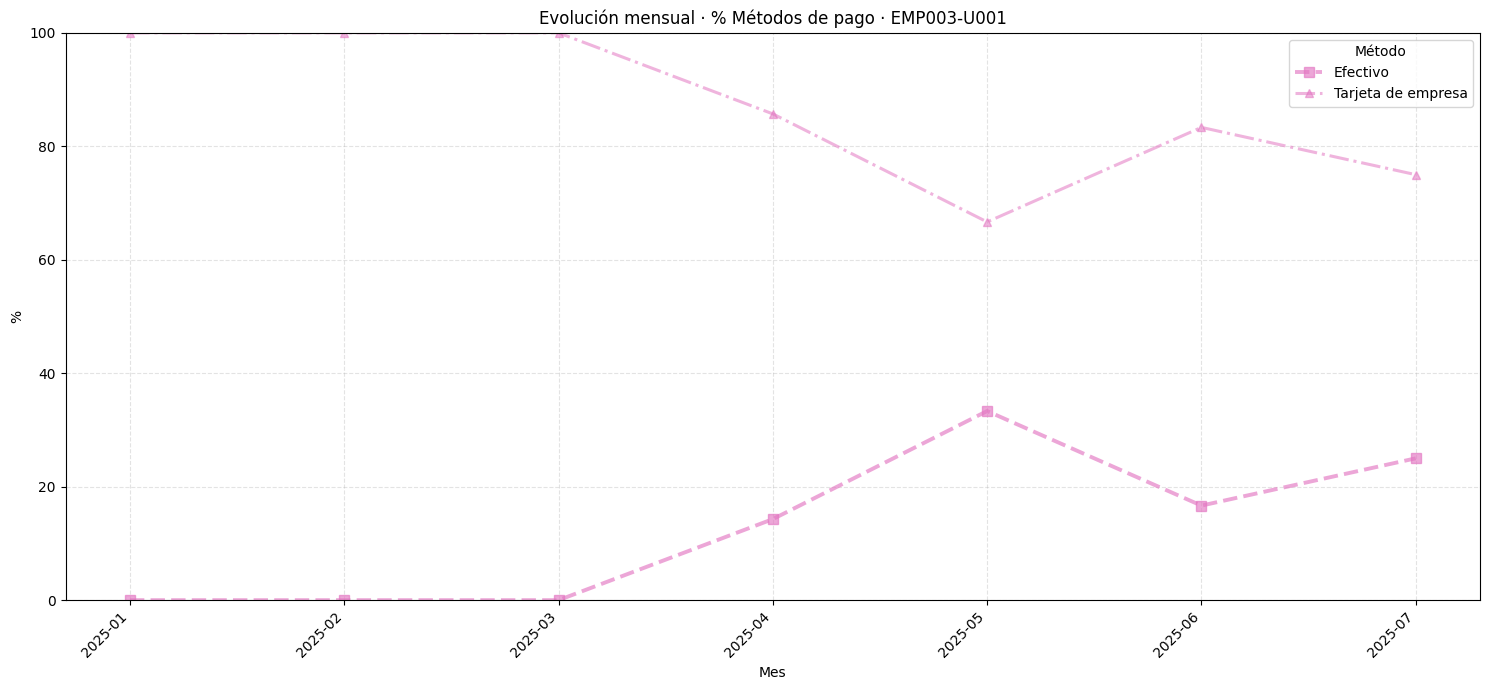

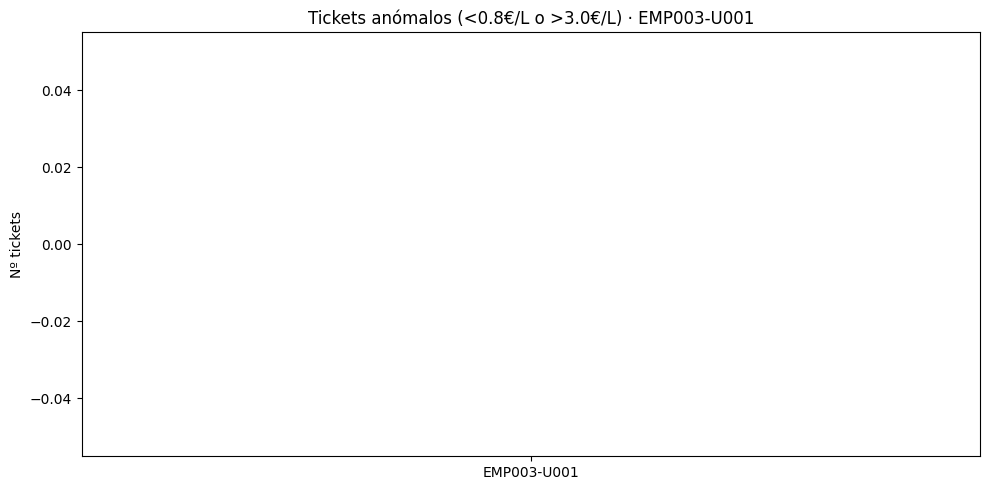

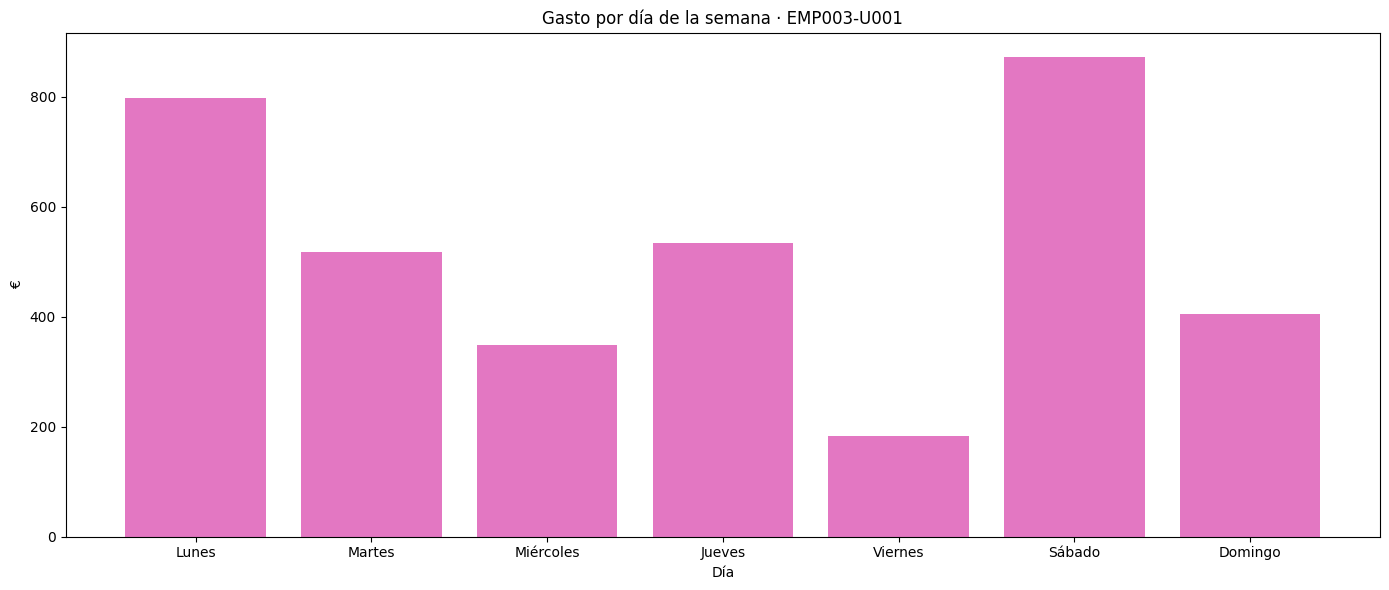

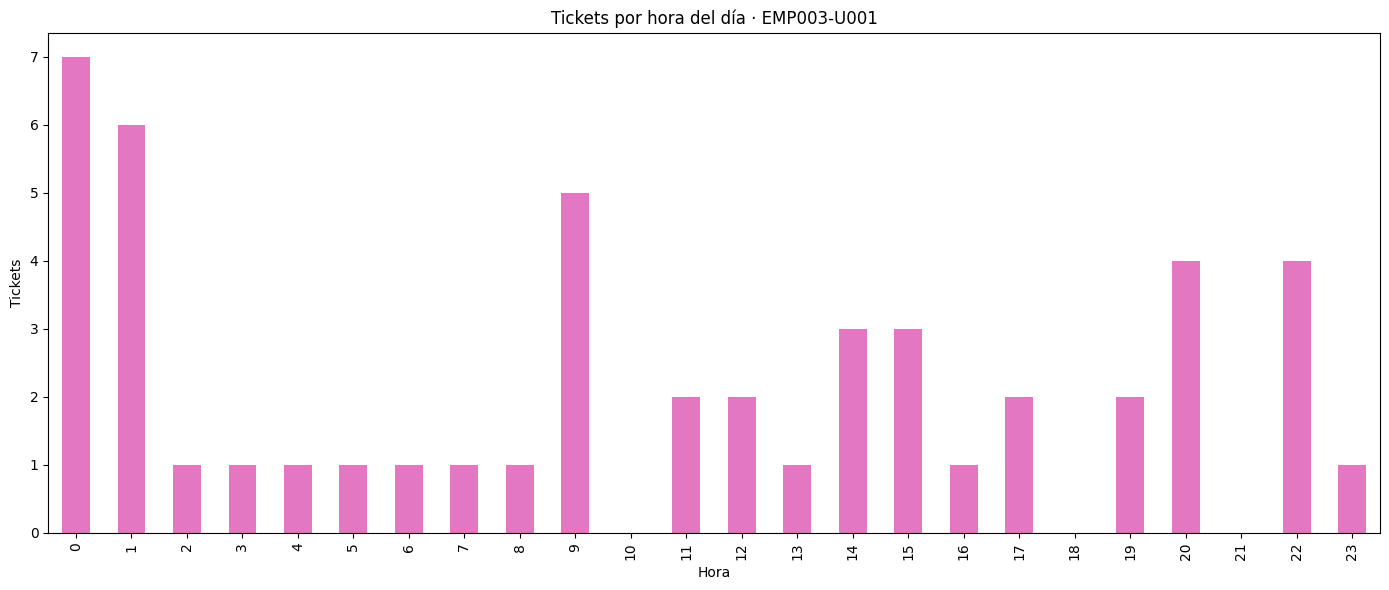

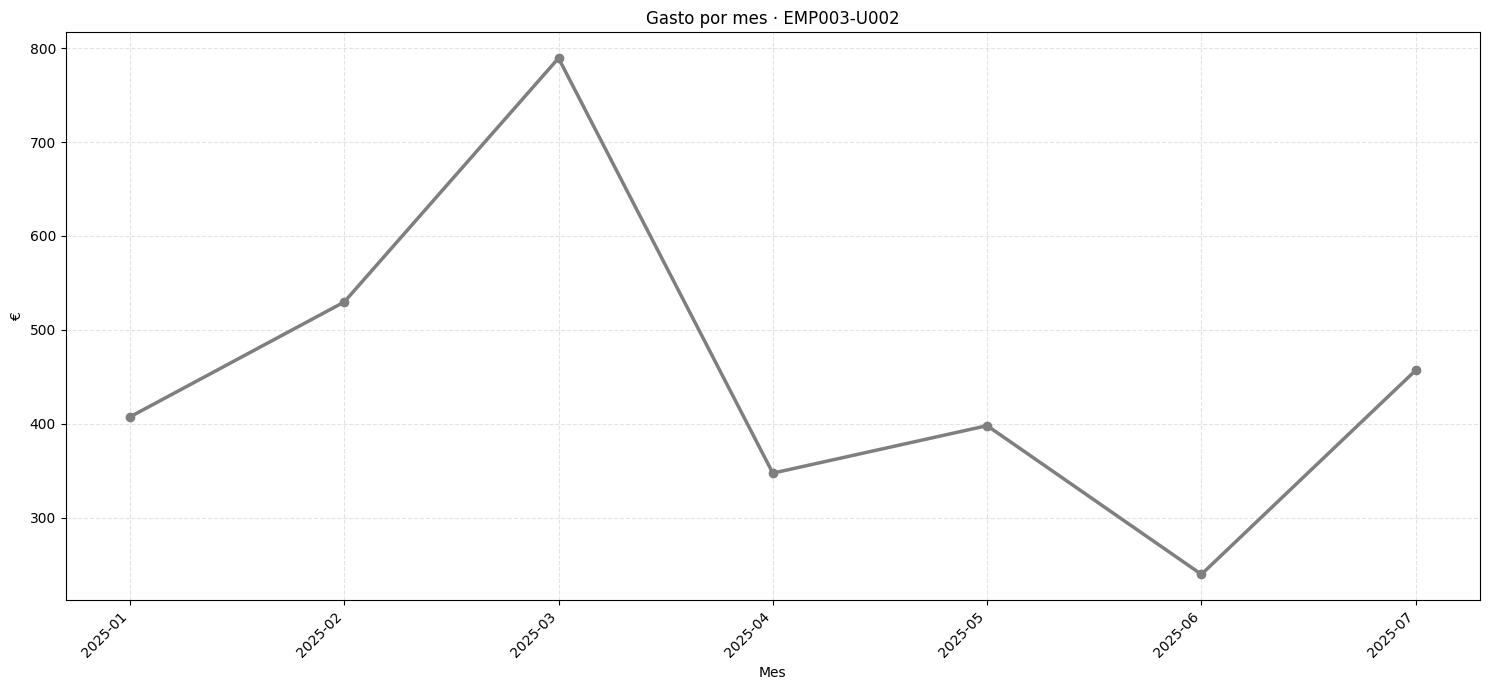

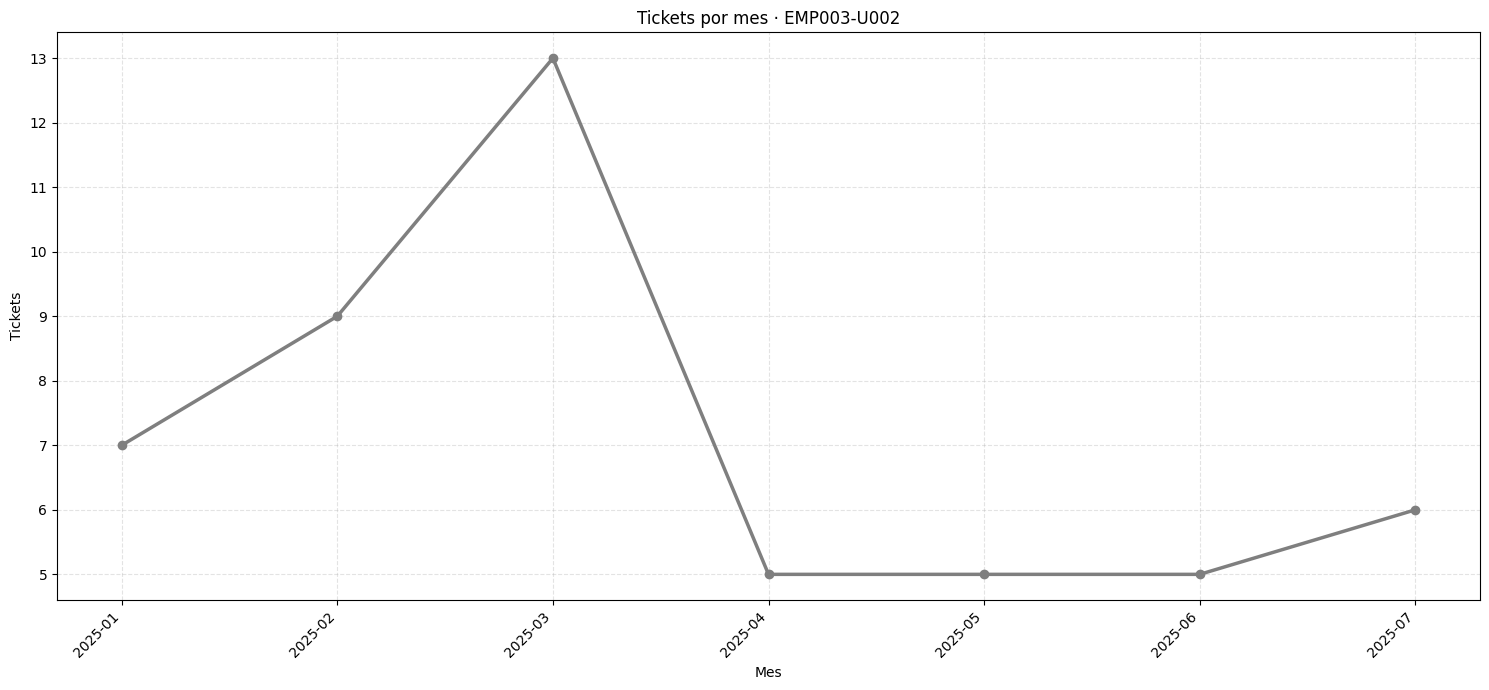

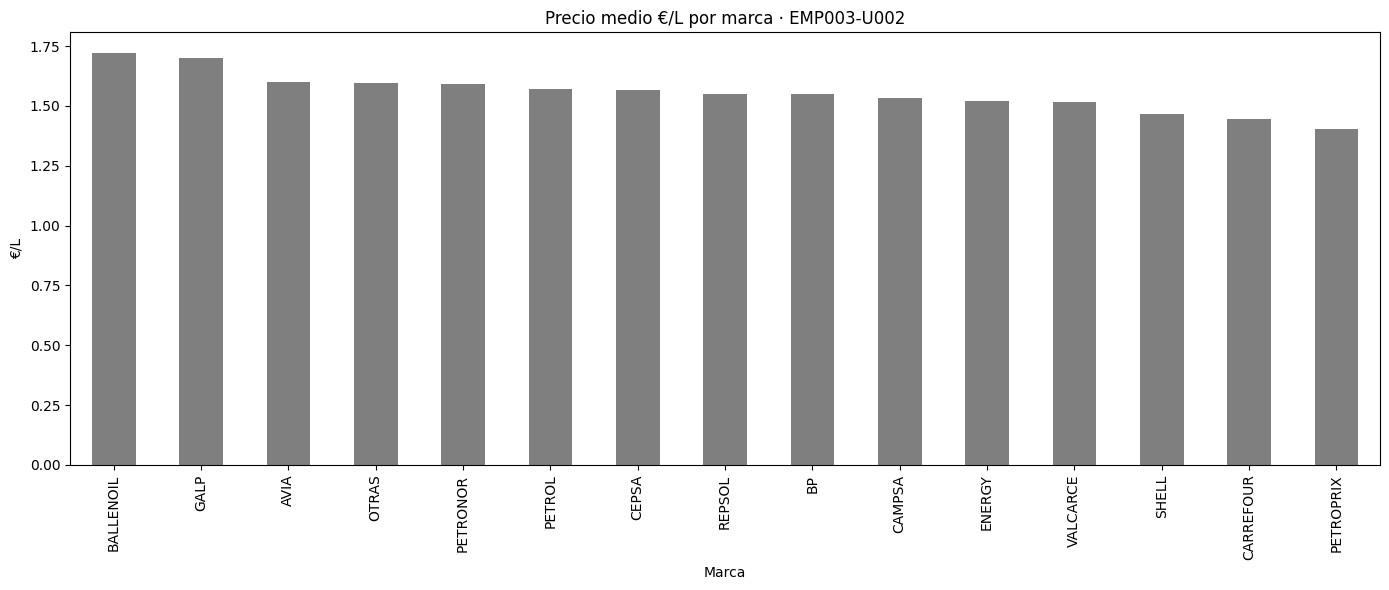

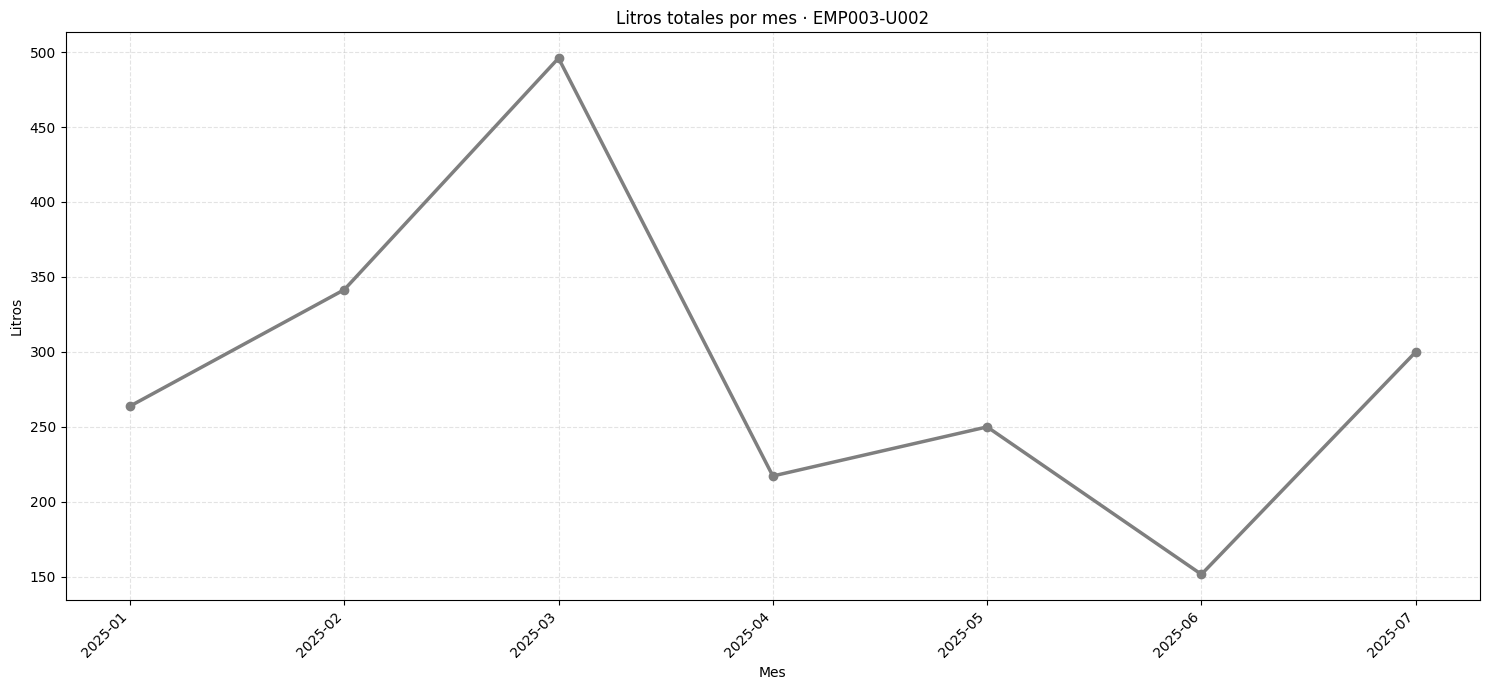

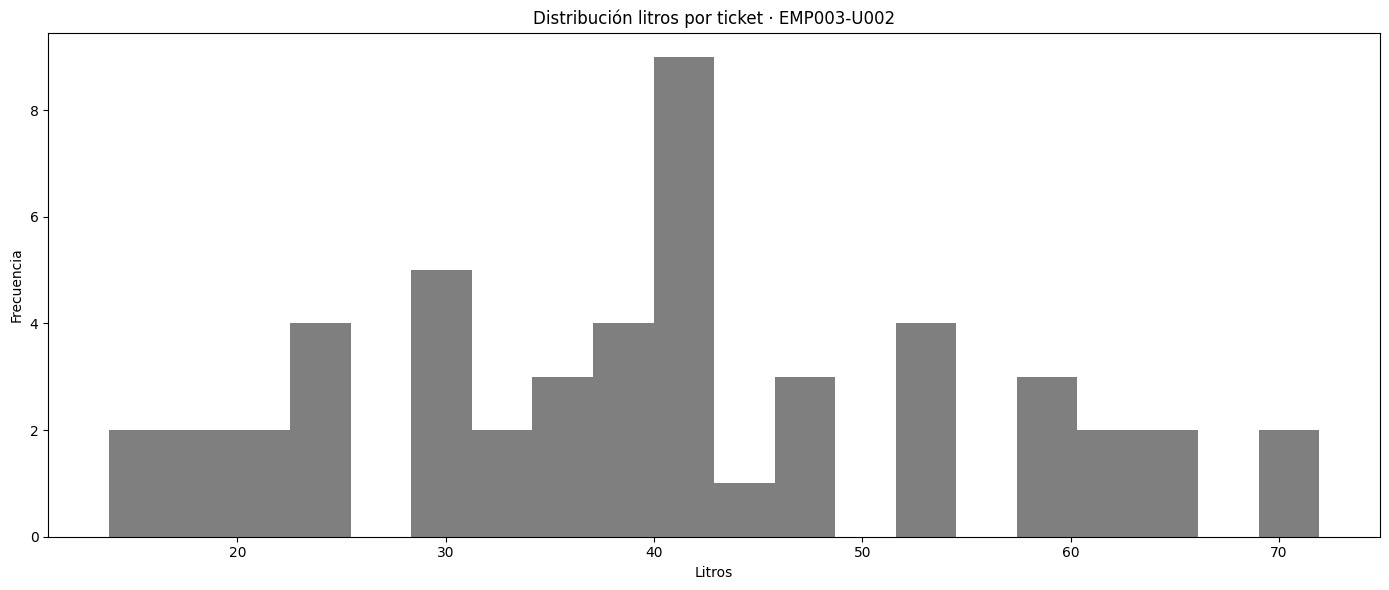

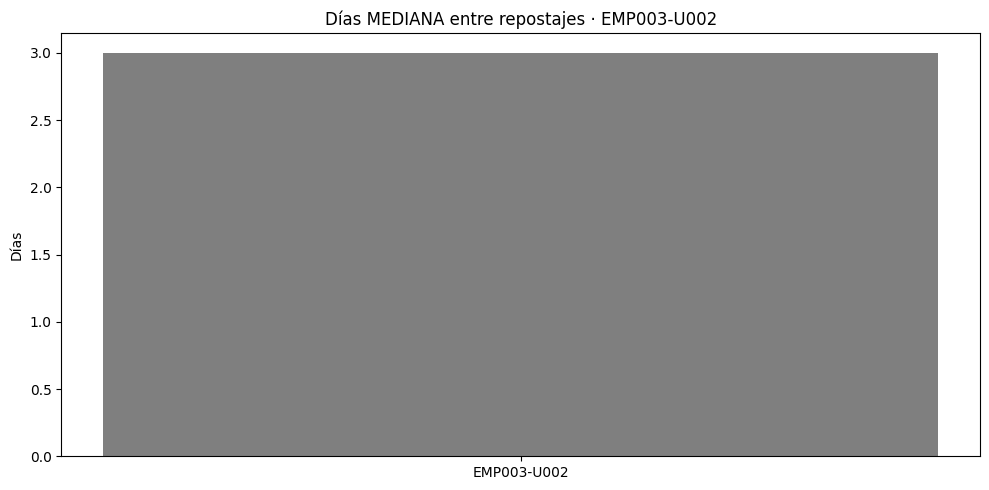

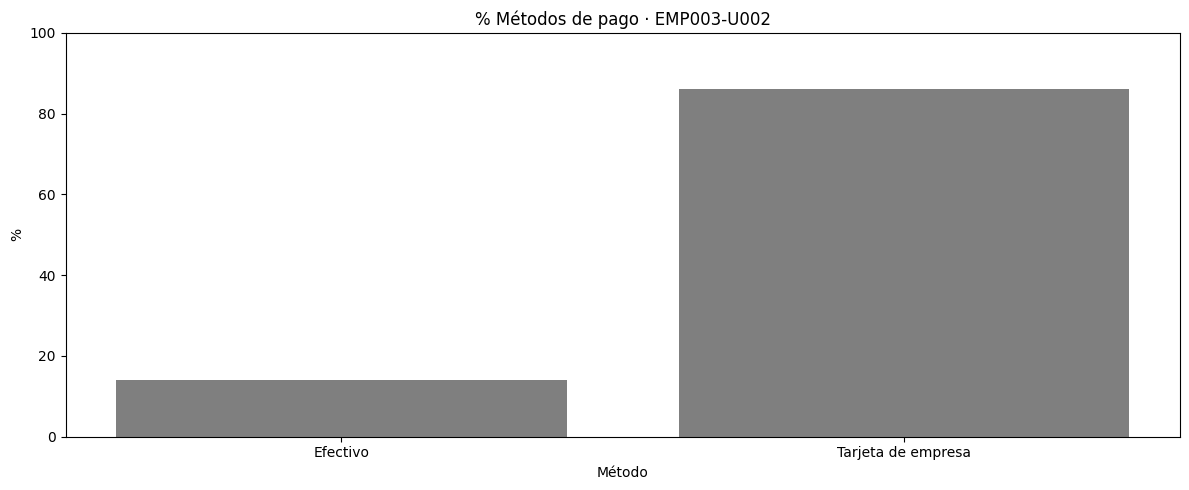

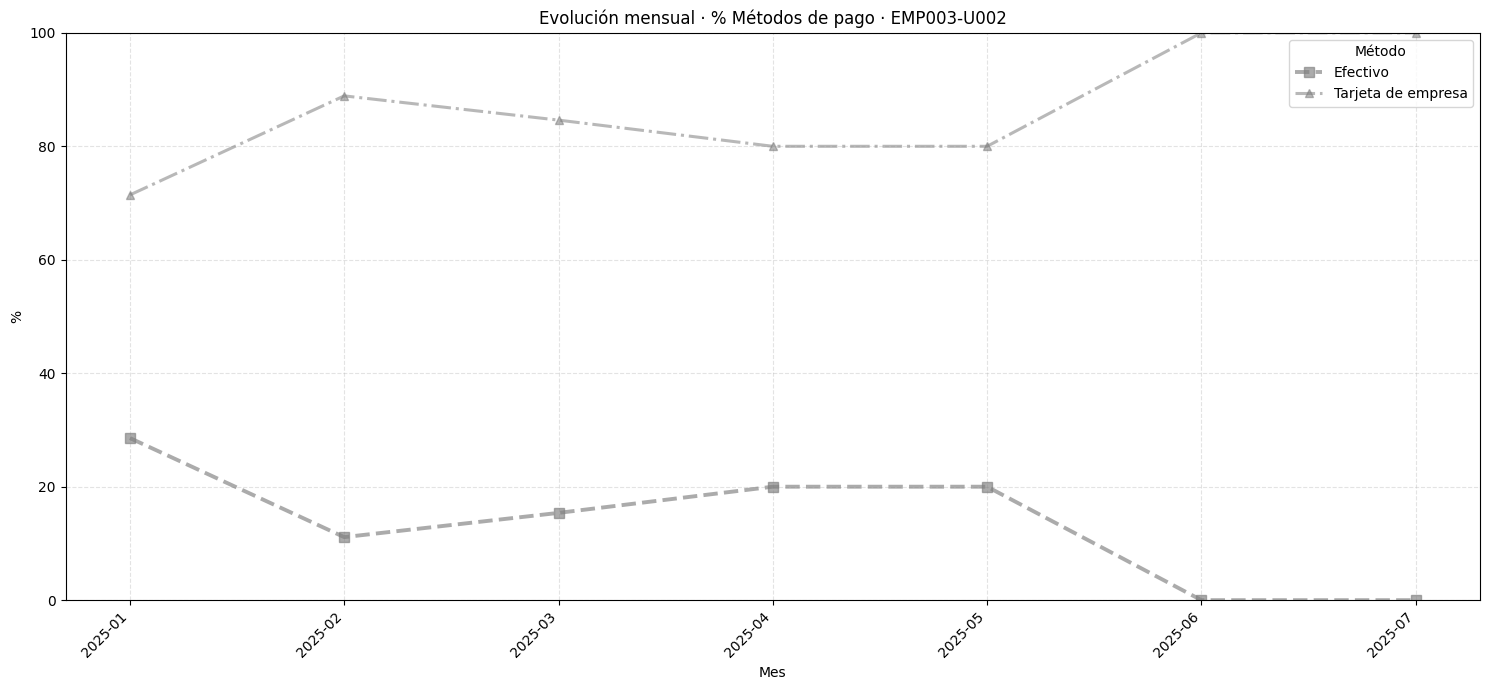

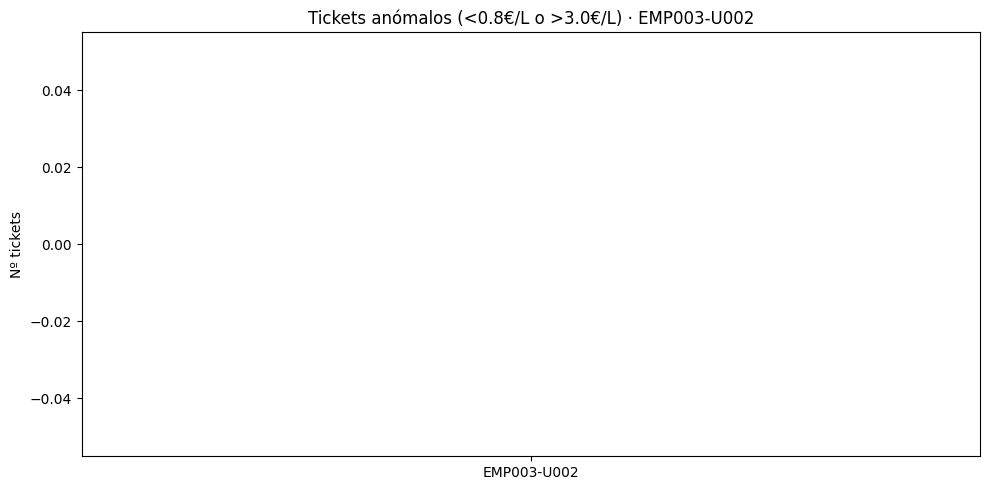

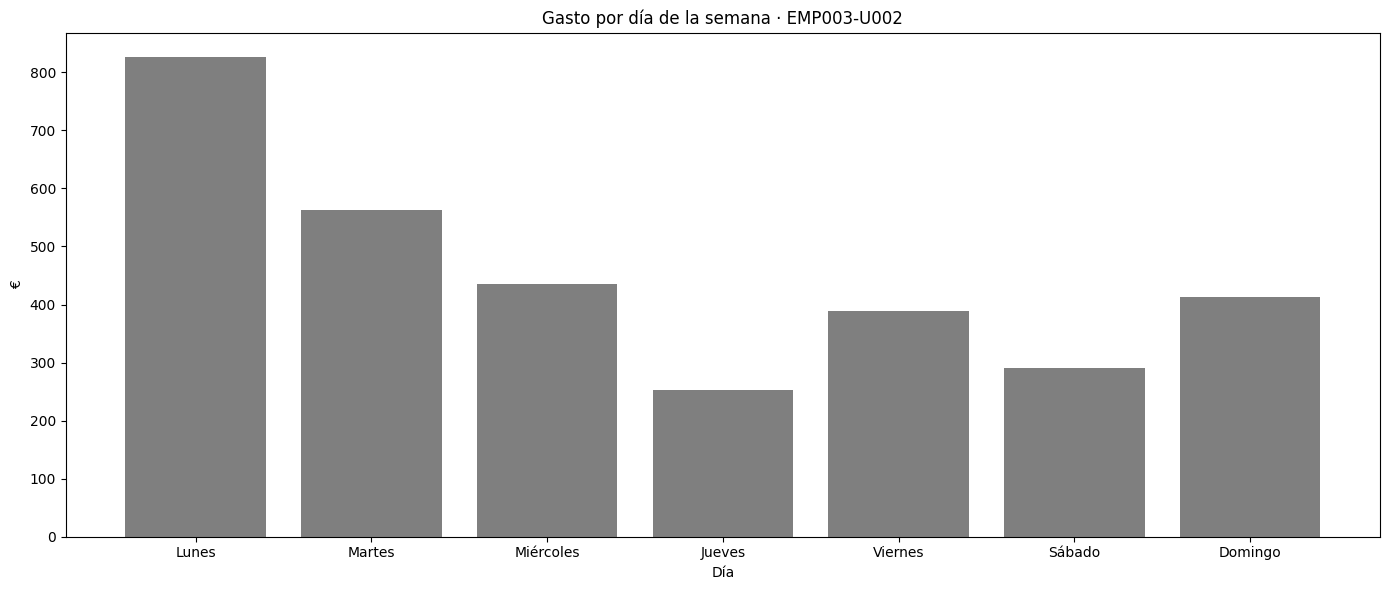

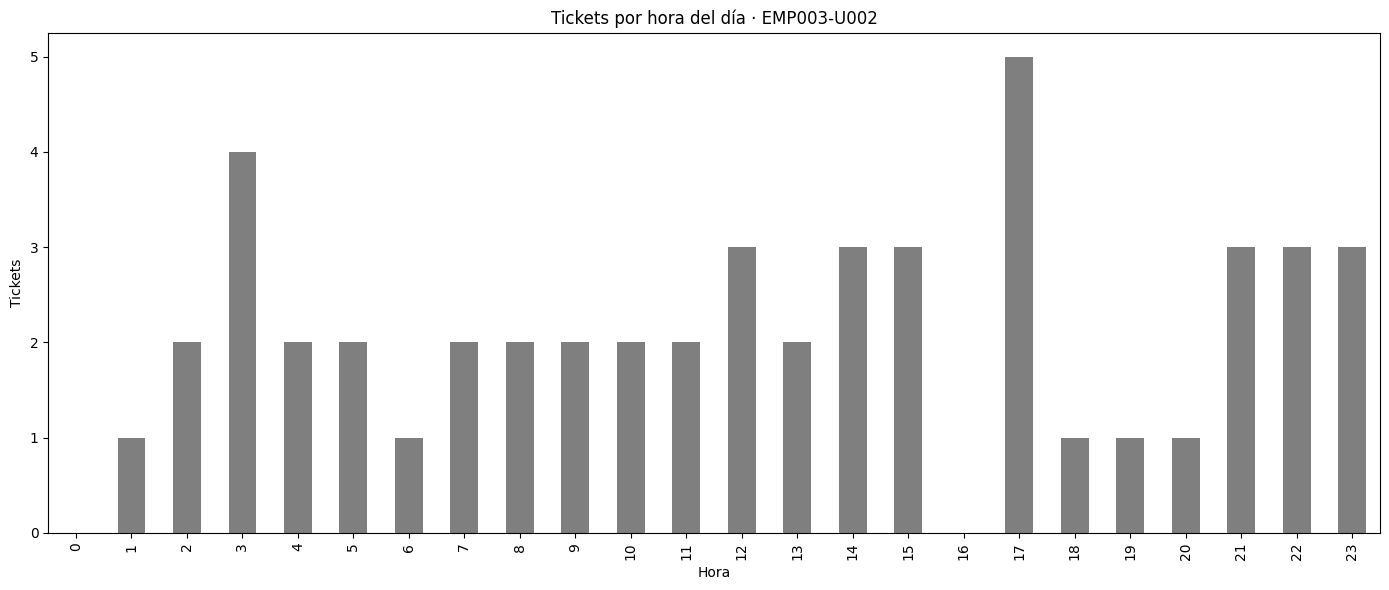

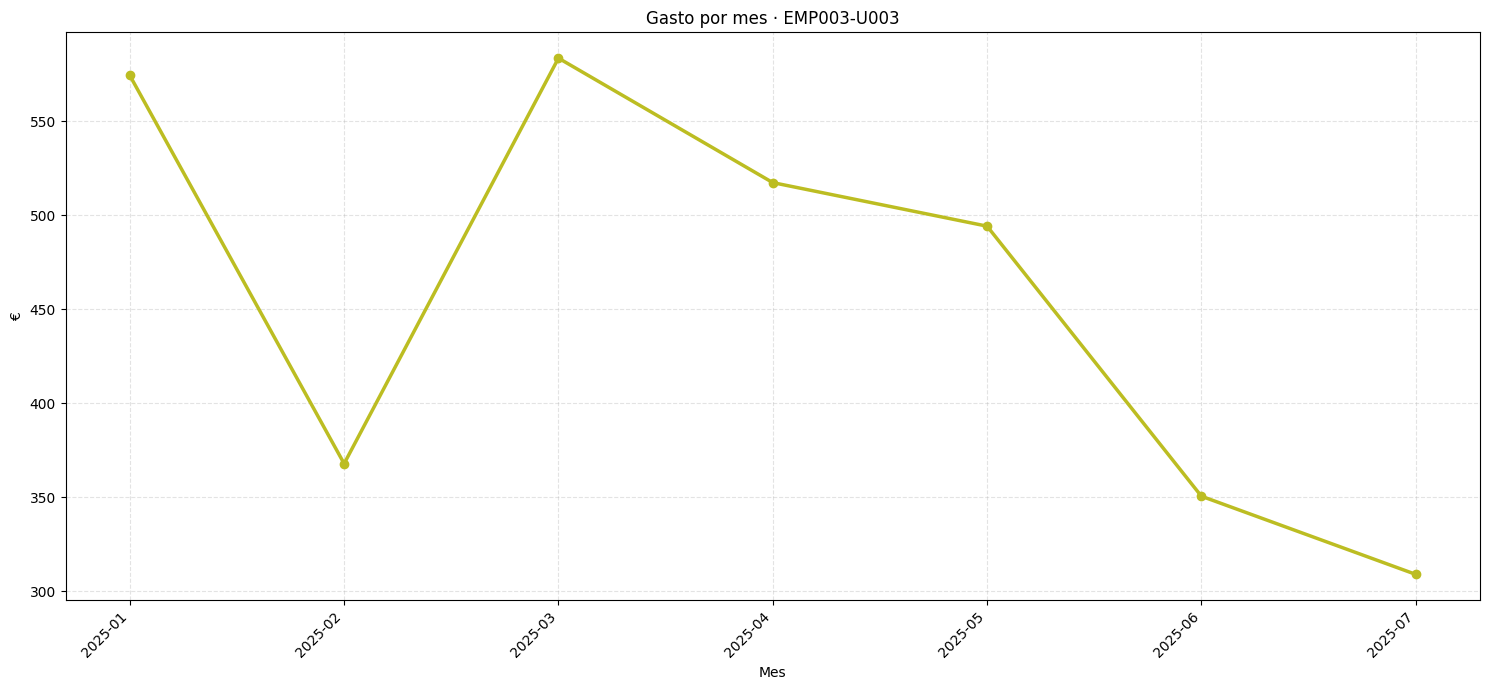

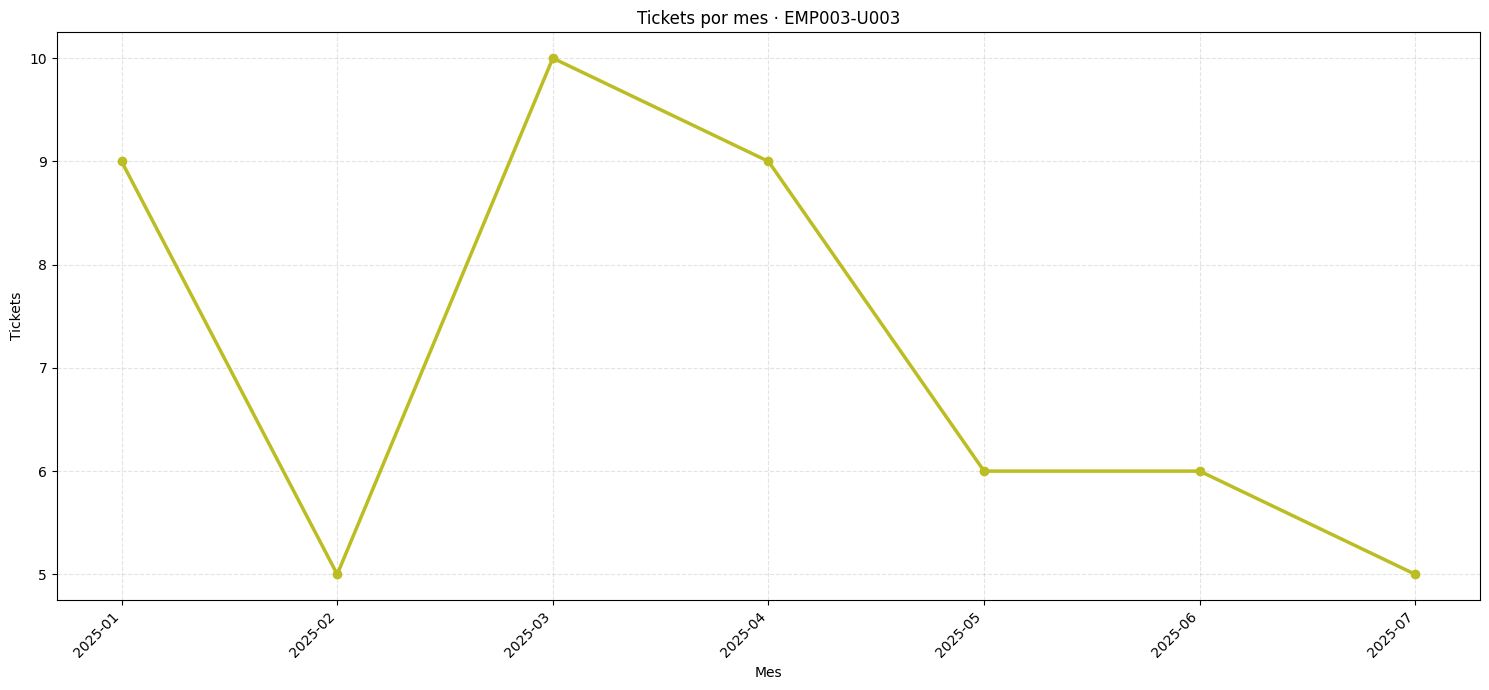

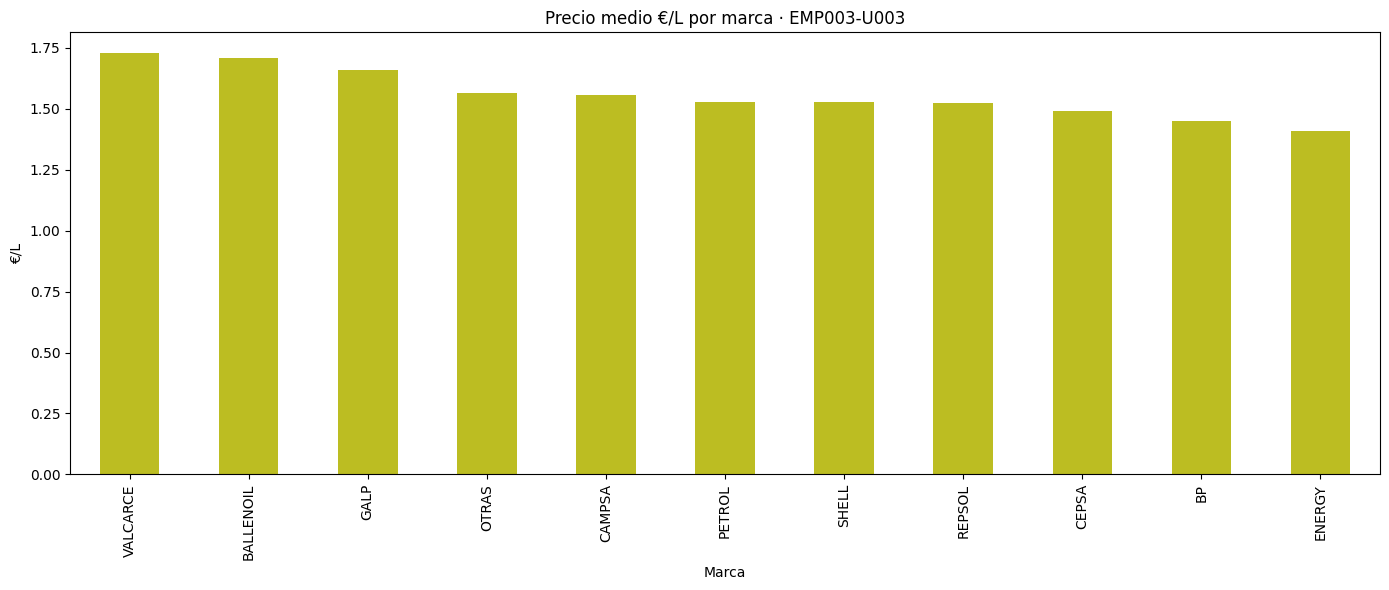

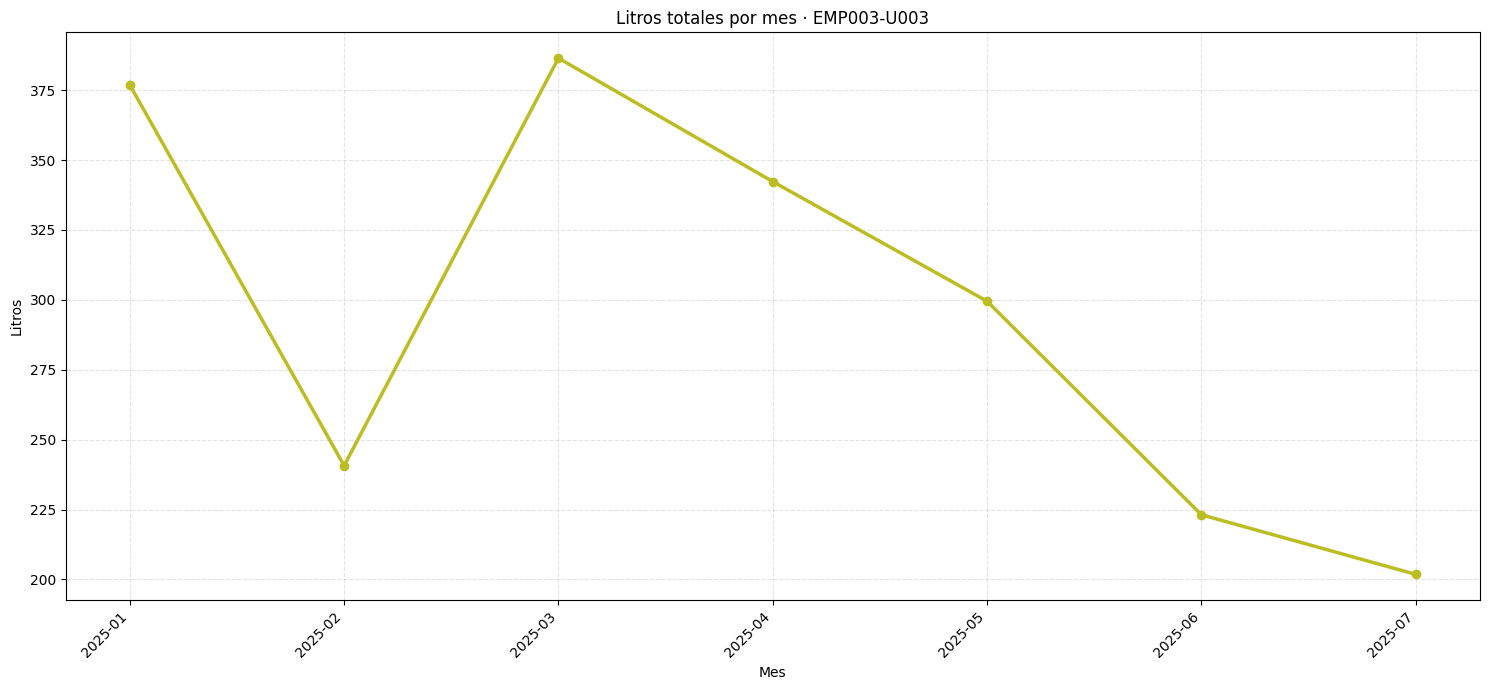

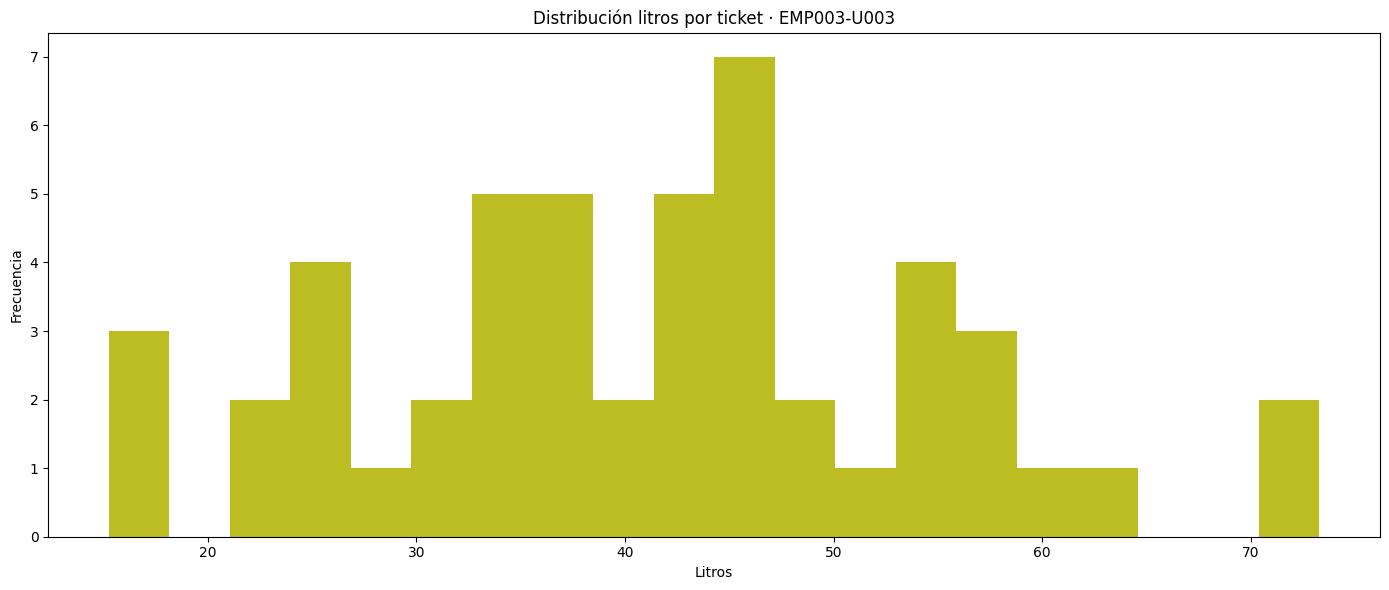

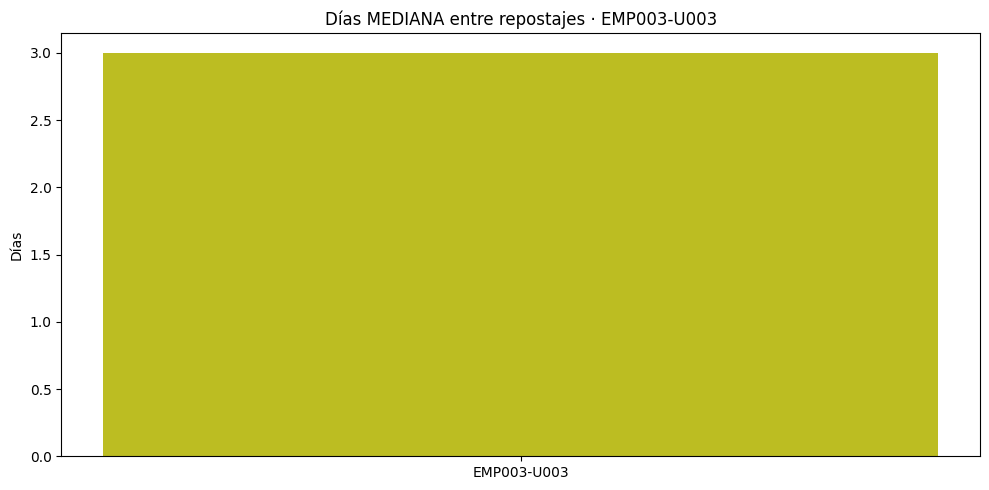

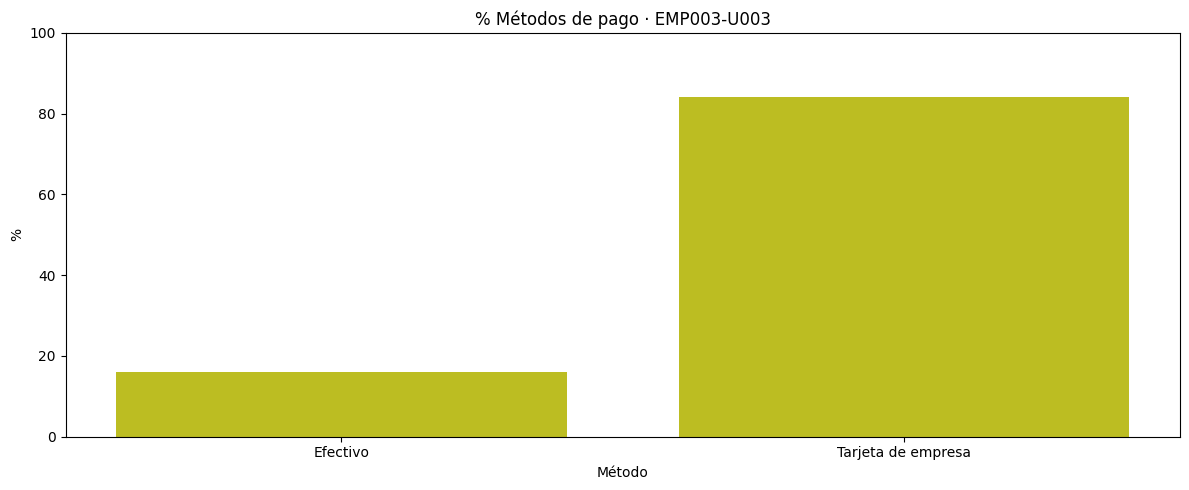

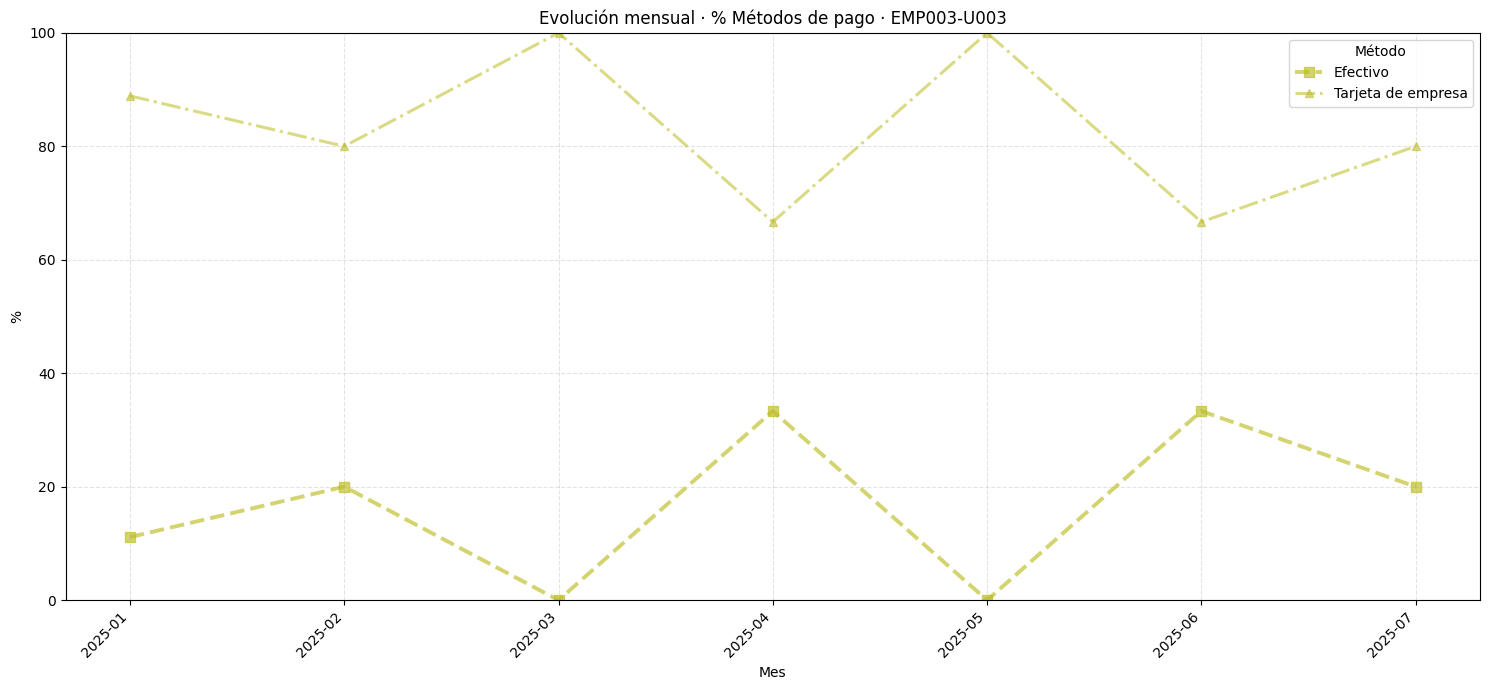

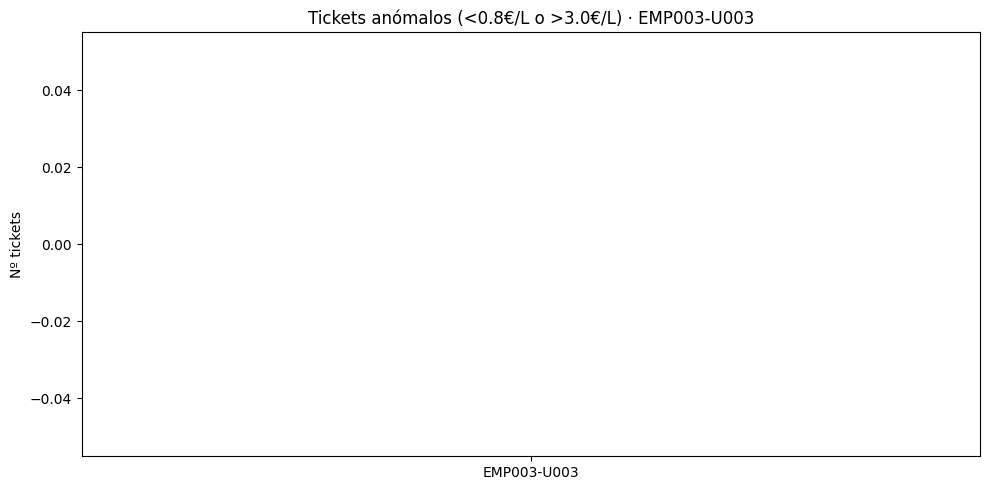

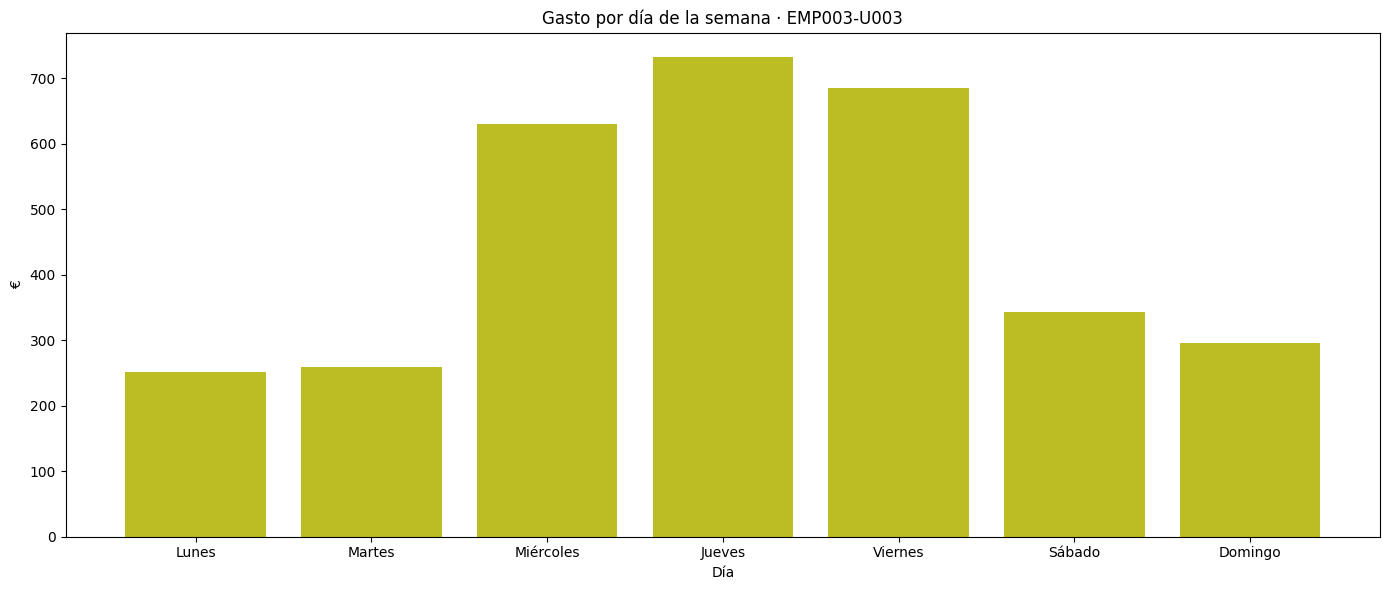

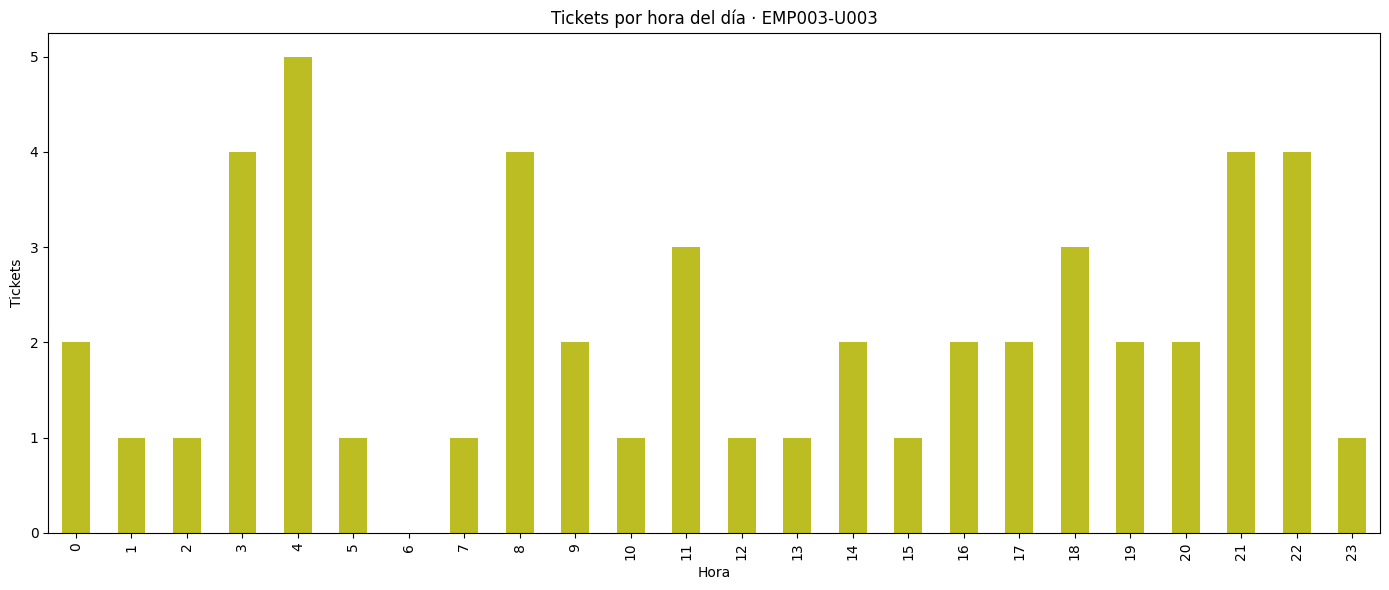

In [114]:
for USER in USERS:
    color = USER_COLOR[USER]

    tmp = gasto_usuario_mes[gasto_usuario_mes["idUsuario"]==USER].set_index("mes").reindex(MESES).fillna(0)
    plt.figure(figsize=(15,7)); plt.plot(MESES, tmp["total"], marker="o", color=color, linewidth=2.5)
    plt.title(f"Gasto por mes · {USER}"); plt.xlabel("Mes"); plt.ylabel("€")
    plt.xticks(rotation=45, ha="right"); plt.grid(True, linestyle="--", alpha=0.35); plt.tight_layout(); plt.show()

    tmp = tickets_usuario_mes[tickets_usuario_mes["idUsuario"]==USER].set_index("mes").reindex(MESES).fillna(0)
    plt.figure(figsize=(15,7)); plt.plot(MESES, tmp["tickets"], marker="o", color=color, linewidth=2.5)
    plt.title(f"Tickets por mes · {USER}"); plt.xlabel("Mes"); plt.ylabel("Tickets")
    plt.xticks(rotation=45, ha="right"); plt.grid(True, linestyle="--", alpha=0.35); plt.tight_layout(); plt.show()

    tmp = precio_usuario_marca[precio_usuario_marca["idUsuario"]==USER].set_index("estacion_marca")["eur_l"].sort_values(ascending=False)
    plt.figure(figsize=(14,6)); tmp.plot.bar(color=color)
    plt.title(f"Precio medio €/L por marca · {USER}"); plt.xlabel("Marca"); plt.ylabel("€/L")
    plt.tight_layout(); plt.show()

    tmp = litros_usuario_mes[litros_usuario_mes["idUsuario"]==USER].set_index("mes").reindex(MESES).fillna(0)
    plt.figure(figsize=(15,7)); plt.plot(MESES, tmp["litros"], marker="o", color=color, linewidth=2.5)
    plt.title(f"Litros totales por mes · {USER}"); plt.xlabel("Mes"); plt.ylabel("Litros")
    plt.xticks(rotation=45, ha="right"); plt.grid(True, linestyle="--", alpha=0.35); plt.tight_layout(); plt.show()

    lpt = litros_ticket_usuario[litros_ticket_usuario["idUsuario"]==USER]["litros"].dropna()
    plt.figure(figsize=(14,6)); plt.hist(lpt, bins=20, color=color)
    plt.title(f"Distribución litros por ticket · {USER}"); plt.xlabel("Litros"); plt.ylabel("Frecuencia")
    plt.tight_layout(); plt.show()

    val = dias_mediana.loc[dias_mediana["idUsuario"]==USER, "dias_mediana"]
    v = float(val.iloc[0]) if not val.empty else np.nan
    plt.figure(figsize=(10,5)); plt.bar([USER], [v], color=color)
    plt.title(f"Días MEDIANA entre repostajes · {USER}"); plt.ylabel("Días")
    plt.tight_layout(); plt.show()

    met = metodos_usuario[metodos_usuario["idUsuario"]==USER].copy()
    if not met.empty:
        met["pct"] = 100 * met["tickets"] / met["tickets"].sum()
        plt.figure(figsize=(12,5)); plt.bar(met["metodoPago"], met["pct"], color=color)
        plt.title(f"% Métodos de pago · {USER}"); plt.xlabel("Método"); plt.ylabel("%"); plt.ylim(0,100)
        plt.tight_layout(); plt.show()

    msub = metodos_usuario_mes[metodos_usuario_mes["idUsuario"]==USER]
    pivot = (msub.pivot(index="mes", columns="metodoPago", values="pct").reindex(MESES).fillna(0))

    plt.figure(figsize=(15,7))
    if "Tarjeta" in pivot.columns:
        plt.plot(MESES, pivot["Tarjeta"].values, label="Tarjeta",
                 color=color, linestyle="-", marker="o", linewidth=2.8, markersize=7, alpha=0.95)
    if "Efectivo" in pivot.columns:
        plt.plot(MESES, pivot["Efectivo"].values, label="Efectivo",
                 color=color, linestyle="--", marker="s", linewidth=2.8, markersize=7, alpha=0.65)
    otros = [m for m in pivot.columns if m not in ["Tarjeta","Efectivo"]]
    for m in sorted(otros):
        plt.plot(MESES, pivot[m].values, label=str(m),
                 color=color, linestyle="-.", marker="^", linewidth=2.2, markersize=6, alpha=0.55)
    plt.title(f"Evolución mensual · % Métodos de pago · {USER}")
    plt.xlabel("Mes"); plt.ylabel("%"); plt.ylim(0, 100)
    plt.xticks(rotation=45, ha="right"); plt.grid(True, linestyle="--", alpha=0.35); plt.legend(title="Método")
    plt.tight_layout(); plt.show()

    an = anomalias_usuario[anomalias_usuario["idUsuario"]==USER]["tickets_anomalos"]
    va = int(an.iloc[0]) if not an.empty else 0
    plt.figure(figsize=(10,5)); plt.bar([USER], [va], color=color)
    plt.title(f"Tickets anómalos (<0.8€/L o >3.0€/L) · {USER}"); plt.ylabel("Nº tickets")
    plt.tight_layout(); plt.show()

    gds = (gasto_dia_semana[gasto_dia_semana["idUsuario"]==USER]
           .set_index("dia_semana").reindex(orden_sem)["total"].fillna(0))
    plt.figure(figsize=(14,6)); plt.bar(gds.index.astype(str), gds.values, color=color)
    plt.title(f"Gasto por día de la semana · {USER}"); plt.xlabel("Día"); plt.ylabel("€")
    plt.tight_layout(); plt.show()

    th = (df[df["idUsuario"]==USER].groupby("hora")["idTicket"].nunique()
          .reindex(range(0,24)).fillna(0))
    plt.figure(figsize=(14,6)); th.plot.bar(color=color)
    plt.title(f"Tickets por hora del día · {USER}"); plt.xlabel("Hora"); plt.ylabel("Tickets")
    plt.tight_layout(); plt.show()
